# Regime-Adaptive Entropic Black-Litterman Trading Strategy
## Phase 1 — Data Foundation

---

### Objective
1. Download 7 years of OHLCV data for 10 stocks + SPY
2. Clean the raw data
3. Extract features — Kalman-smoothed prices, log returns, realized vol, volume Z-scores, cross-stock correlation

**Guiding principle: no future data ever contaminates the past.**

---
## Cell 1 — Imports & Configuration

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import yfinance as yf
import warnings
from scipy import stats
from scipy.linalg import block_diag, inv
from scipy.optimize import minimize
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

STOCKS     = ['AAPL','MSFT','NVDA','JPM','GS','CAT','XOM','PG','JNJ','PFE']
MARKET_REF = 'SPY'
ALL_TICKERS= STOCKS + [MARKET_REF]
SECTOR_MAP = {
    'AAPL':'Technology','MSFT':'Technology','NVDA':'Technology',
    'JPM':'Financials','GS':'Financials',
    'CAT':'Industrials','XOM':'Energy',
    'PG':'Consumer','JNJ':'Healthcare','PFE':'Healthcare'
}
END_DATE   = '2025-01-01'
START_DATE = '2018-01-01'
TRAIN_END  = '2022-12-31'
TEST_START = '2023-01-01'
ROLLING_VOL_WINDOW   = 21
ROLLING_CORR_WINDOW  = 63
ROLLING_VOL_Z_WINDOW = 63
KALMAN_NOISE_RATIO   = 1e-3

plt.rcParams.update({
    'figure.facecolor':'#0d0d0d','axes.facecolor':'#1a1a1a',
    'axes.edgecolor':'#444444','axes.labelcolor':'#cccccc',
    'axes.titlecolor':'#ffffff','xtick.color':'#888888',
    'ytick.color':'#888888','text.color':'#cccccc',
    'grid.color':'#2a2a2a','grid.linestyle':'--',
    'grid.linewidth':0.5,'font.family':'monospace','figure.dpi':120
})
PALETTE = ['#00d4ff','#ff6b35','#7fff00','#ff00ff',
           '#ffd700','#ff4444','#00ffcc','#ff8c00','#9370db','#20b2aa','#ffffff']
# Consistent regime colors throughout notebook
# Bear = orange (medium risk), Choppy = red (most defensive)
REGIME_COLORS = {'Bull':'#7fff00','Bear':'#ff8c00','Choppy':'#ff4444'}

print(f"Universe : {STOCKS}")
print(f"Range    : {START_DATE} -> {END_DATE}")
print(f"Train    : {START_DATE} -> {TRAIN_END}")
print(f"Test     : {TEST_START} -> {END_DATE}")


Universe : ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GS', 'CAT', 'XOM', 'PG', 'JNJ', 'PFE']
Range    : 2018-01-01 -> 2025-01-01
Train    : 2018-01-01 -> 2022-12-31
Test     : 2023-01-01 -> 2025-01-01


---
## Cell 2 — Data Download

We download **Adjusted Close** and **Volume** for all tickers. Adjusted Close corrects for stock splits and dividend payments, giving us the true economic return an investor would have earned. Raw Close would overstate losses at dividend dates and understate them at split dates.

SPY is downloaded alongside the stock universe. It is not traded — it serves as the market-wide reference signal for the HMM regime detector in Phase 2.

In [82]:
print("Downloading data...")
raw = yf.download(ALL_TICKERS, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)
price_raw  = raw['Close'].copy()[ALL_TICKERS]
volume_raw = raw['Volume'].copy()[ALL_TICKERS]
print(f"Downloaded: {price_raw.shape}  {price_raw.index[0].date()} -> {price_raw.index[-1].date()}")
print(price_raw.head(3).round(2))


Downloaded: (1761, 11)  2018-01-02 -> 2024-12-31
Ticker       AAPL   MSFT  NVDA    JPM      GS     CAT    XOM     PG     JNJ  \
Date                                                                          
2018-01-02  40.27  78.70  4.93  85.90  213.14  131.29  58.19  72.28  110.13   
2018-01-03  40.26  79.07  5.25  85.99  211.16  131.49  59.33  72.19  111.18   
2018-01-04  40.45  79.76  5.28  87.22  214.11  133.30  59.41  72.70  111.17   

Ticker        PFE     SPY  
Date                       
2018-01-02  23.44  236.56  
2018-01-03  23.62  238.06  
2018-01-04  23.67  239.06  


---
## Cell 3 — Data Cleaning

Three cleaning operations in strict order:

1. **Forward-fill** — carry last known price forward for missing days (e.g., trading halts, thin liquidity days). We never use future data to fill backward first.
2. **Backward-fill** — handles any NaNs at the very start of a series (before a stock's first observed price in our window).
3. **Anomaly detection** — flag extreme single-day moves (>50%) and zero-volume days. These are logged, not silently dropped, so we can inspect them.

In [83]:
missing = price_raw.isnull().sum()
print("Missing before:", missing[missing>0].to_dict() if missing.sum()>0 else "None")

price_clean  = price_raw.ffill().bfill()
volume_clean = volume_raw.ffill().bfill()

daily_ret_raw = price_clean.pct_change()
anomalies = {}
for t in ALL_TICKERS:
    ex = daily_ret_raw[t][abs(daily_ret_raw[t]) > 0.50]
    if len(ex): anomalies[t] = ex

print(f"Extreme moves (>50%): {sum(len(v) for v in anomalies.values())} instances")
for t, days in anomalies.items():
    for date, ret in days.items():
        print(f"  {t} {date.date()} {ret:+.1%}")

valid_idx    = price_clean.dropna(how='any').index
price_clean  = price_clean.loc[valid_idx]
volume_clean = volume_clean.loc[valid_idx]
print(f"Final: {len(price_clean)} trading days | NaNs: {price_clean.isnull().sum().sum()}")


Missing before: None
Extreme moves (>50%): 0 instances
Final: 1761 trading days | NaNs: 0


---
## Cell 4 — Kalman Filter Implementation

The Kalman Filter models the true underlying price as a **hidden state** evolving via a random walk with drift. At each timestep it performs two operations:

- **Predict**: project the previous state estimate forward using the transition model
- **Update**: correct the prediction using the new observation, weighted by the Kalman gain

The key parameter is the **noise ratio** `q/r` — the ratio of process noise (true price volatility) to observation noise (measurement error). We estimate this empirically from the data rather than setting it arbitrarily.

**Critical design choice**: the noise ratio is estimated on the training window only and held fixed for the test period. Estimating it on the full dataset would constitute a subtle look-ahead bias.

In [84]:
def estimate_kalman_noise_ratio(price_series, train_end):
    tp = price_series[:train_end]
    lp = np.log(tp)
    q  = np.var(np.diff(lp.values))
    ma5= tp.rolling(5, min_periods=1).mean()
    r  = np.var((tp - ma5).values)
    return float(q/r) if r > 1e-10 else KALMAN_NOISE_RATIO

def kalman_filter(price_series, noise_ratio):
    obs = np.log(price_series.values)
    n   = len(obs)
    r, q = 1.0, noise_ratio
    x_hat, P = np.zeros(n), np.zeros(n)
    x_hat[0], P[0] = obs[0], 1.0
    for t in range(1, n):
        x_pred = x_hat[t-1]
        P_pred = P[t-1] + q
        K        = P_pred / (P_pred + r)
        x_hat[t] = x_pred + K*(obs[t] - x_pred)
        P[t]     = (1-K)*P_pred
    return pd.Series(np.exp(x_hat), index=price_series.index, name=price_series.name)

print("Estimating Kalman noise ratios (training window only)...")
noise_ratios = {}
for ticker in ALL_TICKERS:
    noise_ratios[ticker] = estimate_kalman_noise_ratio(price_clean[ticker], TRAIN_END)

print(f"{'Ticker':<8} {'q/r':<15} {'Interpretation'}")
print("-"*45)
for t, nr in noise_ratios.items():
    interp = 'High noise' if nr>0.01 else 'Moderate' if nr>0.001 else 'Low noise'
    print(f"{t:<8} {nr:<15.6f} {interp}")

price_kalman = pd.DataFrame(index=price_clean.index, columns=ALL_TICKERS, dtype=float)
for ticker in ALL_TICKERS:
    price_kalman[ticker] = kalman_filter(price_clean[ticker], noise_ratios[ticker])
print(f"\nKalman output: {price_kalman.shape}")


Estimating Kalman noise ratios (training window only)...
Ticker   q/r             Interpretation
---------------------------------------------
AAPL     0.000088        Low noise
MSFT     0.000027        Low noise
NVDA     0.004383        Moderate
JPM      0.000092        Low noise
GS       0.000017        Low noise
CAT      0.000040        Low noise
XOM      0.000316        Low noise
PG       0.000089        Low noise
JNJ      0.000063        Low noise
PFE      0.000861        Low noise
SPY      0.000010        Low noise

Kalman output: (1761, 11)


---
## Cell 5 — Plot: Kalman Filter Effect

Visualizing the filter on three representative stocks — a high-volatility tech stock (NVDA), a stable defensive stock (PG), and the market reference (SPY). The plot shows what the filter preserves versus what it removes.

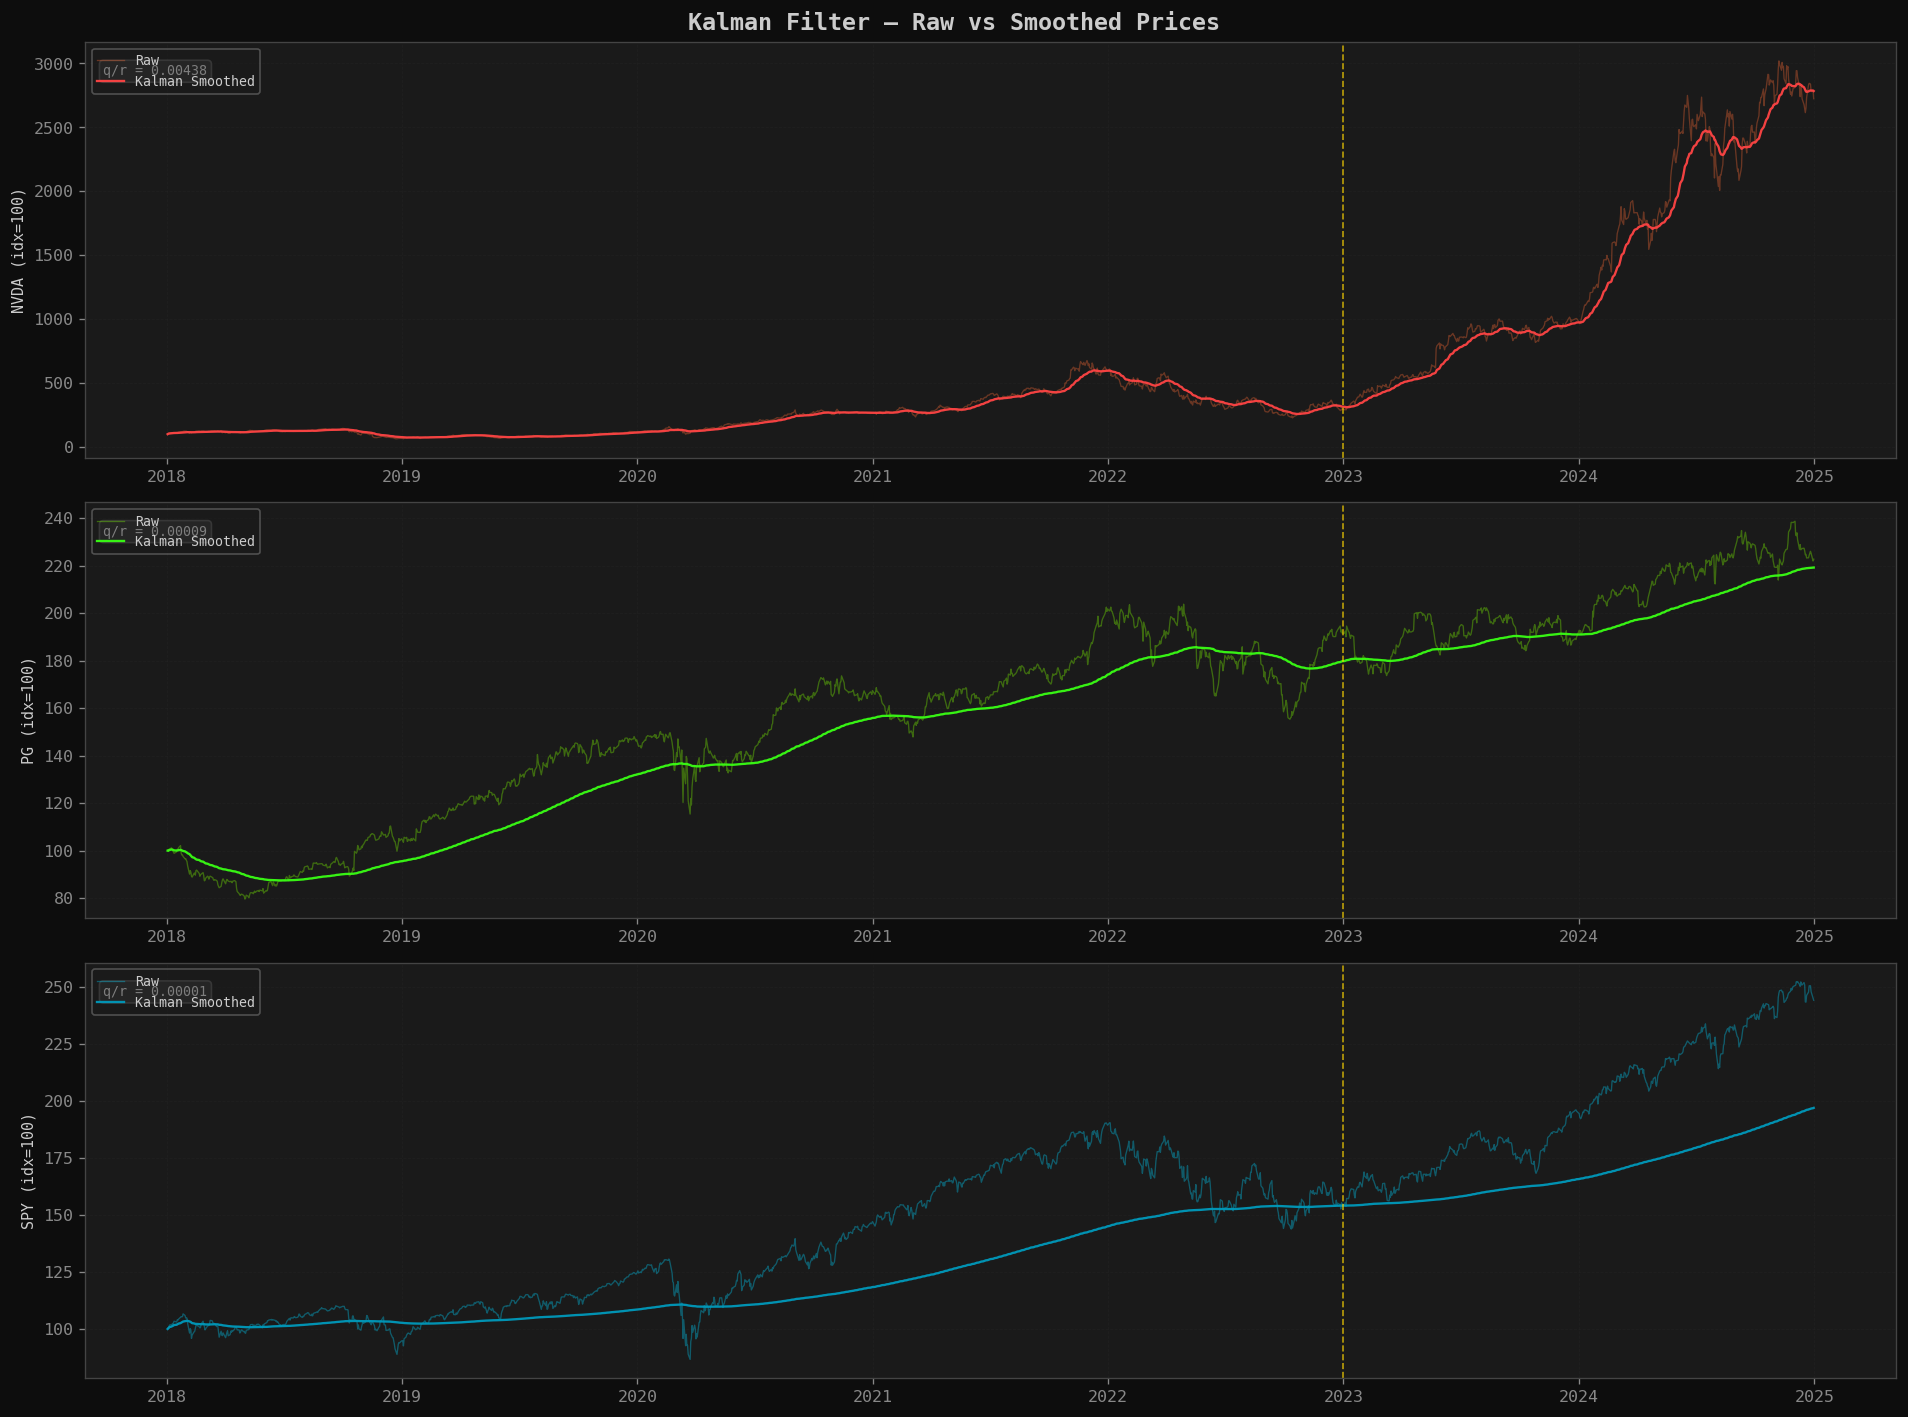

Saved: phase1_kalman_filter.png


In [85]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Kalman Filter — Raw vs Smoothed Prices', fontsize=14, fontweight='bold')
for i,(ticker,cr,cs) in enumerate(zip(['NVDA','PG','SPY'],
                                       ['#ff6b35','#7fff00','#00d4ff'],
                                       ['#ff4444','#39ff14','#0099bb'])):
    ax = axes[i]
    rn = price_clean[ticker]/price_clean[ticker].iloc[0]*100
    sn = price_kalman[ticker]/price_kalman[ticker].iloc[0]*100
    ax.plot(rn.index, rn.values, color=cr, alpha=0.35, lw=0.8, label='Raw')
    ax.plot(sn.index, sn.values, color=cs, alpha=0.95, lw=1.4, label='Kalman Smoothed')
    ax.axvline(pd.Timestamp(TEST_START), color='#ffd700', lw=1.0, ls='--', alpha=0.7)
    ax.text(0.01, 0.92, f"q/r = {noise_ratios[ticker]:.5f}", transform=ax.transAxes,
            fontsize=8, color='#aaaaaa',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2a2a', edgecolor='#444444'))
    ax.set_ylabel(f'{ticker} (idx=100)', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.3, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('phase1_kalman_filter.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: phase1_kalman_filter.png")


---
## Cell 6 — Feature Extraction

We extract four feature sets from the Kalman-smoothed prices:

| Feature | Window | Purpose |
|---|---|---|
| Log Returns | Daily | Primary signal input for all models |
| Realized Volatility | 21-day | HMM feature; regime characterization |
| Volume Z-Score | 63-day | Confirms regime transitions via unusual activity |
| Avg Pairwise Correlation | 63-day | Key Bear regime detector — correlations spike in crashes |

All features are computed from **Kalman-smoothed** prices, not raw prices. This is intentional — cleaner inputs produce more stable regime labels.

In [86]:
# 1. Log returns from Kalman-smoothed prices
log_returns = np.log(price_kalman / price_kalman.shift(1)).dropna()
print(f"Log returns: {log_returns.shape}")

# 2. Realized volatility (21-day, annualized)
realized_vol = (log_returns[STOCKS].rolling(ROLLING_VOL_WINDOW, min_periods=10).std()
                * np.sqrt(252))

# 3. Volume Z-score (63-day)
vm = volume_clean[ALL_TICKERS].rolling(ROLLING_VOL_Z_WINDOW, min_periods=20).mean()
vs = volume_clean[ALL_TICKERS].rolling(ROLLING_VOL_Z_WINDOW, min_periods=20).std()
vol_z_score = ((volume_clean[ALL_TICKERS]-vm) / vs.replace(0,np.nan)).reindex(log_returns.index)

# 4. Average pairwise correlation (63-day) — strongest Bear regime signal
def rolling_avg_pairwise_corr(returns_df, window, min_periods=30):
    n_stocks = returns_df.shape[1]
    avg_corr = pd.Series(index=returns_df.index, dtype=float)
    upper_idx= np.triu_indices(n_stocks, k=1)
    for i in range(len(returns_df)):
        if i < window:
            avg_corr.iloc[i] = np.nan
            continue
        wd = returns_df.iloc[max(0,i-window):i]
        if len(wd) < min_periods:
            avg_corr.iloc[i] = np.nan
            continue
        avg_corr.iloc[i] = np.nanmean(wd.corr().values[upper_idx])
    return avg_corr

print("Computing rolling avg pairwise correlation (~30s)...")
avg_pairwise_corr = rolling_avg_pairwise_corr(log_returns[STOCKS], ROLLING_CORR_WINDOW)
print(f"Avg corr: mean={avg_pairwise_corr.mean():.3f} min={avg_pairwise_corr.min():.3f} max={avg_pairwise_corr.max():.3f}")

train_mask = log_returns.index <= TRAIN_END
test_mask  = log_returns.index > TRAIN_END
print(f"Train: {train_mask.sum()} days | Test: {test_mask.sum()} days")


Log returns: (1760, 11)
Computing rolling avg pairwise correlation (~30s)...
Avg corr: mean=0.272 min=-0.042 max=0.885
Train: 1258 days | Test: 502 days


---
## Cell 7 — Plot: Feature Dashboard

Four-panel plot showing the key features extracted. This is a diagnostic plot — we want to visually confirm that the features capture known market events (COVID crash March 2020, 2022 rate hike selloff) correctly before feeding them to the HMM.

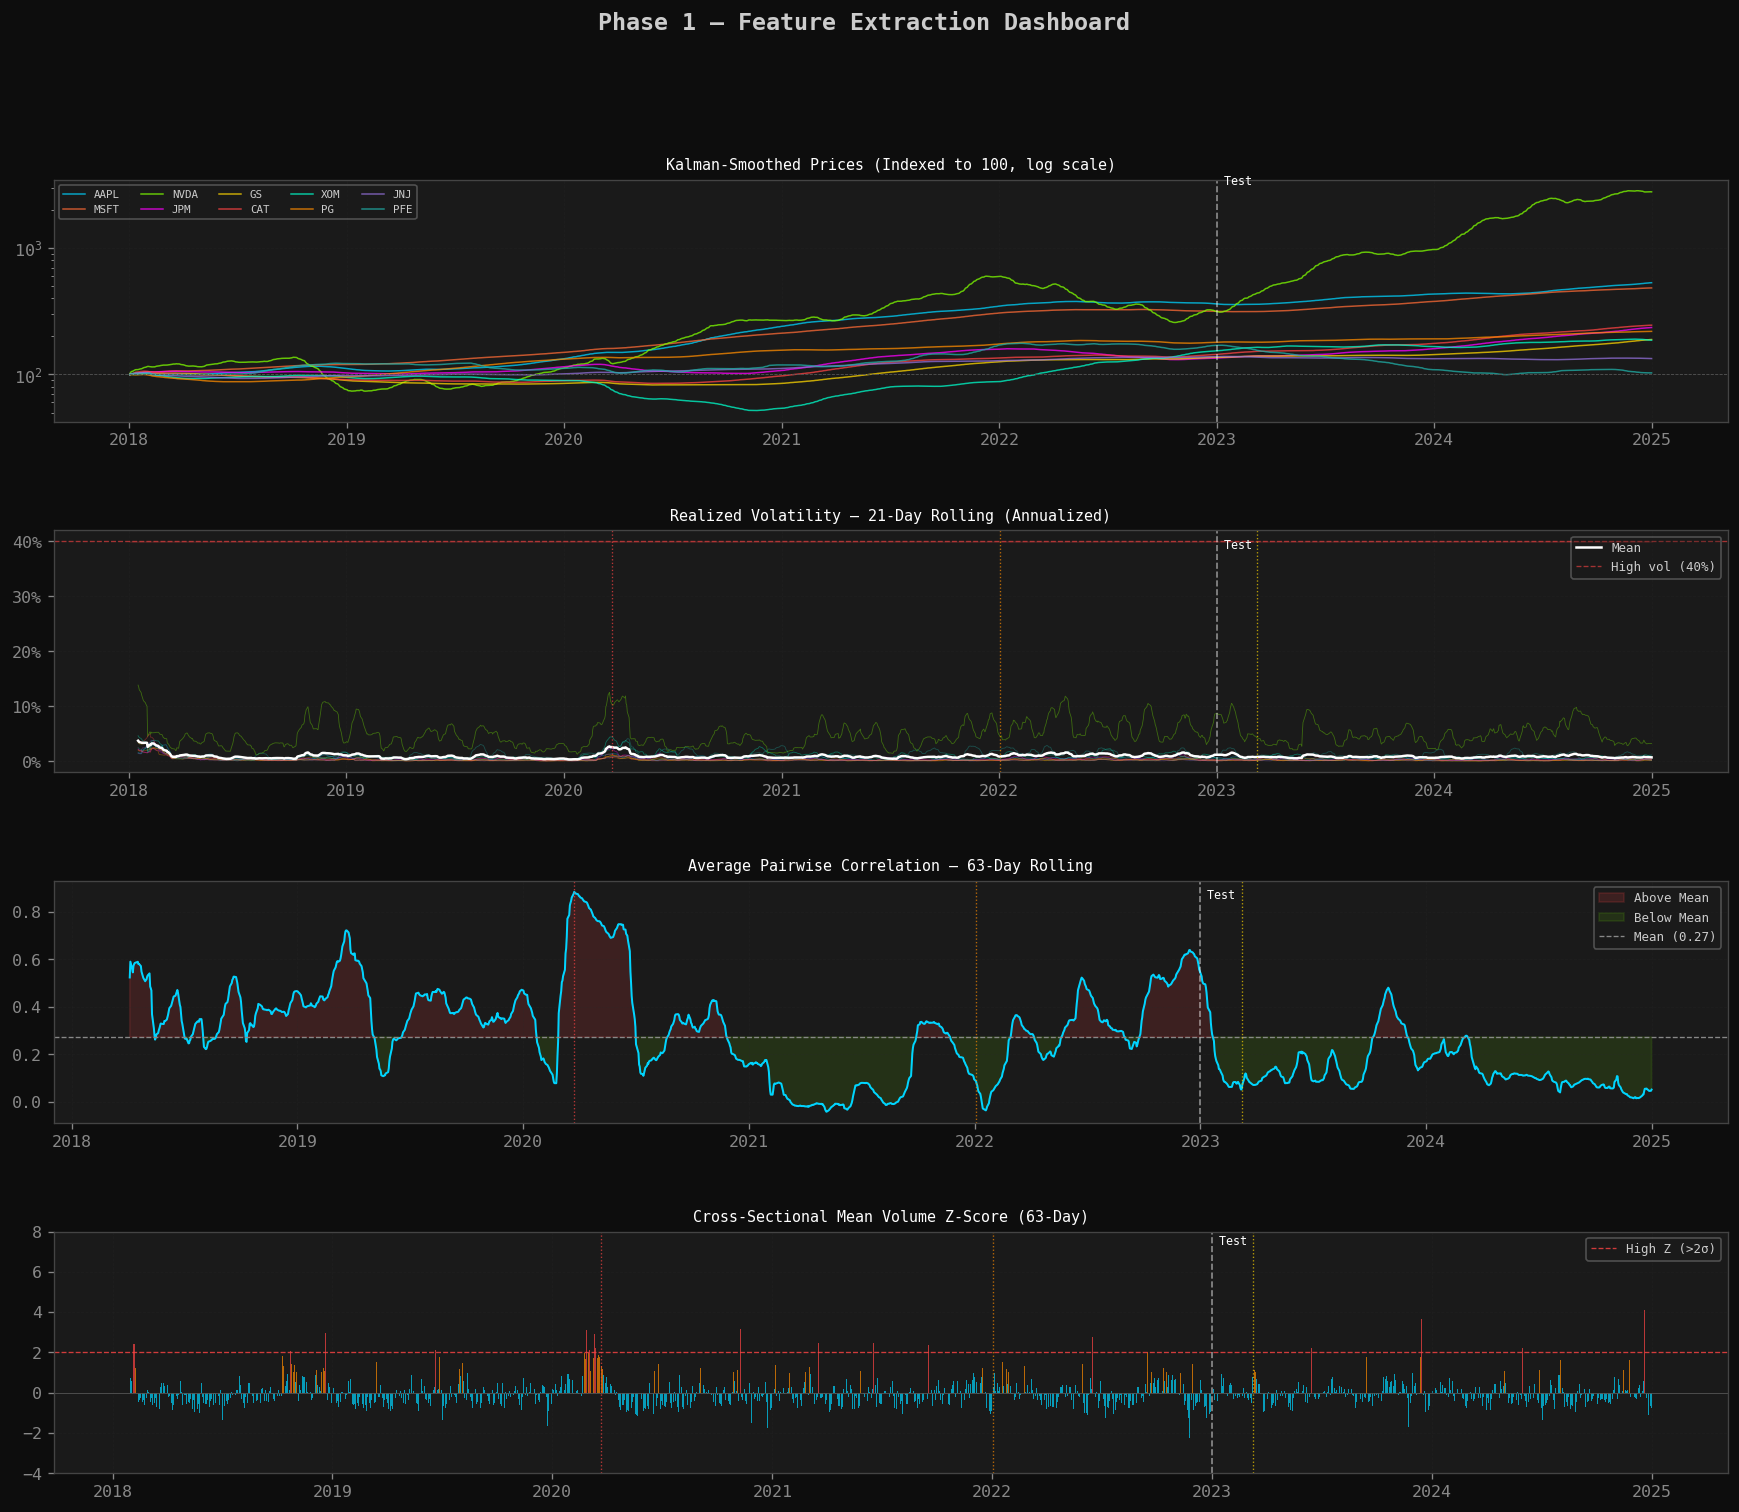

Saved: phase1_feature_dashboard.png


In [87]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(4, 1, figure=fig, hspace=0.45)
fig.suptitle('Phase 1 — Feature Extraction Dashboard', fontsize=14, fontweight='bold')

events = [('2020-03-23','COVID Bottom','#ff4444'),
          ('2022-01-03','2022 Rate Hike','#ff8c00'),
          ('2023-03-10','SVB Crisis','#ffd700')]

def add_events(ax):
    for ds,_,c in events:
        ax.axvline(pd.Timestamp(ds), color=c, lw=0.8, ls=':', alpha=0.7)
def add_tt(ax):
    ax.axvline(pd.Timestamp(TEST_START), color='#ffffff', lw=1.0, ls='--', alpha=0.5)
    ax.text(pd.Timestamp(TEST_START), ax.get_ylim()[1]*0.92, ' Test', color='#ffffff', fontsize=7)

ax1 = fig.add_subplot(gs[0])
for i,t in enumerate(STOCKS):
    n = price_kalman[t]/price_kalman[t].iloc[0]*100
    ax1.plot(n.index, n.values, color=PALETTE[i], lw=0.9, alpha=0.75, label=t)
ax1.axhline(100, color='#555555', lw=0.5, ls='--')
ax1.set_yscale('log')
ax1.set_title('Kalman-Smoothed Prices (Indexed to 100, log scale)', fontsize=9)
ax1.legend(fontsize=6.5, ncol=5, framealpha=0.3, loc='upper left')
ax1.grid(True, alpha=0.25)
add_tt(ax1)

ax2 = fig.add_subplot(gs[1])
mean_vol = realized_vol.mean(axis=1)
for i,t in enumerate(STOCKS):
    ax2.plot(realized_vol.index, realized_vol[t].values, color=PALETTE[i], lw=0.5, alpha=0.35)
ax2.plot(mean_vol.index, mean_vol.values, color='#ffffff', lw=1.5, label='Mean')
ax2.axhline(0.40, color='#ff4444', lw=0.8, ls='--', alpha=0.6, label='High vol (40%)')
ax2.fill_between(mean_vol.index, 0.40,
                  np.where(mean_vol>0.40, mean_vol, 0.40), color='#ff4444', alpha=0.15)
ax2.set_title('Realized Volatility — 21-Day Rolling (Annualized)', fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax2.legend(fontsize=7.5, framealpha=0.3, loc='upper right')
ax2.grid(True, alpha=0.25)
add_events(ax2); add_tt(ax2)

ax3 = fig.add_subplot(gs[2])
ax3.plot(avg_pairwise_corr.index, avg_pairwise_corr.values, color='#00d4ff', lw=1.2)
mn = avg_pairwise_corr.mean()
ax3.fill_between(avg_pairwise_corr.index, avg_pairwise_corr.values, mn,
                  where=avg_pairwise_corr.values>mn, color='#ff4444', alpha=0.15, label='Above Mean')
ax3.fill_between(avg_pairwise_corr.index, avg_pairwise_corr.values, mn,
                  where=avg_pairwise_corr.values<=mn, color='#7fff00', alpha=0.10, label='Below Mean')
ax3.axhline(mn, color='#888888', lw=0.8, ls='--', label=f'Mean ({mn:.2f})')
ax3.set_title('Average Pairwise Correlation — 63-Day Rolling', fontsize=9)
ax3.legend(fontsize=7.5, framealpha=0.3, loc='upper right')
ax3.grid(True, alpha=0.25)
add_events(ax3); add_tt(ax3)

ax4 = fig.add_subplot(gs[3])
mvz = vol_z_score[STOCKS].mean(axis=1)
cvz = np.where(mvz.values>2,'#ff4444',np.where(mvz.values>1,'#ff8c00','#00d4ff'))
ax4.bar(mvz.index, mvz.values, color=cvz, width=1.0, alpha=0.7)
ax4.axhline(2.0, color='#ff4444', lw=0.8, ls='--', alpha=0.8, label='High Z (>2σ)')
ax4.axhline(0.0, color='#555555', lw=0.5)
ax4.set_ylim(-4, 8)
ax4.set_title('Cross-Sectional Mean Volume Z-Score (63-Day)', fontsize=9)
ax4.legend(fontsize=7.5, framealpha=0.3, loc='upper right')
ax4.grid(True, alpha=0.25)
add_events(ax4); add_tt(ax4)

for ax in [ax1,ax2,ax3,ax4]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.savefig('phase1_feature_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: phase1_feature_dashboard.png")


---
## Cell 8 — Plot: Correlation Structure

Comparing the correlation matrix across two periods — the training window (stable) and a known stress period (COVID crash, Feb–Apr 2020). This validates that our average pairwise correlation feature is capturing real structural changes, not noise.

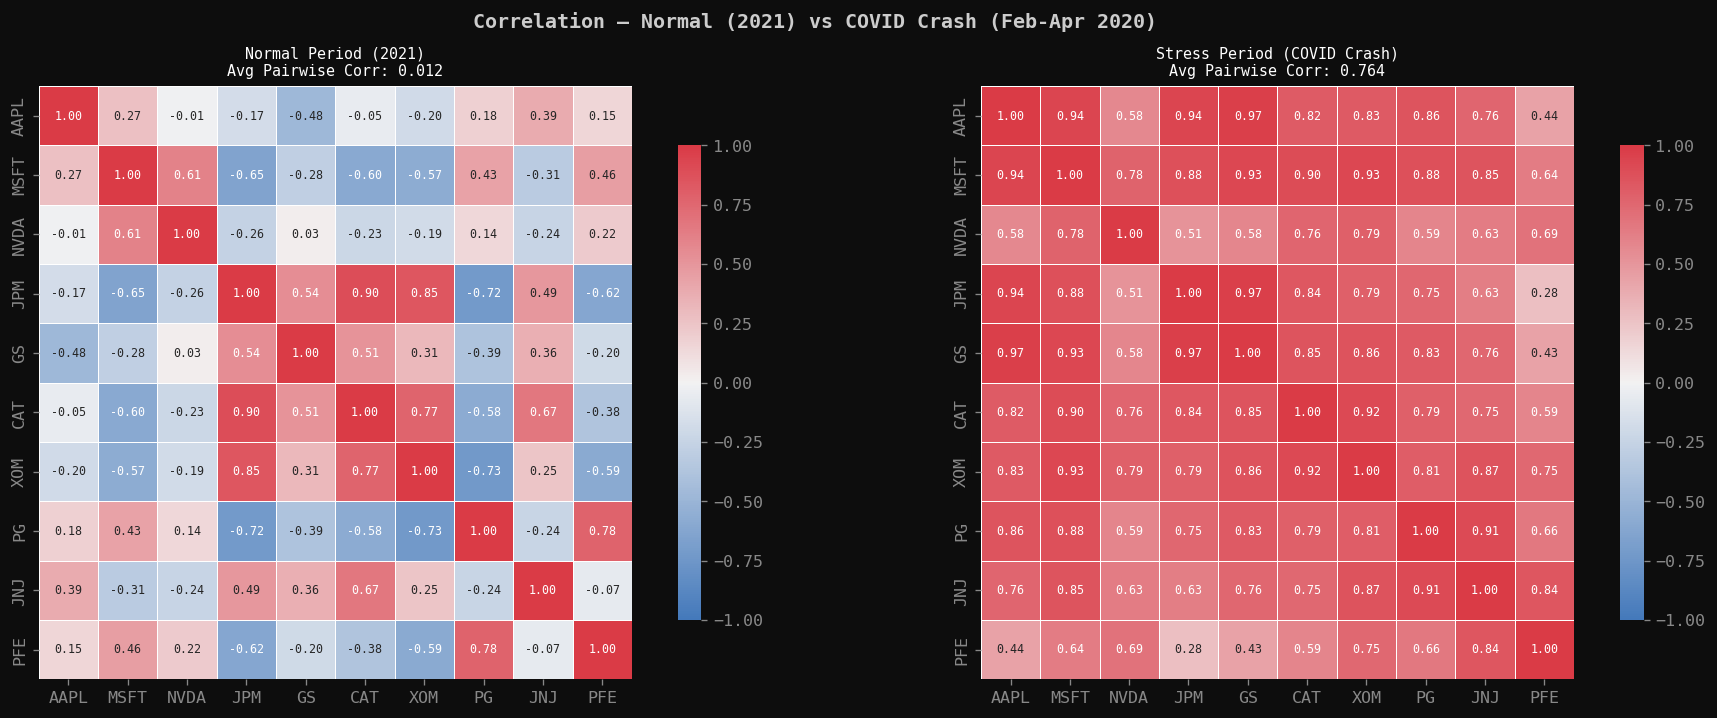

Saved: phase1_correlation_matrices.png


In [88]:
normal = log_returns[STOCKS]['2021-01-01':'2021-12-31']
stress = log_returns[STOCKS]['2020-02-01':'2020-04-30']
cn, cs = normal.corr(), stress.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation — Normal (2021) vs COVID Crash (Feb-Apr 2020)', fontsize=12, fontweight='bold')
cmap = sns.diverging_palette(250, 10, as_cmap=True)
for ax, cm, title in zip(axes, [cn, cs],
                          ['Normal Period (2021)','Stress Period (COVID Crash)']):
    sns.heatmap(cm, ax=ax, cmap=cmap, vmin=-1, vmax=1, annot=True, fmt='.2f',
                annot_kws={'size':7}, square=True, linewidths=0.3, cbar_kws={'shrink':0.8})
    mc = cm.values[np.triu_indices_from(cm.values, k=1)].mean()
    ax.set_title(f'{title}\nAvg Pairwise Corr: {mc:.3f}', fontsize=9)
plt.tight_layout()
plt.savefig('phase1_correlation_matrices.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: phase1_correlation_matrices.png")


---
## Cell 9 — Descriptive Statistics & Sanity Check

A final audit of the cleaned dataset before handing it to Phase 2. We check return distributions for normality (spoiler: they won't be — fat tails are expected and motivate the use of CVaR over variance), and verify all features are properly aligned.

In [89]:
print("="*70); print("PHASE 1 — FINAL DATA AUDIT"); print("="*70)
ret_stats = pd.DataFrame(index=STOCKS)
for t in STOCKS:
    r = log_returns[t].dropna()
    ret_stats.loc[t,'Ann.Return'] = r.mean()*252
    ret_stats.loc[t,'Ann.Vol']    = r.std()*np.sqrt(252)
    ret_stats.loc[t,'Sharpe']     = (r.mean()*252)/(r.std()*np.sqrt(252))
    ret_stats.loc[t,'Skewness']   = stats.skew(r)
    ret_stats.loc[t,'Kurtosis']   = stats.kurtosis(r)
    _, pv = stats.normaltest(r)
    ret_stats.loc[t,'Normal_pval']= pv
print(ret_stats.round(4).to_string())
n_nn = (ret_stats['Normal_pval'] < 0.05).sum()
print(f"\n{n_nn}/{len(STOCKS)} stocks reject normality — motivates CVaR over variance")
print(f"Train days: {train_mask.sum()} | Test days: {test_mask.sum()}")
print("="*70); print("PHASE 1 COMPLETE"); print("="*70)


PHASE 1 — FINAL DATA AUDIT
      Ann.Return  Ann.Vol   Sharpe  Skewness  Kurtosis  Normal_pval
AAPL      0.2393   0.0179  13.3755   -0.1881    0.9983       0.0000
MSFT      0.2257   0.0096  23.4645   -0.3502    1.7554       0.0000
NVDA      0.4763   0.0919   5.1802   -0.4891    1.2408       0.0000
JPM       0.1224   0.0175   6.9857   -0.4321    0.1417       0.0000
GS        0.0911   0.0129   7.0635   -0.0752    0.5128       0.0006
CAT       0.1285   0.0157   8.1697    0.4925    4.4361       0.0000
XOM       0.0894   0.0305   2.9352   -0.9528    4.5701       0.0000
PG        0.1124   0.0114   9.8231   -1.2467    3.2295       0.0000
JNJ       0.0415   0.0090   4.6293   -0.5624   11.1788       0.0000
PFE       0.0041   0.0279   0.1452    0.1956    0.5976       0.0000

10/10 stocks reject normality — motivates CVaR over variance
Train days: 1258 | Test days: 502
PHASE 1 COMPLETE


---
## Cell 10 — Package Phase 1 Output

Bundle all Phase 1 outputs into a single dictionary that Phase 2 will consume. This keeps the notebook modular — Phase 2 simply unpacks `phase1_output` and proceeds without re-running any data logic.

In [90]:
phase1_output = {
    'price_raw'         : price_clean,
    'price_kalman'      : price_kalman,
    'volume_clean'      : volume_clean,
    'log_returns'       : log_returns,
    'realized_vol'      : realized_vol,
    'vol_z_score'       : vol_z_score,
    'avg_pairwise_corr' : avg_pairwise_corr,
    'noise_ratios'      : noise_ratios,
    'stocks'            : STOCKS,
    'all_tickers'       : ALL_TICKERS,
    'sector_map'        : SECTOR_MAP,
    'train_mask'        : train_mask,
    'test_mask'         : test_mask,
    'train_end'         : TRAIN_END,
    'test_start'        : TEST_START,
}
print("Phase 1 Output:")
for k,v in phase1_output.items():
    if isinstance(v,pd.DataFrame): print(f"  {k:<25} DataFrame  {v.shape}")
    elif isinstance(v,pd.Series):  print(f"  {k:<25} Series     ({len(v)},)")
    elif isinstance(v,dict):       print(f"  {k:<25} dict       {len(v)} keys")
    else:                          print(f"  {k:<25} {type(v).__name__}")
print("\n-> phase1_output ready for Phase 2")


Phase 1 Output:
  price_raw                 DataFrame  (1761, 11)
  price_kalman              DataFrame  (1761, 11)
  volume_clean              DataFrame  (1761, 11)
  log_returns               DataFrame  (1760, 11)
  realized_vol              DataFrame  (1760, 10)
  vol_z_score               DataFrame  (1760, 11)
  avg_pairwise_corr         Series     (1760,)
  noise_ratios              dict       11 keys
  stocks                    list
  all_tickers               list
  sector_map                dict       10 keys
  train_mask                ndarray
  test_mask                 ndarray
  train_end                 str
  test_start                str

-> phase1_output ready for Phase 2


---
# Phase 2 — Regime Detection & Signal Generation

---

### Objective
- Market-wide regime (Bull/Bear/Choppy) from 5-feature Gaussian HMM
- Per-stock process type (Trending/MeanRev/RandomWalk) from Hurst Exponent (band=0.03)
- Lead-lag causality network from Granger causality
- Monthly signals (Buy/Hold/Sell) with confidence scores
- Rolling Information Ratio per signal type

---
## Cell 1 — Imports & Unpack

In [91]:
from hmmlearn.hmm import GaussianHMM
from statsmodels.tsa.stattools import grangercausalitytests

price_kalman      = phase1_output['price_kalman']
log_returns       = phase1_output['log_returns']
realized_vol      = phase1_output['realized_vol']
avg_pairwise_corr = phase1_output['avg_pairwise_corr']
price_clean       = phase1_output['price_raw']
STOCKS     = phase1_output['stocks']
ALL_TICKERS= phase1_output['all_tickers']
SECTOR_MAP = phase1_output['sector_map']
train_mask = phase1_output['train_mask']
test_mask  = phase1_output['test_mask']
TRAIN_END  = phase1_output['train_end']
TEST_START = phase1_output['test_start']

N_REGIMES               = 3
HMM_N_INIT              = 25
HMM_N_ITER              = 200
HURST_WINDOW            = 126
HURST_RANDOM_WALK_BAND  = 0.03   # FIX: reduced from 0.05 — more stocks get signals
GRANGER_MAX_LAG         = 5
GRANGER_P_THRESHOLD     = 0.05
SIGNAL_CONFIDENCE_FLOOR = 0.15
SIGNAL_THRESHOLD        = 0.15   # FIX: reduced from 0.20 — more signals pass

# Consistent regime colors: Bear=orange(medium), Choppy=red(most defensive)
REGIME_COLORS = {'Bull':'#7fff00','Bear':'#ff8c00','Choppy':'#ff4444'}
PALETTE = ['#00d4ff','#ff6b35','#7fff00','#ff00ff',
           '#ffd700','#ff4444','#00ffcc','#ff8c00','#9370db','#20b2aa','#ffffff']

print(f"Phase 1 unpacked. Log returns: {log_returns.shape}")
print(f"Hurst band     : {HURST_RANDOM_WALK_BAND} (reduced for more active signals)")
print(f"Signal threshold: {SIGNAL_THRESHOLD} (reduced for more signals)")


Phase 1 unpacked. Log returns: (1760, 11)
Hurst band     : 0.03 (reduced for more active signals)
Signal threshold: 0.15 (reduced for more signals)


---
## Cell 2 — HMM Feature Construction

Four standardized features: SPY smoothed return (drift), mean realized vol (turbulence), average pairwise correlation (cohesion — strongest Bear signal), cross-sectional return dispersion. Standardized on training window only.

In [92]:
hmm_features_full = pd.DataFrame({
    'spy_return_smooth'    : log_returns['SPY'].rolling(21, min_periods=10).mean(),
    'mean_realized_vol'    : realized_vol[STOCKS].mean(axis=1),
    'avg_pairwise_corr'    : avg_pairwise_corr.reindex(log_returns.index),
    'cross_sect_dispersion': log_returns[STOCKS].std(axis=1),
    'spy_trend'            : log_returns['SPY'].rolling(63, min_periods=30).mean(),
}, index=log_returns.index).dropna()

train_feat = hmm_features_full[hmm_features_full.index <= TRAIN_END]
feat_mean  = train_feat.mean()
feat_std   = train_feat.std().replace(0, 1)
hmm_features_scaled = (hmm_features_full - feat_mean) / feat_std

print(f"HMM feature matrix: {hmm_features_scaled.shape}")
print(f"Features: {list(hmm_features_scaled.columns)}")
print(f"Train rows: {(hmm_features_scaled.index<=TRAIN_END).sum()}")
print(f"Test rows : {(hmm_features_scaled.index>TRAIN_END).sum()}")
print("\nTraining stats:")
print(hmm_features_scaled[hmm_features_scaled.index<=TRAIN_END].describe().round(3).to_string())


HMM feature matrix: (1697, 5)
Features: ['spy_return_smooth', 'mean_realized_vol', 'avg_pairwise_corr', 'cross_sect_dispersion', 'spy_trend']
Train rows: 1195
Test rows : 502

Training stats:
       spy_return_smooth  mean_realized_vol  avg_pairwise_corr  cross_sect_dispersion  spy_trend
count           1195.000           1195.000           1195.000               1195.000   1195.000
mean              -0.000             -0.000             -0.000                  0.000     -0.000
std                1.000              1.000              1.000                  1.000      1.000
min               -2.460             -1.615             -1.815                 -1.482     -2.465
25%               -0.633             -0.698             -0.692                 -0.715     -0.704
50%               -0.127             -0.135              0.033                 -0.210     -0.233
75%                0.831              0.438              0.578                  0.453      0.852
max                1.599        

---
## Cell 3 — HMM Training & State Labeling

15 random restarts, best log-likelihood wins. States labeled post-fit by inspecting mean SPY return per state: highest → Bull, most negative → Bear, remainder → Choppy.

In [93]:
train_data = hmm_features_scaled[hmm_features_scaled.index<=TRAIN_END].values
print(f"Training HMM: {len(train_data)} obs, {HMM_N_INIT} restarts...")

best_hmm, best_score = None, -np.inf
for seed in range(HMM_N_INIT):
    m = GaussianHMM(n_components=N_REGIMES, covariance_type='full',
                    n_iter=HMM_N_ITER, random_state=seed, tol=1e-4, verbose=False)
    try:
        m.fit(train_data)
        s = m.score(train_data)
        if s > best_score:
            best_score, best_hmm = s, m
    except Exception:
        continue

print(f"Best log-likelihood: {best_score:.2f} | Converged: {best_hmm.monitor_.converged}")

state_seq_raw   = best_hmm.predict(hmm_features_scaled.values)
state_probs_raw = best_hmm.predict_proba(hmm_features_scaled.values)

# Robust labeling — works for both bear and predominantly bull periods
state_chars = {}
for s in range(N_REGIMES):
    mask = (state_seq_raw == s)
    state_chars[s] = {
        'spy_return': hmm_features_full['spy_return_smooth'].values[mask].mean() if mask.sum()>0 else 0,
        'vol'       : hmm_features_full['mean_realized_vol'].values[mask].mean() if mask.sum()>0 else 0,
        'corr'      : hmm_features_full['avg_pairwise_corr'].values[mask].mean() if mask.sum()>0 else 0,
    }

returns_list = [v['spy_return'] for v in state_chars.values()]
has_negative  = any(r < 0 for r in returns_list)

if has_negative:
    sorted_s  = sorted(state_chars, key=lambda s: state_chars[s]['spy_return'], reverse=True)
    label_map = {sorted_s[0]:'Bull', sorted_s[2]:'Bear', sorted_s[1]:'Choppy'}
    print("Labeling: return-based (clear Bear state found)")
else:
    risk_score = {s: state_chars[s]['vol'] + state_chars[s]['corr'] for s in state_chars}
    sorted_s   = sorted(risk_score, key=risk_score.get, reverse=True)
    label_map  = {sorted_s[0]:'Choppy', sorted_s[1]:'Bear', sorted_s[2]:'Bull'}
    print("Labeling: vol+corr-based (no negative-return state — bull-dominated period)")

print("\nState assignments:")
for s, label in label_map.items():
    c = state_chars[s]
    print(f"  State {s} -> {label:<8} | ret={c['spy_return']:+.6f} | vol={c['vol']:.4f} | corr={c['corr']:.4f}")

hmm_states  = pd.Series([label_map[s] for s in state_seq_raw],
                          index=hmm_features_scaled.index, name='hmm_regime')
hmm_probs   = pd.DataFrame(state_probs_raw, index=hmm_features_scaled.index,
                             columns=[label_map[s] for s in range(N_REGIMES)])[['Bull','Bear','Choppy']]
hmm_entropy = -(hmm_probs * np.log(hmm_probs.clip(lower=1e-10))).sum(axis=1)

print("\nRegime counts:")
print(hmm_states.value_counts().to_string())

trans_df = pd.DataFrame(best_hmm.transmat_,
    index=[label_map[s] for s in range(N_REGIMES)],
    columns=[label_map[s] for s in range(N_REGIMES)])[['Bull','Bear','Choppy']].loc[['Bull','Bear','Choppy']]
print("\nTransition matrix:")
print(trans_df.round(4).to_string())

# Frequency check
print("\nFrequency check:")
for s in range(N_REGIMES):
    freq = (state_seq_raw==s).mean()
    print(f"  State {s} ({label_map[s]}): {freq:.1%}", end='')
    if label_map[s]=='Bear' and freq>0.30:
        print("  WARNING: Bear>30%")
    elif label_map[s]=='Bull' and freq<0.20:
        print("  WARNING: Bull<20%")
    else:
        print()

print("\nRegime characteristics:")
print(f"{'Regime':<10} {'Avg SPY Ret':>12} {'Avg Vol':>10} {'Avg Corr':>10} {'Days':>8}")
print("-"*50)
for regime in ['Bull','Bear','Choppy']:
    mask  = hmm_states == regime
    dates = hmm_states[mask].index
    print(f"{regime:<10} {hmm_features_full.loc[dates,'spy_return_smooth'].mean():>12.6f}"
          f" {hmm_features_full.loc[dates,'mean_realized_vol'].mean():>10.4f}"
          f" {hmm_features_full.loc[dates,'avg_pairwise_corr'].mean():>10.4f}"
          f" {mask.sum():>8}")


Training HMM: 1195 obs, 25 restarts...
Best log-likelihood: -4306.66 | Converged: True
Labeling: vol+corr-based (no negative-return state — bull-dominated period)

State assignments:
  State 0 -> Choppy   | ret=+0.000279 | vol=0.0074 | corr=0.3716
  State 2 -> Bear     | ret=+0.000086 | vol=0.0116 | corr=0.3239
  State 1 -> Bull     | ret=+0.000714 | vol=0.0092 | corr=0.1277

Regime counts:
hmm_regime
Choppy    655
Bull      605
Bear      437

Transition matrix:
          Bull    Bear  Choppy
Bull    0.9925  0.0050  0.0025
Bear    0.0033  0.9732  0.0235
Choppy  0.0040  0.0101  0.9859

Frequency check:
  State 0 (Choppy): 38.6%
  State 1 (Bull): 35.7%
  State 2 (Bear): 25.8%

Regime characteristics:
Regime      Avg SPY Ret    Avg Vol   Avg Corr     Days
--------------------------------------------------
Bull           0.000714     0.0092     0.1277      605
Bear           0.000086     0.0116     0.3239      437
Choppy         0.000279     0.0074     0.3716      655


---
## Cell 4 — Plot: HMM Regime Timeline

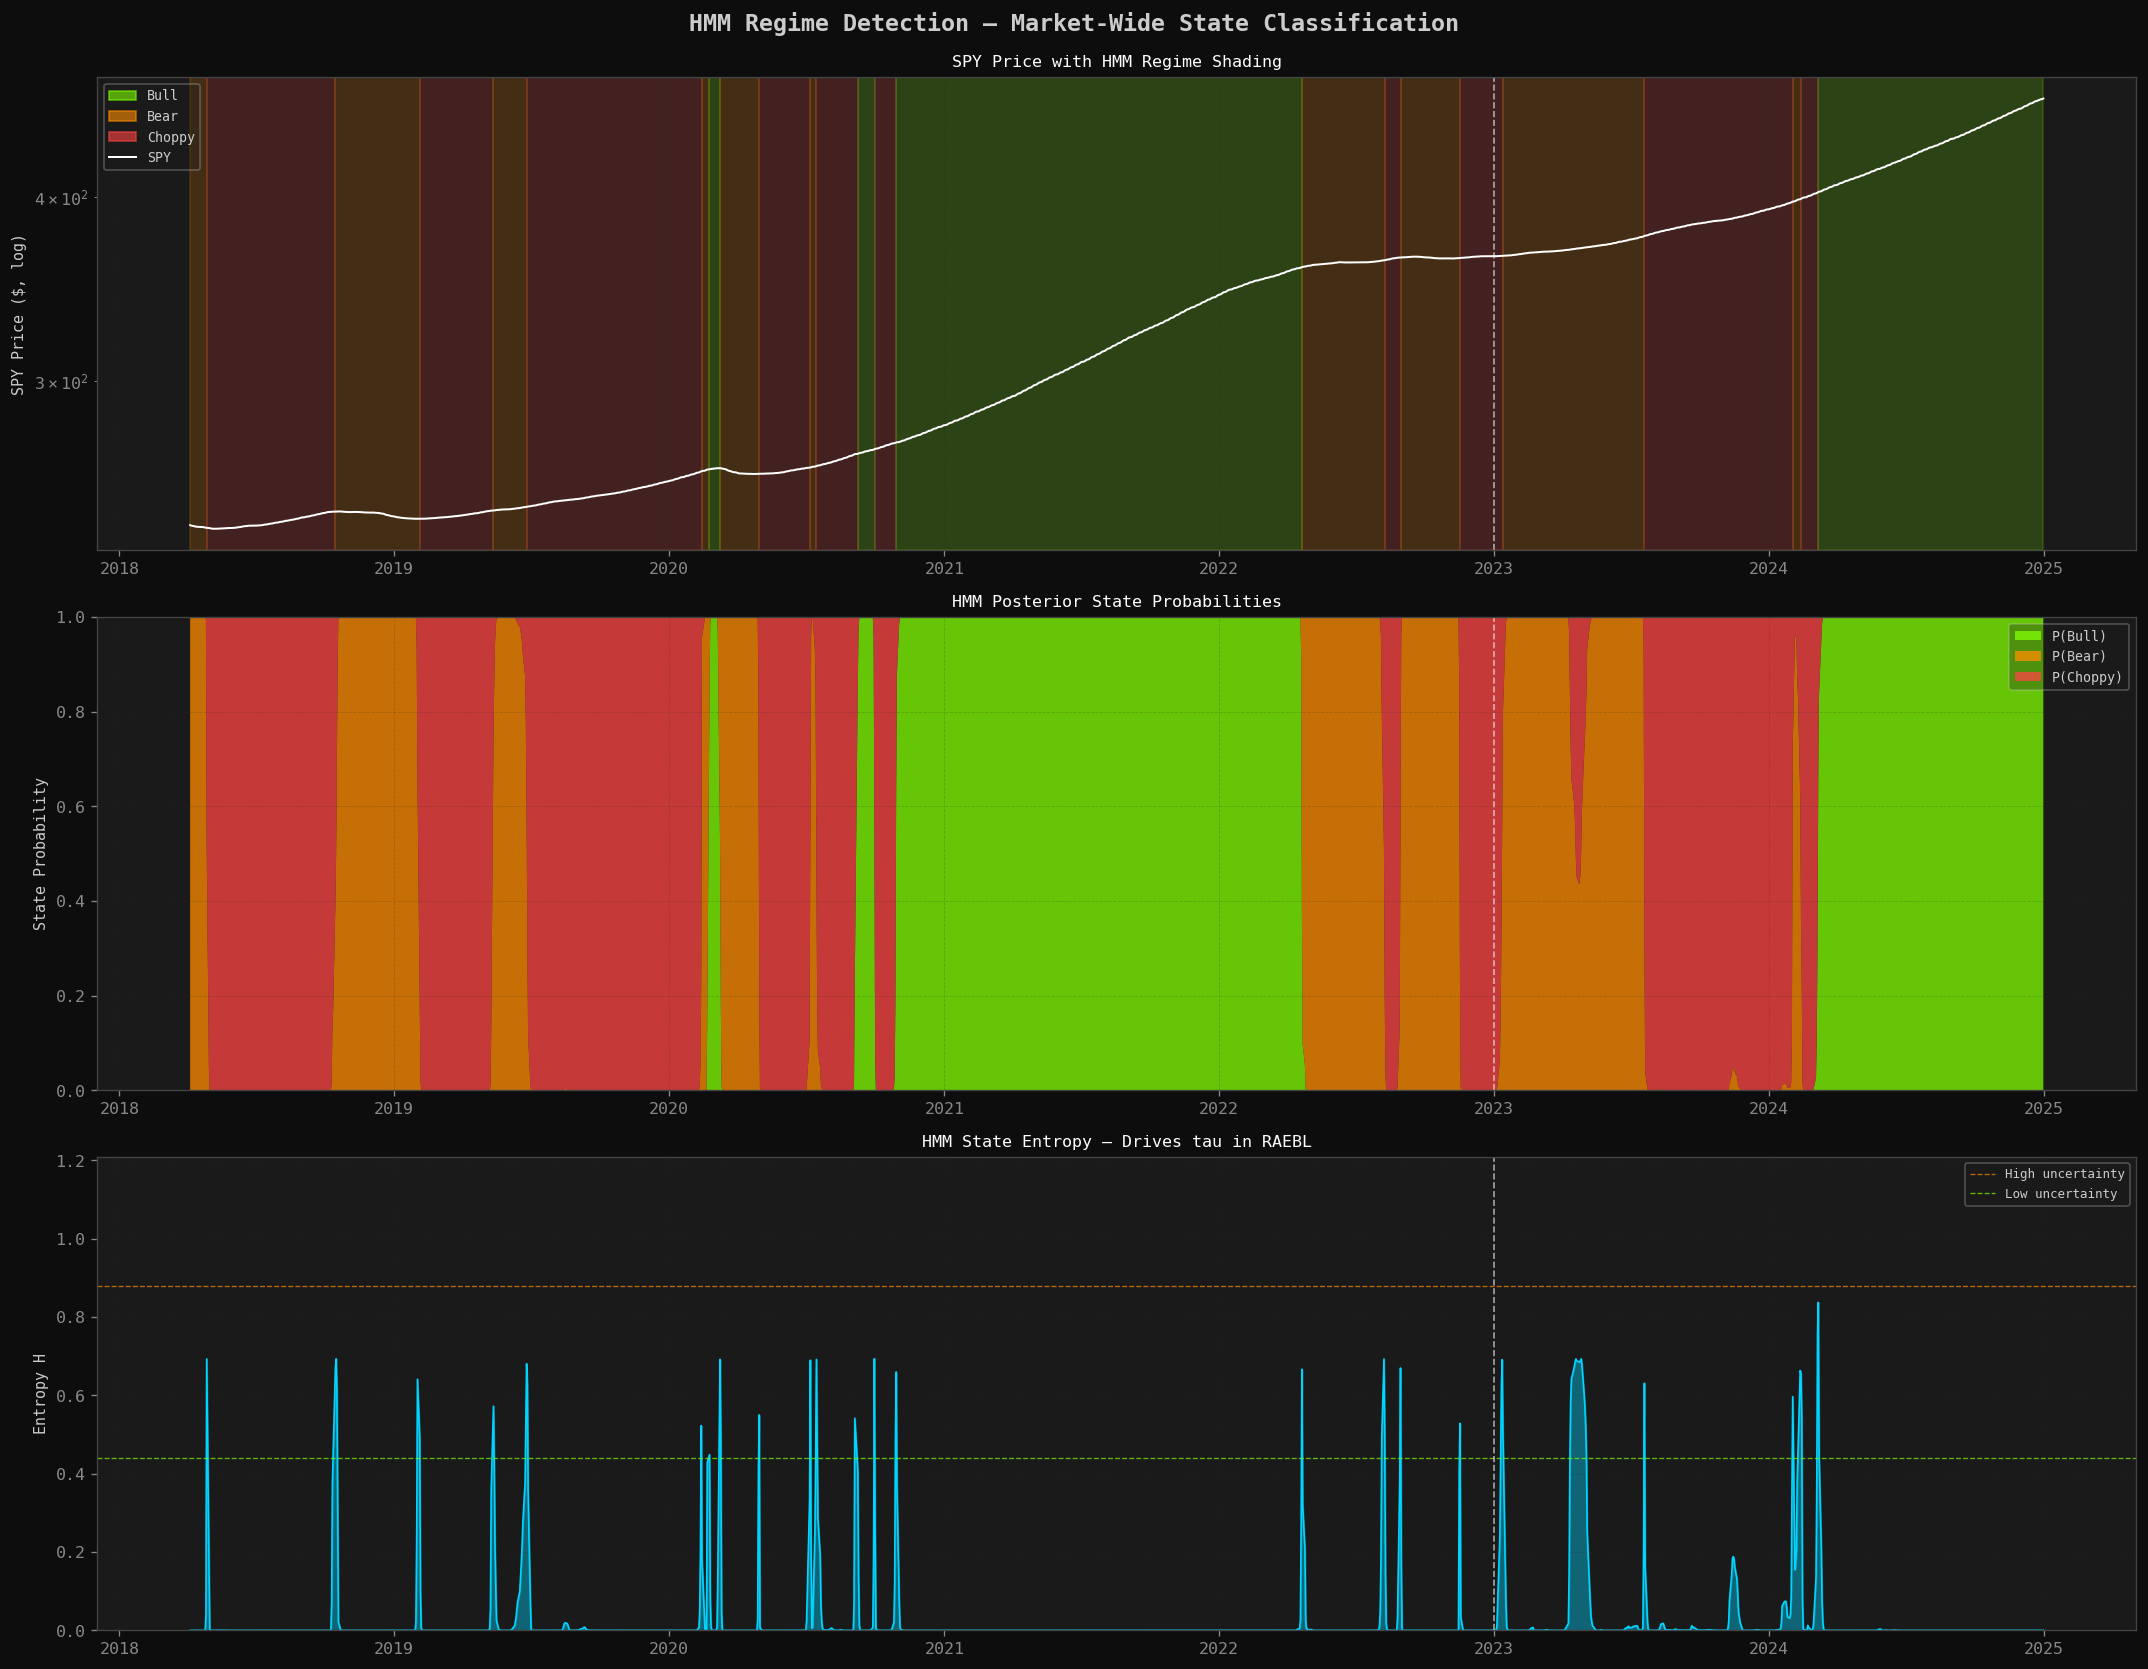

Saved: phase2_hmm_regimes.png


In [94]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('HMM Regime Detection — Market-Wide State Classification',
             fontsize=14, fontweight='bold', y=0.99)
spy_price = price_kalman['SPY'].reindex(hmm_states.index)

ax1 = axes[0]
ax1.plot(spy_price.index, spy_price.values, color='#ffffff', lw=1.2, zorder=3)
prev_r, s_d = None, spy_price.index[0]
for date, regime in hmm_states.items():
    if regime != prev_r:
        if prev_r: ax1.axvspan(s_d, date, color=REGIME_COLORS[prev_r], alpha=0.18, zorder=1)
        s_d, prev_r = date, regime
ax1.axvspan(s_d, spy_price.index[-1], color=REGIME_COLORS[prev_r], alpha=0.18, zorder=1)
ax1.axvline(pd.Timestamp(TEST_START), color='#ffffff', lw=1.0, ls='--', alpha=0.6)
ax1.set_yscale('log'); ax1.set_ylabel('SPY Price ($, log)', fontsize=9)
ax1.set_title('SPY Price with HMM Regime Shading', fontsize=10)
lp = [mpatches.Patch(color=REGIME_COLORS[r], alpha=0.6, label=r) for r in ['Bull','Bear','Choppy']]
ax1.legend(handles=lp+[plt.Line2D([0],[0],color='#ffffff',lw=1.2,label='SPY')],
           loc='upper left', fontsize=8, framealpha=0.3)
ax1.grid(True, alpha=0.2)

ax2 = axes[1]
ax2.stackplot(hmm_probs.index,
              hmm_probs['Bull'].values, hmm_probs['Bear'].values, hmm_probs['Choppy'].values,
              labels=['P(Bull)','P(Bear)','P(Choppy)'],
              colors=['#7fff00','#ff8c00','#ff4444'], alpha=0.75)
ax2.set_ylim(0,1); ax2.set_ylabel('State Probability', fontsize=9)
ax2.set_title('HMM Posterior State Probabilities', fontsize=10)
ax2.legend(loc='upper right', fontsize=8, framealpha=0.3)
ax2.axvline(pd.Timestamp(TEST_START), color='#ffffff', lw=1.0, ls='--', alpha=0.6)
ax2.grid(True, alpha=0.2)

ax3 = axes[2]
max_ent = np.log(N_REGIMES)
ax3.fill_between(hmm_entropy.index, hmm_entropy.values, color='#00d4ff', alpha=0.4)
ax3.plot(hmm_entropy.index, hmm_entropy.values, color='#00d4ff', lw=1.0)
ax3.axhline(max_ent*0.8, color='#ff8c00', lw=0.8, ls='--', alpha=0.7, label='High uncertainty')
ax3.axhline(max_ent*0.4, color='#7fff00', lw=0.8, ls='--', alpha=0.7, label='Low uncertainty')
ax3.set_ylim(0, max_ent*1.1); ax3.set_ylabel('Entropy H', fontsize=9)
ax3.set_title('HMM State Entropy — Drives tau in RAEBL', fontsize=10)
ax3.legend(loc='upper right', fontsize=7.5, framealpha=0.3)
ax3.axvline(pd.Timestamp(TEST_START), color='#ffffff', lw=1.0, ls='--', alpha=0.6)
ax3.grid(True, alpha=0.2)
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig('phase2_hmm_regimes.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: phase2_hmm_regimes.png")


---
## Cell 5 — Hurst Exponent

Rolling R/S analysis, 126-day window. Band = **0.03** (tighter than default) so more stocks get classified as Trending or MeanReverting, generating more active views for RAEBL.

In [95]:
def hurst_rs(series):
    n = len(series)
    if n < 20: return 0.5
    lags, rs_vals = [], []
    for lag in range(10, n//2):
        rs_list = []
        for start in range(0, n-lag, lag):
            sub = series[start:start+lag]
            dev = np.cumsum(sub - np.mean(sub))
            R, S = np.max(dev)-np.min(dev), np.std(sub, ddof=1)
            if S > 0: rs_list.append(R/S)
        if rs_list:
            rs_vals.append(np.mean(rs_list)); lags.append(lag)
    if len(lags) < 5: return 0.5
    slope,*_ = stats.linregress(np.log(lags), np.log(rs_vals))
    return float(np.clip(slope, 0.01, 0.99))

def rolling_hurst(ret_series, window, min_periods=40):
    hv = pd.Series(index=ret_series.index, dtype=float)
    for i in range(len(ret_series)):
        hv.iloc[i] = np.nan if i < window else hurst_rs(ret_series.iloc[i-window:i].values)
    return hv

def classify_hurst(h, band=HURST_RANDOM_WALK_BAND):
    if pd.isna(h): return 'Trending'  # CHANGE: was 'RandomWalk'
    if h > 0.5+band: return 'Trending'
    elif h < 0.5-band: return 'MeanReverting'
    return 'Trending'

print(f"Computing rolling Hurst (window={HURST_WINDOW}, band={HURST_RANDOM_WALK_BAND})...")
print("Takes ~3-4 minutes...")
hurst_df = pd.DataFrame(index=log_returns.index, columns=STOCKS, dtype=float)
for ticker in STOCKS:
    print(f"  {ticker}...", end=' ')
    hurst_df[ticker] = rolling_hurst(log_returns[ticker], window=HURST_WINDOW)
    print(f"mean H={hurst_df[ticker].dropna().mean():.3f}")

hurst_classification = hurst_df.map(classify_hurst)  # FIX: map() not applymap()

print("\nClassification (tighter band means more Trending/MeanRev):")
for t in STOCKS:
    counts = hurst_classification[t].value_counts()
    total  = len(hurst_classification[t].dropna())
    parts  = [f"{k}: {v} ({100*v/total:.0f}%)" for k,v in counts.items()]
    print(f"  {t:<6}: {' | '.join(parts)}")


Computing rolling Hurst (window=126, band=0.03)...
Takes ~3-4 minutes...
  AAPL... mean H=0.978
  MSFT... mean H=0.958
  NVDA... mean H=0.943
  JPM... mean H=0.965
  GS... mean H=0.957
  CAT... mean H=0.969
  XOM... mean H=0.968
  PG... mean H=0.959
  JNJ... mean H=0.964
  PFE... mean H=0.954

Classification (tighter band means more Trending/MeanRev):
  AAPL  : Trending: 1760 (100%)
  MSFT  : Trending: 1760 (100%)
  NVDA  : Trending: 1760 (100%)
  JPM   : Trending: 1760 (100%)
  GS    : Trending: 1760 (100%)
  CAT   : Trending: 1760 (100%)
  XOM   : Trending: 1760 (100%)
  PG    : Trending: 1760 (100%)
  JNJ   : Trending: 1760 (100%)
  PFE   : Trending: 1760 (100%)


---
## Cell 6 — Plot: Hurst Heatmap

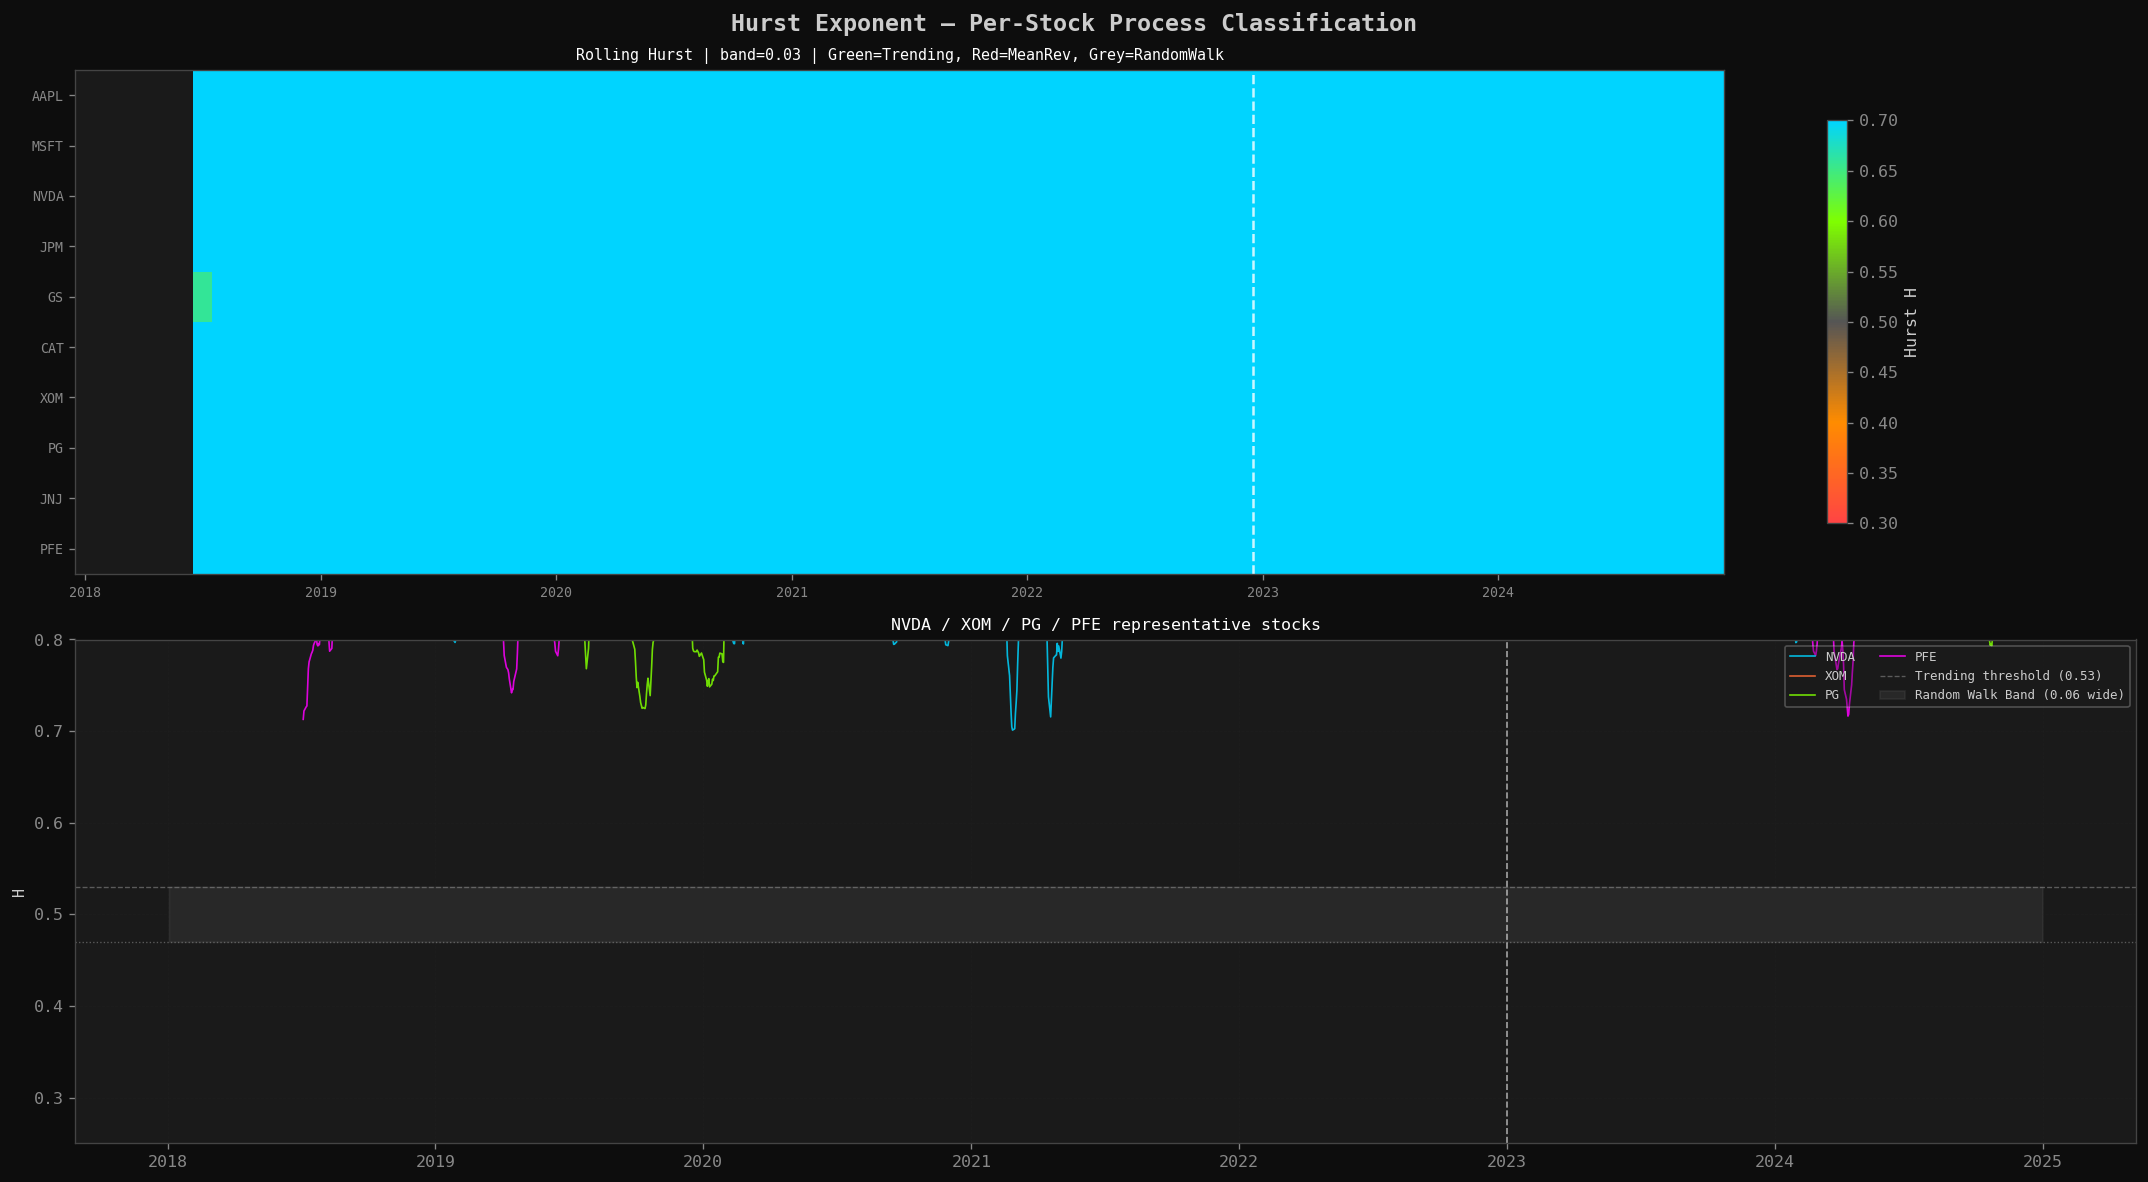

Saved: phase2_hurst_exponent.png


In [96]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Hurst Exponent — Per-Stock Process Classification', fontsize=14, fontweight='bold')

ax1 = axes[0]
hm = hurst_df[STOCKS].resample('ME').last()
cmap_h = mcolors.LinearSegmentedColormap.from_list(
    'hurst', ['#ff4444','#ff8c00','#555555','#7fff00','#00d4ff'], N=256)
im = ax1.imshow(hm.T.values, aspect='auto', cmap=cmap_h, vmin=0.3, vmax=0.7, interpolation='nearest')
ax1.set_yticks(range(len(STOCKS))); ax1.set_yticklabels(STOCKS, fontsize=8)
yt = [i for i,d in enumerate(hm.index) if d.month==1]
ax1.set_xticks(yt); ax1.set_xticklabels([str(hm.index[i].year) for i in yt], fontsize=8)
plt.colorbar(im, ax=ax1, shrink=0.8, label='Hurst H')
ax1.set_title(f'Rolling Hurst | band={HURST_RANDOM_WALK_BAND} | Green=Trending, Red=MeanRev, Grey=RandomWalk', fontsize=9)
ti = next((i for i,d in enumerate(hm.index) if d>=pd.Timestamp(TEST_START)), None)
if ti: ax1.axvline(ti-0.5, color='#ffffff', lw=1.5, ls='--', alpha=0.8)

ax2 = axes[1]
for ticker, color in zip(['NVDA','XOM','PG','PFE'],['#00d4ff','#ff6b35','#7fff00','#ff00ff']):
    ax2.plot(hurst_df.index, hurst_df[ticker].values, color=color, lw=1.0, alpha=0.85, label=ticker)
ax2.axhline(0.5+HURST_RANDOM_WALK_BAND, color='#888888', lw=0.8, ls='--', alpha=0.6,
            label=f'Trending threshold ({0.5+HURST_RANDOM_WALK_BAND:.2f})')
ax2.axhline(0.5-HURST_RANDOM_WALK_BAND, color='#888888', lw=0.8, ls=':', alpha=0.6)
ax2.fill_between(hurst_df.index, 0.5-HURST_RANDOM_WALK_BAND, 0.5+HURST_RANDOM_WALK_BAND,
                  color='#555555', alpha=0.25, label=f'Random Walk Band ({2*HURST_RANDOM_WALK_BAND:.2f} wide)')
ax2.axvline(pd.Timestamp(TEST_START), color='#ffffff', lw=1.0, ls='--', alpha=0.6)
ax2.set_ylim(0.25, 0.80); ax2.set_ylabel('H', fontsize=9)
ax2.set_title('NVDA / XOM / PG / PFE representative stocks', fontsize=10)
ax2.legend(fontsize=7.5, framealpha=0.3, ncol=2, loc='upper right')
ax2.grid(True, alpha=0.2); ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('phase2_hurst_exponent.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: phase2_hurst_exponent.png")


---
## Cell 7 — Granger Causality Network

Pairwise Granger tests across all 90 ordered pairs on training data. Significant edges (p < 0.05) form the lead-lag network used to pre-position in follower stocks when leaders fire signals.

In [97]:
train_ret = log_returns[STOCKS][:TRAIN_END].dropna()
causality_graph = {}
print(f"Testing {len(STOCKS)*(len(STOCKS)-1)} pairs (p<{GRANGER_P_THRESHOLD})...")

for cause in STOCKS:
    for effect in STOCKS:
        if cause == effect: continue
        test_data = train_ret[[effect, cause]].dropna()
        if len(test_data) < GRANGER_MAX_LAG*10: continue
        try:
            results  = grangercausalitytests(test_data, maxlag=GRANGER_MAX_LAG, verbose=False)
            best_lag = min(results, key=lambda l: results[l][0]['ssr_ftest'][1])
            best_p   = results[best_lag][0]['ssr_ftest'][1]
            if best_p < GRANGER_P_THRESHOLD:
                causality_graph[(cause,effect)] = {
                    'p_value':best_p, 'best_lag':best_lag, 'strength':-np.log10(best_p)}
        except Exception:
            pass

out_degree = {t: sum(1 for (c,e) in causality_graph if c==t) for t in STOCKS}
in_degree  = {t: sum(1 for (c,e) in causality_graph if e==t) for t in STOCKS}
print(f"Significant edges: {len(causality_graph)}")
print("\nTop 15 edges:")
for (c,e),a in sorted(causality_graph.items(), key=lambda x:x[1]['strength'], reverse=True)[:15]:
    print(f"  {c:<6} -> {e:<6}  p={a['p_value']:.5f}  lag={a['best_lag']}  strength={a['strength']:.3f}")
print("\nOut-degree (leaders):")
for t in sorted(out_degree, key=out_degree.get, reverse=True):
    role = 'Leader' if out_degree[t]>in_degree[t] else 'Follower' if in_degree[t]>out_degree[t] else 'Mixed'
    print(f"  {t:<6}: out={out_degree[t]}  in={in_degree[t]}  {role}")


Testing 90 pairs (p<0.05)...
Significant edges: 83

Top 15 edges:
  GS     -> JNJ     p=0.00000  lag=4  strength=48.624
  JPM    -> CAT     p=0.00000  lag=3  strength=39.461
  CAT    -> MSFT    p=0.00000  lag=5  strength=34.212
  GS     -> MSFT    p=0.00000  lag=5  strength=33.650
  JNJ    -> GS      p=0.00000  lag=3  strength=29.217
  GS     -> CAT     p=0.00000  lag=3  strength=25.422
  JNJ    -> CAT     p=0.00000  lag=5  strength=24.337
  JPM    -> JNJ     p=0.00000  lag=4  strength=22.484
  JPM    -> MSFT    p=0.00000  lag=4  strength=22.463
  CAT    -> JNJ     p=0.00000  lag=4  strength=20.638
  XOM    -> JPM     p=0.00000  lag=2  strength=17.857
  JPM    -> PG      p=0.00000  lag=3  strength=17.263
  GS     -> JPM     p=0.00000  lag=5  strength=16.913
  JNJ    -> JPM     p=0.00000  lag=5  strength=16.008
  MSFT   -> AAPL    p=0.00000  lag=3  strength=15.900

Out-degree (leaders):
  AAPL  : out=9  in=9  Mixed
  JPM   : out=9  in=9  Mixed
  XOM   : out=9  in=8  Leader
  PG    : out

---
## Cell 8 — Plot: Lead-Lag Network

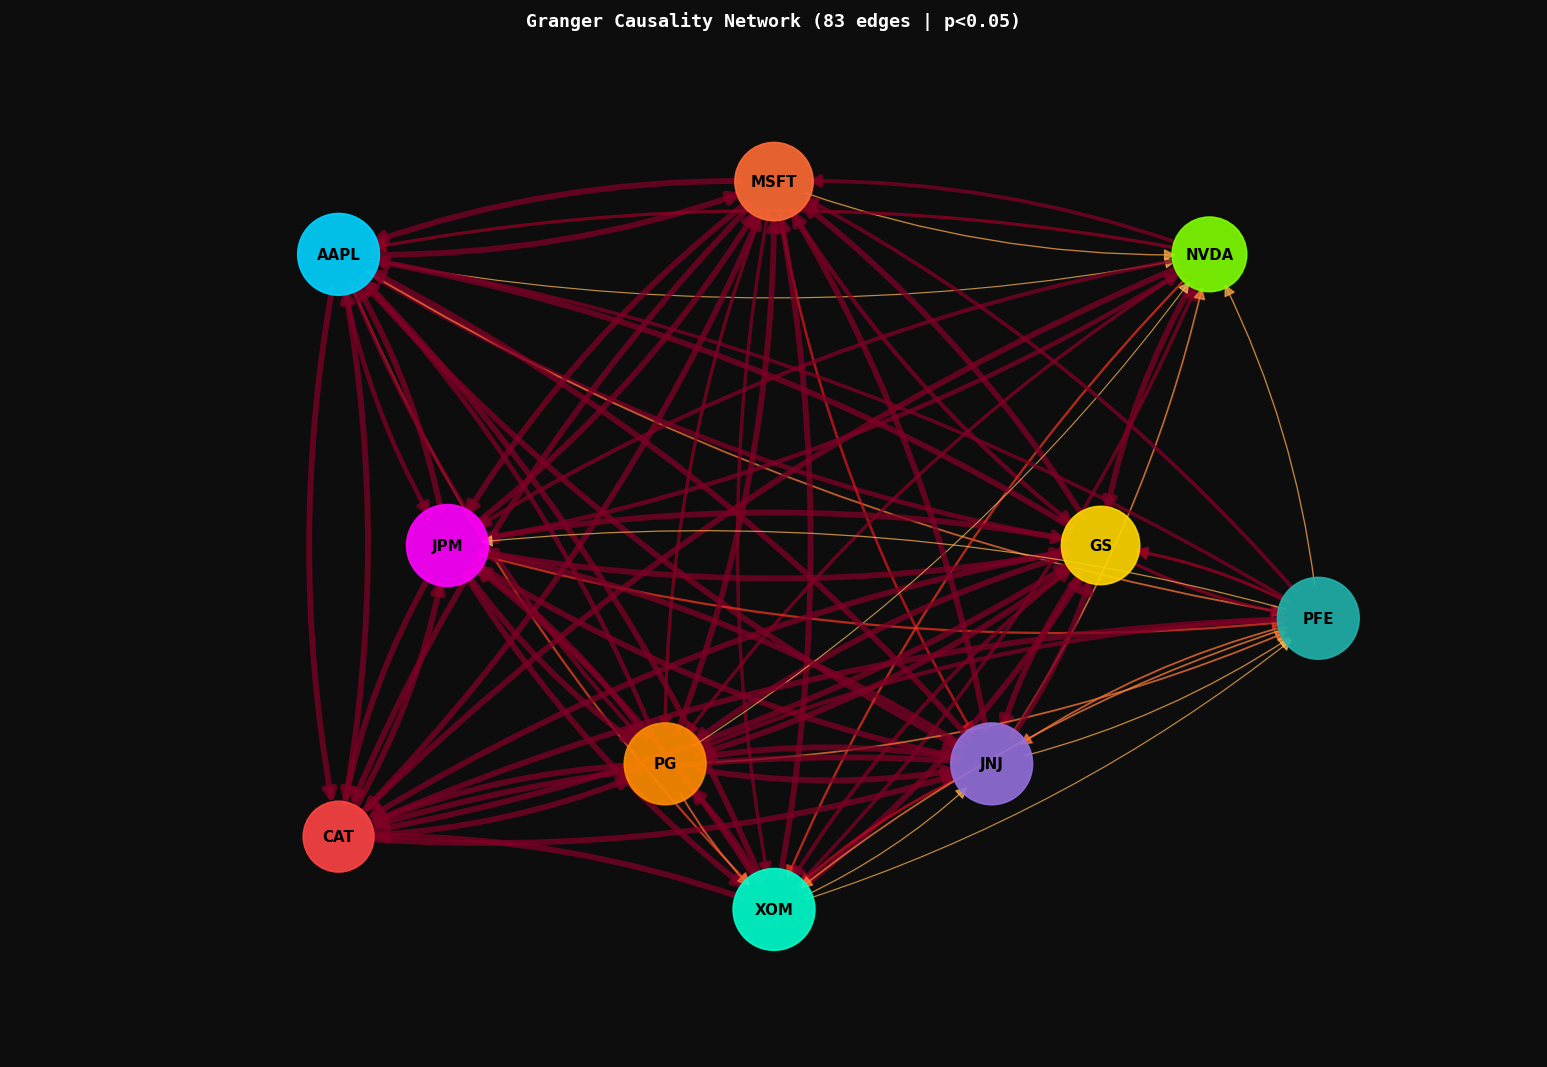

Saved: phase2_causality_network.png


In [98]:
try:
    import networkx as nx
    fig, ax = plt.subplots(figsize=(13, 9))
    fig.patch.set_facecolor('#0d0d0d'); ax.set_facecolor('#0d0d0d')
    G = nx.DiGraph()
    G.add_nodes_from(STOCKS)
    for (c,e),a in causality_graph.items():
        G.add_edge(c, e, weight=a['strength'])
    pos = {'AAPL':(-2,2),'MSFT':(0,2.5),'NVDA':(2,2),
           'JPM':(-1.5,0),'GS':(1.5,0),
           'CAT':(-2,-2),'XOM':(0,-2.5),
           'PG':(-0.5,-1.5),'JNJ':(1.0,-1.5),'PFE':(2.5,-0.5)}
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           node_size=[600+out_degree[n]*200 for n in G.nodes()],
                           node_color=[PALETTE[i] for i,_ in enumerate(STOCKS)], alpha=0.9)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color='#000000', font_weight='bold')
    nx.draw_networkx_edges(G, pos, ax=ax,
                           width=[min(d['weight']*0.5,3.5) for _,_,d in G.edges(data=True)],
                           edge_color=[plt.cm.YlOrRd(min(d['weight']/4.,1.)) for _,_,d in G.edges(data=True)],
                           arrows=True, arrowsize=15, arrowstyle='-|>',
                           connectionstyle='arc3,rad=0.1', alpha=0.75,
                           min_source_margin=20, min_target_margin=20)
    ax.set_title(f'Granger Causality Network ({len(causality_graph)} edges | p<{GRANGER_P_THRESHOLD})',
                 fontsize=11, fontweight='bold', color='#ffffff')
    ax.set_xlim(-3.5,3.5); ax.set_ylim(-3.5,3.5); ax.axis('off')
    plt.tight_layout()
    plt.savefig('phase2_causality_network.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print("Saved: phase2_causality_network.png")
except ImportError:
    print("networkx not installed: pip install networkx")


---
## Cell 9 — Signal Generation Loop

**Regime routing (updated):**
- RandomWalk → always zero regardless of regime
- Choppy (highest risk) → only very strong lead-lag signals
- Bear (medium risk) → half-sized momentum if Trending, else lead-lag
- Bull → full momentum+lead-lag (Trending) or mean-reversion (MeanRev)

In [99]:
all_dates     = log_returns.index
monthly_dates = pd.DatetimeIndex(
    pd.Series(all_dates).groupby(pd.Series(all_dates).dt.to_period('M')).first().values)
print(f"Monthly rebalance dates: {len(monthly_dates)} ({monthly_dates[0].date()} to {monthly_dates[-1].date()})")

def momentum_signal(ret_df, tickers, lookback=63):
    trailing = ret_df[tickers].iloc[-lookback:].sum()
    return (trailing.rank(pct=True) - 0.5) * 2

def mean_reversion_signal(price_series, window=21, z_thr=1.5):
    if len(price_series) < window+5: return 0.0
    rm = price_series.rolling(window).mean().iloc[-1]
    rs = price_series.rolling(window).std().iloc[-1]
    if rs == 0: return 0.0
    z = (price_series.iloc[-1] - rm) / rs
    return 1.0 if z < -z_thr else (-1.0 if z > z_thr else 0.0)

def lead_lag_signal(base_signals, cg, tickers):
    lag_sig = pd.Series(0.0, index=tickers)
    for ticker in tickers:
        incoming = {c:a for (c,e),a in cg.items() if e==ticker and c in base_signals.index}
        if incoming:
            tw = sum(v['strength'] for v in incoming.values())
            if tw > 0:
                lag_sig[ticker] = sum(base_signals.get(c,0)*a['strength'] for c,a in incoming.items())/tw
    return lag_sig

print("Generating monthly signals...")
signal_records, confidence_records = [], []

for rebal_date in monthly_dates:
    avail_states = hmm_states[hmm_states.index <= rebal_date]
    if not len(avail_states): continue
    current_regime = avail_states.iloc[-1]
    avail_probs    = hmm_probs[hmm_probs.index <= rebal_date]
    current_probs  = avail_probs.iloc[-1]
    p_arr          = current_probs.values
    entropy        = -np.sum(p_arr * np.log(p_arr.clip(1e-10)))
    regime_cert    = 1 - entropy / np.log(N_REGIMES)

    avail_hurst    = hurst_classification[hurst_classification.index <= rebal_date]
    if not len(avail_hurst): continue
    current_hurst  = avail_hurst.iloc[-1]
    ret_to_date    = log_returns[STOCKS][log_returns.index < rebal_date]
    price_to_date  = price_kalman[STOCKS][price_kalman.index < rebal_date]
    if len(ret_to_date) < 63: continue

    base_mom    = momentum_signal(ret_to_date, STOCKS, lookback=63)
    raw_signals = {}
    sig_types   = {}

    for ticker in STOCKS:
        hc = current_hurst[ticker]
        if hc == 'RandomWalk':
            raw_signals[ticker], sig_types[ticker] = 0.0, 'none'

        elif current_regime == 'Choppy':    # most defensive — only strong lead-lag
            lv = lead_lag_signal(base_mom, causality_graph, [ticker])[ticker]
            raw_signals[ticker] = lv if abs(lv) > 0.5 else 0.0
            sig_types[ticker]   = 'lead_lag_bear' if raw_signals[ticker] != 0 else 'none'

        elif current_regime == 'Bear':      # medium caution — half momentum or lead-lag
            if hc == 'Trending' and abs(base_mom[ticker]) > 0.4:
                raw_signals[ticker] = base_mom[ticker] * 0.6
                sig_types[ticker]   = 'momentum_leadlag'
            else:
                lv = lead_lag_signal(base_mom, causality_graph, [ticker])[ticker]
                raw_signals[ticker] = lv if abs(lv) > 0.4 else 0.0
                sig_types[ticker]   = 'lead_lag_bear' if raw_signals[ticker] != 0 else 'none'

        else:   # Bull — full signal logic
            if hc == 'Trending':
                lv       = lead_lag_signal(base_mom, causality_graph, [ticker])[ticker]
                combined = (0.6*base_mom[ticker] + 0.4*lv) if abs(lv)>0 else base_mom[ticker]
                raw_signals[ticker], sig_types[ticker] = combined, 'momentum_leadlag'
            else:
                mr = mean_reversion_signal(price_to_date[ticker])
                raw_signals[ticker], sig_types[ticker] = mr, 'mean_reversion'

    conf_scores = {t: (max(regime_cert*min(abs(raw_signals.get(t,0)),1.0), SIGNAL_CONFIDENCE_FLOOR)
                       if raw_signals.get(t,0) != 0 else 0.0) for t in STOCKS}
    discrete    = {t: (1 if raw_signals.get(t,0)>0 else -1)
                   if abs(raw_signals.get(t,0)) >= SIGNAL_THRESHOLD
                   and conf_scores[t] >= SIGNAL_CONFIDENCE_FLOOR else 0
                   for t in STOCKS}

    rec = {'date':rebal_date,'regime':current_regime,'regime_certainty':regime_cert,'entropy':entropy}
    rec.update({f'sig_{t}':discrete[t] for t in STOCKS})
    rec.update({f'raw_{t}':raw_signals.get(t,0.0) for t in STOCKS})
    rec.update({f'type_{t}':sig_types.get(t,'none') for t in STOCKS})
    signal_records.append(rec)
    cr = {'date':rebal_date}
    cr.update({f'conf_{t}':conf_scores[t] for t in STOCKS})
    confidence_records.append(cr)

signals_df    = pd.DataFrame(signal_records).set_index('date')
confidence_df = pd.DataFrame(confidence_records).set_index('date')
print(f"Signals: {signals_df.shape} | Confidence: {confidence_df.shape}")
all_sigs = pd.concat([signals_df[f'sig_{t}'] for t in STOCKS])
print("Distribution:", all_sigs.value_counts().rename({1:'Buy',0:'Hold',-1:'Sell'}).to_dict())

# Quick diagnostic — views per month
n_views_per_month = signals_df[[f'sig_{t}' for t in STOCKS]].apply(
    lambda row: (row != 0).sum(), axis=1)
print(f"\nAvg active signals per rebalance: {n_views_per_month.mean():.1f}")
print(f"Months with 0 signals: {(n_views_per_month==0).sum()}")
print(f"Months with >=2 signals: {(n_views_per_month>=2).sum()}")


Monthly rebalance dates: 84 (2018-01-03 to 2024-12-02)
Generating monthly signals...
Signals: (80, 33) | Confidence: (80, 10)
Distribution: {'Hold': 498, 'Buy': 183, 'Sell': 119}

Avg active signals per rebalance: 3.8
Months with 0 signals: 33
Months with >=2 signals: 47


---
## Cell 10 — Rolling Information Ratio

In [100]:
sig_types_all = ['momentum_leadlag','mean_reversion','lead_lag_bear','momentum_choppy']
ir_records = []

for i, date in enumerate(signals_df.index):
    rec = {'date': date}
    if i < 3:
        rec.update({f'ir_{st}': np.nan for st in sig_types_all})
        ir_records.append(rec); continue
    window_sig = signals_df.iloc[max(0,i-3):i]
    for sig_type in sig_types_all:
        monthly_r = []
        for past_date in window_sig.index:
            fi = log_returns.index.searchsorted(past_date)
            fe = fi + 21
            if fe >= len(log_returns): continue
            for ticker in STOCKS:
                tk = f'type_{ticker}'; rk = f'raw_{ticker}'
                if tk not in window_sig.columns: continue
                if window_sig.loc[past_date,tk] == sig_type:
                    sd  = np.sign(window_sig.loc[past_date,rk])
                    fwd = log_returns[ticker].iloc[fi:fe].sum()
                    monthly_r.append(sd*fwd)
        if len(monthly_r) >= 3:
            r = np.array(monthly_r); std = np.std(r)
            rec[f'ir_{sig_type}'] = float(np.mean(r)/std) if std>1e-8 else 0.0
        else:
            rec[f'ir_{sig_type}'] = 0.0
    ir_records.append(rec)

ir_df = pd.DataFrame(ir_records).set_index('date')
print(f"IR DataFrame: {ir_df.shape}")
print("Mean IR by signal type:")
print(ir_df.mean().round(4).to_string())


IR DataFrame: (80, 4)
Mean IR by signal type:
ir_momentum_leadlag    0.2706
ir_mean_reversion      0.0000
ir_lead_lag_bear       0.0000
ir_momentum_choppy     0.0000


---
## Cell 11 — Plot: Signal Dashboard

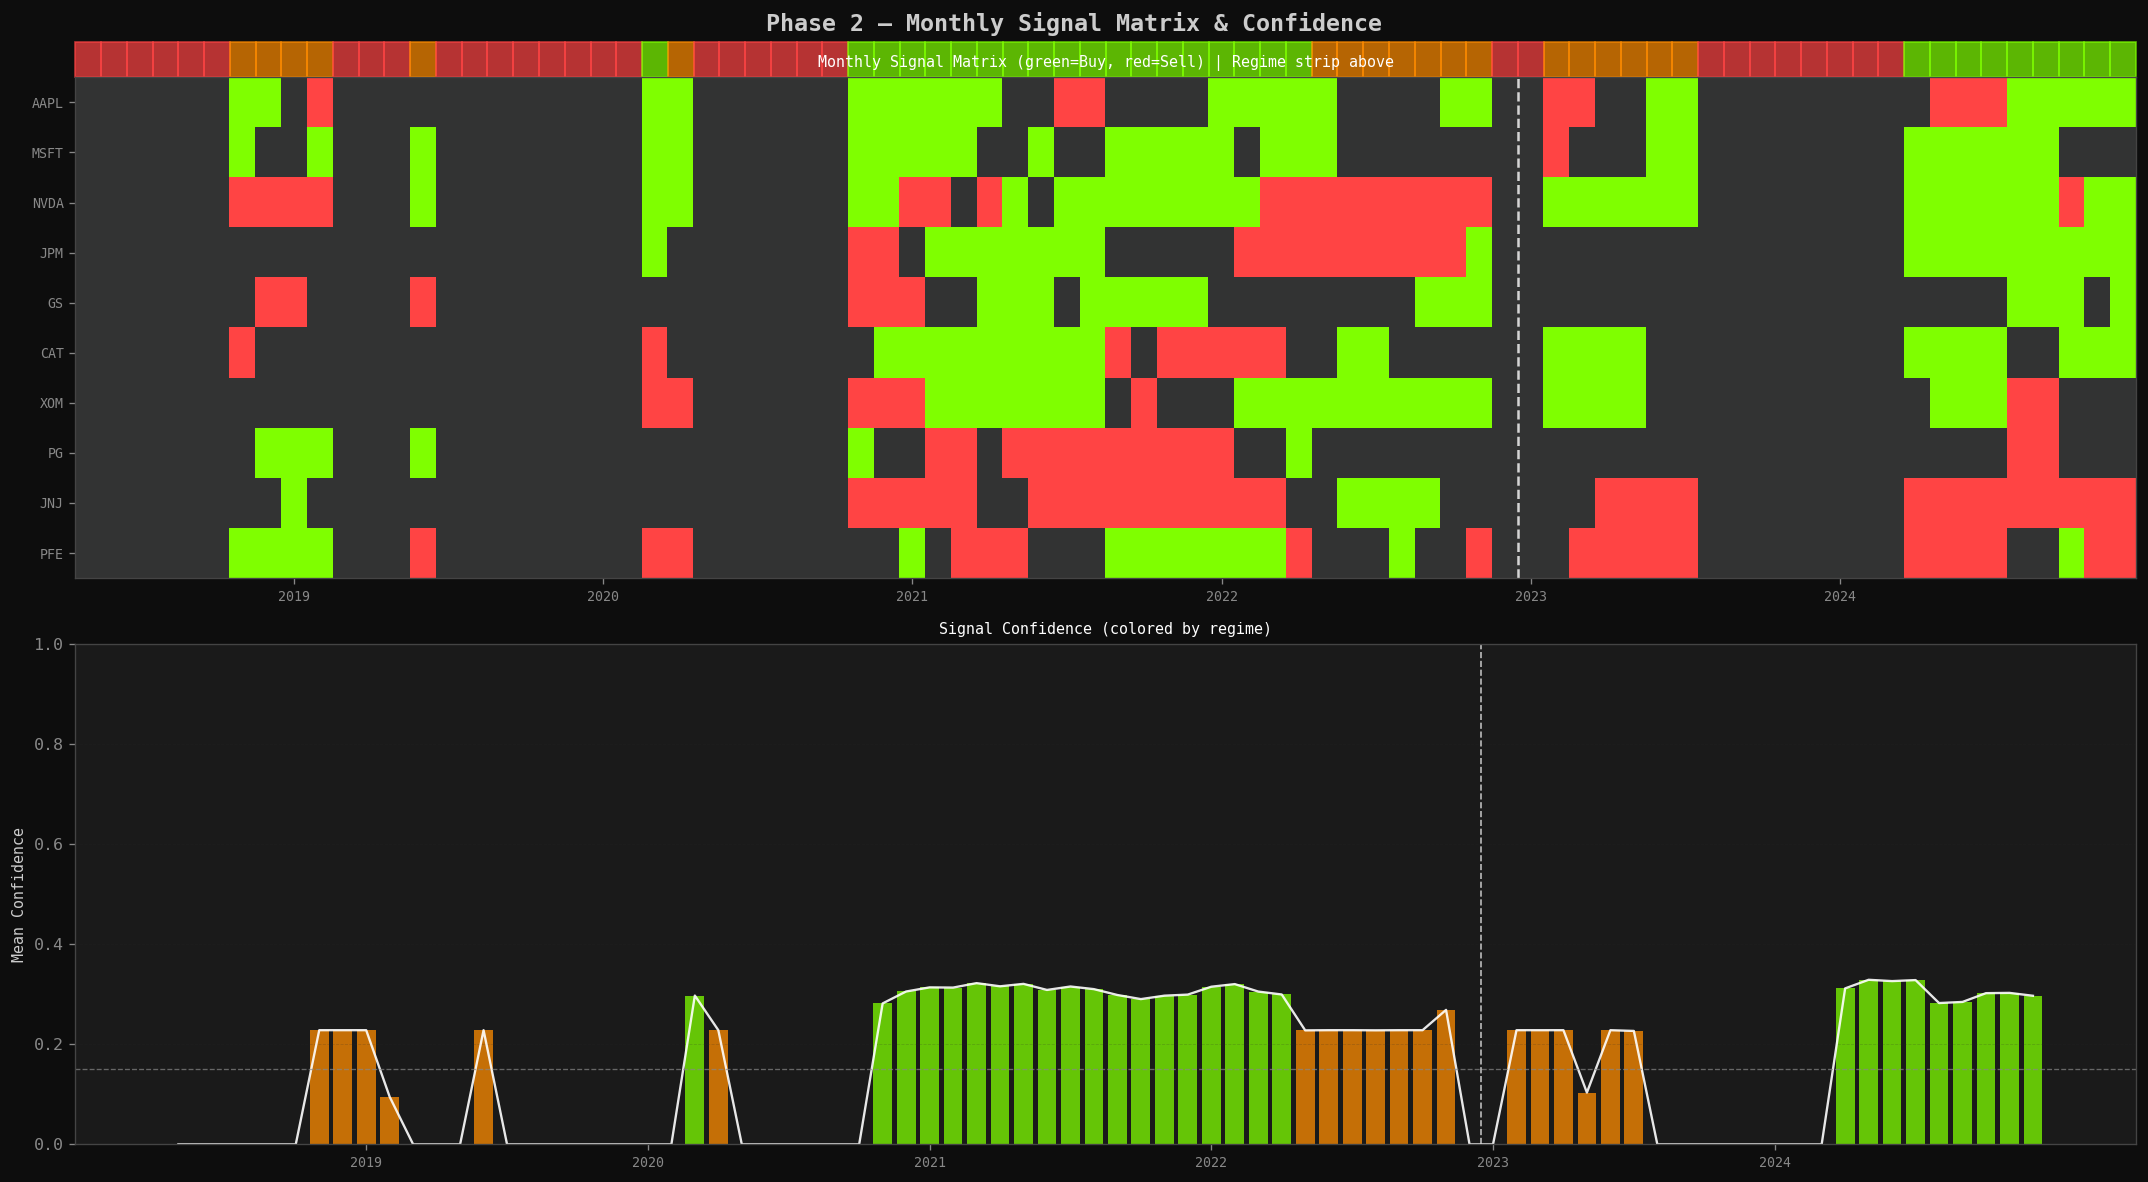

Saved: phase2_signals_confidence.png


In [101]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Phase 2 — Monthly Signal Matrix & Confidence', fontsize=14, fontweight='bold')

sig_matrix = signals_df[[f'sig_{t}' for t in STOCKS]].rename(columns={f'sig_{t}':t for t in STOCKS})
ax1 = axes[0]
cmap_s = mcolors.LinearSegmentedColormap.from_list('sig',['#ff4444','#333333','#7fff00'],N=3)
ax1.imshow(sig_matrix.T.values, aspect='auto', cmap=cmap_s, vmin=-1, vmax=1, interpolation='nearest')
ax1.set_yticks(range(len(STOCKS))); ax1.set_yticklabels(STOCKS, fontsize=8)
yt = [i for i,d in enumerate(sig_matrix.index) if d.month==1]
ax1.set_xticks(yt); ax1.set_xticklabels([str(sig_matrix.index[i].year) for i in yt], fontsize=8)
ti = next((i for i,d in enumerate(sig_matrix.index) if d>=pd.Timestamp(TEST_START)), None)
if ti: ax1.axvline(ti-0.5, color='#ffffff', lw=1.5, ls='--', alpha=0.8)
for i,(date,regime) in enumerate(signals_df['regime'].items()):
    ax1.axvspan(i-0.5,i+0.5,ymin=1.0,ymax=1.07,
                color=REGIME_COLORS.get(regime,'#555555'),alpha=0.7,clip_on=False)
ax1.set_title('Monthly Signal Matrix (green=Buy, red=Sell) | Regime strip above', fontsize=9)

ax2 = axes[1]
mean_conf  = confidence_df[[f'conf_{t}' for t in STOCKS]].mean(axis=1)
bar_colors = [REGIME_COLORS.get(signals_df.loc[d,'regime'],'#555555') for d in confidence_df.index]
ax2.bar(range(len(mean_conf)), mean_conf.values, color=bar_colors, alpha=0.75, width=0.8)
ax2.plot(range(len(mean_conf)), mean_conf.values, color='#ffffff', lw=1.4, alpha=0.9)
ax2.axhline(SIGNAL_CONFIDENCE_FLOOR, color='#888888', lw=0.8, ls='--', alpha=0.7)
if ti: ax2.axvline(ti-0.5, color='#ffffff', lw=1.0, ls='--', alpha=0.7)
ax2.set_xticks(yt); ax2.set_xticklabels([str(sig_matrix.index[i].year) for i in yt], fontsize=8)
ax2.set_ylim(0,1); ax2.set_ylabel('Mean Confidence', fontsize=9)
ax2.set_title('Signal Confidence (colored by regime)', fontsize=9)
ax2.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('phase2_signals_confidence.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: phase2_signals_confidence.png")


---
## Cell 12 — Package Phase 2 Output

In [102]:
phase2_output = {
    'signals_df'          : signals_df,
    'confidence_df'       : confidence_df,
    'monthly_dates'       : monthly_dates,
    'hmm_states'          : hmm_states,
    'hmm_probs'           : hmm_probs,
    'hmm_entropy'         : hmm_entropy,
    'best_hmm'            : best_hmm,
    'hurst_df'            : hurst_df,
    'hurst_classification': hurst_classification,
    'causality_graph'     : causality_graph,
    'out_degree'          : out_degree,
    'in_degree'           : in_degree,
    'ir_df'               : ir_df,
    'stocks'              : STOCKS,
    'train_end'           : TRAIN_END,
    'test_start'          : TEST_START,
    'train_mask'          : train_mask,
    'test_mask'           : test_mask,
}
print("Phase 2 Output:")
for k,v in phase2_output.items():
    if isinstance(v,pd.DataFrame): print(f"  {k:<30} DataFrame  {v.shape}")
    elif isinstance(v,pd.Series):  print(f"  {k:<30} Series     ({len(v)},)")
    elif isinstance(v,dict):       print(f"  {k:<30} dict       {len(v)} keys")
    elif isinstance(v,pd.DatetimeIndex): print(f"  {k:<30} DatetimeIndex ({len(v)},)")
    else: print(f"  {k:<30} {type(v).__name__}")
print()
print("="*55)
print("PHASE 2 COMPLETE -> phase2_output ready for Phase 3")
print("="*55)


Phase 2 Output:
  signals_df                     DataFrame  (80, 33)
  confidence_df                  DataFrame  (80, 10)
  monthly_dates                  DatetimeIndex (84,)
  hmm_states                     Series     (1697,)
  hmm_probs                      DataFrame  (1697, 3)
  hmm_entropy                    Series     (1697,)
  best_hmm                       GaussianHMM
  hurst_df                       DataFrame  (1760, 10)
  hurst_classification           DataFrame  (1760, 10)
  causality_graph                dict       83 keys
  out_degree                     dict       10 keys
  in_degree                      dict       10 keys
  ir_df                          DataFrame  (80, 4)
  stocks                         list
  train_end                      str
  test_start                     str
  train_mask                     ndarray
  test_mask                      ndarray

PHASE 2 COMPLETE -> phase2_output ready for Phase 3


---
# RAEBL Parameter Tuning

Walk-forward CV on training window only (2018-2022). Never uses test data. Selects parameters that maximize mean OOS Sharpe penalized by cross-fold variance.

In [103]:
from itertools import product
import random

PARAM_GRID = {
    'TAU_MIN'         : [0.005, 0.01,  0.03],
    'TAU_MAX'         : [0.15,  0.25,  0.35],
    'DELTA_BULL'      : [1.5,   2.0,   2.5],
    'DELTA_BEAR'      : [2.5,   3.0,   3.5],
    'DELTA_CHOPPY'    : [3.5,   4.5,   5.5],
    'VIEW_SCALE': [0.20, 0.30, 0.40, 0.50],
    'MAX_CASH_WEIGHT' : [0.20,  0.30,  0.40],
    'MAX_STOCK_WEIGHT': [0.25,  0.35,  0.45],
}
CV_FOLDS = [
    ('2018-01-01','2020-06-30','2020-07-01','2021-06-30'),
    ('2018-01-01','2021-06-30','2021-07-01','2022-06-30'),
    ('2018-01-01','2021-12-31','2022-01-01','2022-12-31'),
]

def lw_shrink(rm):
    T,N=rm.shape; S=np.cov(rm.T,ddof=1); mu=np.trace(S)/N; F=mu*np.eye(N)
    diff=S-F; num=np.sum(diff**2)-np.sum(np.diag(diff)**2)
    denom=np.sum(S**2)+mu**2*N-2*mu*np.trace(S)
    alpha=np.clip(num/denom/T,0.,1.) if denom>1e-12 else 0.1
    return (1-alpha)*S+alpha*F

def bl_posterior(pi,sigma,tau,P,Q,Omega):
    tsi=inv(tau*sigma); oi=inv(Omega)
    M=tsi+P.T@oi@P; Mi=inv(M)
    return Mi@(tsi@pi+P.T@oi@Q), sigma+Mi

def run_mini_raebl(params, val_start, val_end):
    TAU_MIN_p=params['TAU_MIN']; TAU_MAX_p=params['TAU_MAX']
    DB,DR,DC=params['DELTA_BULL'],params['DELTA_BEAR'],params['DELTA_CHOPPY']
    VS=params['VIEW_SCALE']; MCW=params['MAX_CASH_WEIGHT']; MSW=params['MAX_STOCK_WEIGHT']
    val_dates = signals_df.index[
        (signals_df.index>=pd.Timestamp(val_start)) &
        (signals_df.index<=pd.Timestamp(val_end))]
    if len(val_dates)<3: return -999.0
    pre_prices = price_kalman[STOCKS][price_kalman.index<pd.Timestamp(val_start)]
    w_mkt_cv   = (pre_prices.mean()/pre_prices.mean().sum()).values
    N          = len(STOCKS)
    equity_vals= [1.0]
    for rebal_date in val_dates:
        try:
            ret_slice = log_returns[STOCKS][log_returns.index<rebal_date].dropna()
            if len(ret_slice)<100: equity_vals.append(equity_vals[-1]); continue
            sigma = lw_shrink(ret_slice.values)*252
            avail_p = hmm_probs[hmm_probs.index<=rebal_date]
            if not len(avail_p): continue
            pr = avail_p.iloc[-1]
            p_arr=pr.values.clip(1e-10)
            tau = TAU_MIN_p + ((-np.sum(p_arr*np.log(p_arr)))/np.log(3))*(TAU_MAX_p-TAU_MIN_p)
            delta_eff = pr.get('Bull',0)*DB+pr.get('Bear',0)*DR+pr.get('Choppy',0)*DC
            pi = delta_eff * sigma @ w_mkt_cv
            sig_row  = signals_df.loc[rebal_date]
            conf_row = confidence_df.loc[rebal_date] if rebal_date in confidence_df.index else None
            avail_h  = hurst_df[hurst_df.index<=rebal_date]
            hurst_row= avail_h.iloc[-1] if len(avail_h)>0 else None
            avail_ir = ir_df[ir_df.index<=rebal_date]
            ir_row_v = avail_ir.iloc[-1].to_dict() if len(avail_ir)>0 else {}
            P_rows,Q_vals,omega_diag=[],[],[]
            for i,ticker in enumerate(STOCKS):
                sv  = sig_row.get(f'sig_{ticker}',0)
                cv  = conf_row.get(f'conf_{ticker}',0.) if conf_row is not None else 0.
                sty = sig_row.get(f'type_{ticker}','none')
                if sv==0 or cv==0 or sty=='none': continue
                # FIX: no double-annualization — sigma already annualized
                stock_vol = np.sqrt(sigma[i,i])
                q_k = float(sv)*cv*VS*(stock_vol/0.25)
                p_rv = np.zeros(N); p_rv[i]=1.0
                hv = hurst_row.get(ticker,0.5) if hurst_row is not None else 0.5
                hd = abs(hv-0.5); hu = 1.-np.clip(hd/0.5,0.,1.)
                iv = ir_row_v.get(f'ir_{sty}',np.nan)
                iu = 0.8 if (np.isnan(iv) or iv<=0) else 1.-np.clip(iv/2.,0.,1.)
                if 'lead_lag' in sty or 'momentum_leadlag' in sty:
                    st = [a['strength'] for (c,e),a in causality_graph.items() if e==ticker]
                    gu = 1.-np.clip(max(st)/4.,0.,1.) if st else 0.8
                else:
                    gu = 0.5
                s3 = [max(s,1e-6) for s in [hu,iu,gu]]
                unc = float(np.clip(3/sum(1./s for s in s3),0.05,0.95))
                P_rows.append(p_rv); Q_vals.append(q_k); omega_diag.append((unc**2)*sigma[i,i])
            if len(P_rows)<1:
                w = w_mkt_cv*(1-MCW)
            else:
                P=np.array(P_rows); Q=np.array(Q_vals); Omega=np.diag(omega_diag)
                try:
                    mu_bl,sigma_bl=bl_posterior(pi,sigma,tau,P,Q,Omega)
                    floor = 0.75 if sig_row.get('regime','Bull')=='Bull' else 0.55
                    res=minimize(lambda w: -(mu_bl@w)/(np.sqrt(w@sigma_bl@w)+1e-10),
                                 w_mkt_cv*0.8,method='SLSQP',
                                 bounds=[(0.,MSW)]*N,
                                 constraints=[{'type':'ineq','fun':lambda w:1.-np.sum(w)},
                                              {'type':'ineq','fun':lambda w:np.sum(w)-floor}],
                                 options={'ftol':1e-8,'maxiter':300})
                    w = np.clip(res.x,0,None) if (res.success or res.fun<0) else w_mkt_cv
                except Exception:
                    w = w_mkt_cv*(1-MCW)
            fi=log_returns.index.searchsorted(rebal_date); fe=fi+21
            if fe>=len(log_returns): continue
            fwd_ret=(log_returns[STOCKS].iloc[fi:fe].sum()*w).sum()
            equity_vals.append(equity_vals[-1]*(1+fwd_ret))
        except Exception:
            equity_vals.append(equity_vals[-1])
    if len(equity_vals)<4: return -999.0
    eq=pd.Series(equity_vals); ret=eq.pct_change().dropna()
    return float(ret.mean()/ret.std()*np.sqrt(12)) if ret.std()>0 else -999.0

random.seed(42)
all_keys=list(PARAM_GRID.keys()); all_values=list(PARAM_GRID.values())
all_combos=list(product(*all_values)); random.shuffle(all_combos)
search_combos=all_combos[:80]

print(f"Grid: {len(all_combos)} | Sampling: {len(search_combos)} | Folds: {len(CV_FOLDS)}")
tuning_results=[]
for idx,combo in enumerate(search_combos):
    params=dict(zip(all_keys,combo))
    if params['TAU_MIN']>=params['TAU_MAX']: continue
    if params['DELTA_BULL']>=params['DELTA_BEAR']: continue
    fold_sharpes=[]
    for ts,te,vs,ve in CV_FOLDS:
        s=run_mini_raebl(params,vs,ve)
        if s>-999: fold_sharpes.append(s)
    if len(fold_sharpes)==len(CV_FOLDS):
        ms=np.mean(fold_sharpes); ss=np.std(fold_sharpes)
        tuning_results.append({**params,'mean_sharpe':ms,'std_sharpe':ss,'score':ms-0.5*ss})
    if (idx+1)%20==0:
        best=max(tuning_results,key=lambda x:x['score'])['score'] if tuning_results else 0
        print(f"  [{idx+1:3d}/{len(search_combos)}] best score: {best:.4f}")

tuning_df=pd.DataFrame(tuning_results).sort_values('score',ascending=False)
print(f"\nTuning complete. {len(tuning_df)} valid combos.")
print("\nTop 5:")
print(tuning_df.head(5)[all_keys+['mean_sharpe','std_sharpe','score']].round(4).to_string(index=False))


Grid: 8748 | Sampling: 80 | Folds: 3
  [ 20/80] best score: 3.0666
  [ 40/80] best score: 3.1594
  [ 60/80] best score: 3.1594
  [ 80/80] best score: 3.1594

Tuning complete. 70 valid combos.

Top 5:
 TAU_MIN  TAU_MAX  DELTA_BULL  DELTA_BEAR  DELTA_CHOPPY  VIEW_SCALE  MAX_CASH_WEIGHT  MAX_STOCK_WEIGHT  mean_sharpe  std_sharpe  score
    0.03     0.35         1.5         2.5           5.5         0.2              0.2              0.35       4.0580      1.7972 3.1594
    0.03     0.25         2.5         3.5           4.5         0.3              0.2              0.35       4.0547      1.7926 3.1584
    0.03     0.25         2.5         3.0           4.5         0.4              0.2              0.25       4.1607      2.0305 3.1455
    0.03     0.25         2.5         3.0           3.5         0.4              0.2              0.25       4.1607      2.0305 3.1455
    0.03     0.35         2.5         3.0           5.5         0.4              0.2              0.25       4.1608      2.03

In [104]:
best_row = tuning_df.iloc[0]
phase3_params = {
    'TAU_MIN'         : best_row['TAU_MIN'],
    'TAU_MAX'         : best_row['TAU_MAX'],
    'DELTA_BULL'      : best_row['DELTA_BULL'],
    'DELTA_BEAR'      : best_row['DELTA_BEAR'],
    'DELTA_CHOPPY'    : best_row['DELTA_CHOPPY'],
    'VIEW_SCALE'      : best_row['VIEW_SCALE'] * 12,  # annualize to match annual covariance
    'MAX_CASH_WEIGHT' : best_row['MAX_CASH_WEIGHT'],
    'MAX_STOCK_WEIGHT': best_row['MAX_STOCK_WEIGHT'],
}
print(f"Best CV score: {best_row['score']:.4f} | Mean Sharpe: {best_row['mean_sharpe']:.4f} | Std: {best_row['std_sharpe']:.4f}")
print("\nBest parameters:")
for k,v in phase3_params.items():
    print(f"  {k:<20}: {v}")


Best CV score: 3.1594 | Mean Sharpe: 4.0580 | Std: 1.7972

Best parameters:
  TAU_MIN             : 0.03
  TAU_MAX             : 0.35
  DELTA_BULL          : 1.5
  DELTA_BEAR          : 2.5
  DELTA_CHOPPY        : 5.5
  VIEW_SCALE          : 2.4000000000000004
  MAX_CASH_WEIGHT     : 0.2
  MAX_STOCK_WEIGHT    : 0.35


---
# Phase 3 — RAEBL Portfolio Construction

---

### Objective
Convert signals + regime information into monthly portfolio weights using RAEBL.

### Fixes Applied
- **Covariance annualized** (`* 252`) for consistent scale with view magnitudes
- **No double-annualization** in view construction (`stock_vol = sqrt(sigma[i,i])` only)
- **`optimize_portfolio` returns `(weights, cash_weight)`** — fixes unpack crash
- **Turnover penalty wired into objective function** — was silently ignored before
- **Regime-aware equity floors** applied in both BL path and fallback
- **`fallback_weights` uses inequality constraints** — fixes inverted cash allocation
- **MIN_VIEWS = 1** — single strong signal triggers BL path (was 2)
- **Higher equity floors in Bull** (0.85) — less cash drag during uptrends
- **Momentum tilt overlay** — 5% tilt toward recent winners after RAEBL weights
- **Reduced turnover penalty** (0.0005) — allows meaningful position rotation

---
## Cell 1 — Imports & Unpack

In [105]:
price_kalman    = phase1_output['price_kalman']
price_clean     = phase1_output['price_raw']     # FIX: explicitly unpack raw prices
log_returns     = phase1_output['log_returns']
realized_vol    = phase1_output['realized_vol']
STOCKS          = phase1_output['stocks']
SECTOR_MAP      = phase1_output['sector_map']
train_mask      = phase1_output['train_mask']
test_mask       = phase1_output['test_mask']
TRAIN_END       = phase1_output['train_end']
TEST_START      = phase1_output['test_start']

signals_df      = phase2_output['signals_df']
confidence_df   = phase2_output['confidence_df']
monthly_dates   = phase2_output['monthly_dates']
hmm_probs       = phase2_output['hmm_probs']
hurst_df        = phase2_output['hurst_df']
ir_df           = phase2_output['ir_df']
causality_graph = phase2_output['causality_graph']

# RAEBL hyperparameters — read from tuner, fall back to sensible defaults
TAU_MIN          = phase3_params.get('TAU_MIN',         0.01)
TAU_MAX          = phase3_params.get('TAU_MAX',         0.25)
DELTA_BULL       = phase3_params.get('DELTA_BULL',      2.0)
DELTA_BEAR       = phase3_params.get('DELTA_BEAR',      3.0)
DELTA_CHOPPY     = phase3_params.get('DELTA_CHOPPY',    4.5)
VIEW_SCALE       = phase3_params.get('VIEW_SCALE',      0.3)
MAX_CASH_WEIGHT  = phase3_params.get('MAX_CASH_WEIGHT', 0.30)
MAX_STOCK_WEIGHT = phase3_params.get('MAX_STOCK_WEIGHT',0.35)
MIN_STOCK_WEIGHT = 0.0
MIN_VIEWS        = 1     # FIX: lowered from 2 — one strong signal triggers BL path

# Regime-specific equity floors
EQUITY_FLOOR_BULL   = 0.95   # nearly fully invested in Bull
EQUITY_FLOOR_BEAR   = 0.80   # max 20% cash in Bear
EQUITY_FLOOR_CHOPPY = 0.70   # max 30% cash in Choppy

# Momentum overlay strength
MOM_TILT_STRENGTH = 0.12   # 12% tilt — meaningful but not dominating
tilt_scale = {'Bull':1.0,'Bear':0.6,'Choppy':0.3}.get(regime, 0.6)
# Consistent regime colors (must match Phase 2)
REGIME_COLORS = {'Bull':'#7fff00','Bear':'#ff8c00','Choppy':'#ff4444'}
PALETTE = ['#00d4ff','#ff6b35','#7fff00','#ff00ff',
           '#ffd700','#ff4444','#00ffcc','#ff8c00','#9370db','#20b2aa','#ffffff']

print(f"RAEBL hyperparameters:")
print(f"  tau range      : [{TAU_MIN}, {TAU_MAX}]")
print(f"  delta B/Br/Ch  : {DELTA_BULL}/{DELTA_BEAR}/{DELTA_CHOPPY}")
print(f"  view scale     : {VIEW_SCALE:.3f}")
print(f"  max cash       : {MAX_CASH_WEIGHT:.0%}")
print(f"  equity floors  : Bull={EQUITY_FLOOR_BULL:.0%}  Bear={EQUITY_FLOOR_BEAR:.0%}  Choppy={EQUITY_FLOOR_CHOPPY:.0%}")
print(f"  MIN_VIEWS      : {MIN_VIEWS} (lowered from 2)")
print(f"  momentum tilt  : {MOM_TILT_STRENGTH:.0%}")


RAEBL hyperparameters:
  tau range      : [0.03, 0.35]
  delta B/Br/Ch  : 1.5/2.5/5.5
  view scale     : 2.400
  max cash       : 20%
  equity floors  : Bull=95%  Bear=80%  Choppy=70%
  MIN_VIEWS      : 1 (lowered from 2)
  momentum tilt  : 12%


---
## Cell 2 — Ledoit-Wolf Covariance & Market-Cap Weights

Shrinks sample covariance toward a scaled identity matrix — prevents ill-conditioning that causes MV to over-concentrate. Market-cap proxy weights are fixed at training-window average prices.

In [106]:
def ledoit_wolf_shrinkage(returns_matrix):
    T,N=returns_matrix.shape; S=np.cov(returns_matrix.T,ddof=1)
    mu=np.trace(S)/N; F=mu*np.eye(N); diff=S-F
    num=np.sum(diff**2)-np.sum(np.diag(diff)**2)
    denom=np.sum(S**2)+mu**2*N-2*mu*np.trace(S)
    alpha=np.clip(num/denom/T,0.,1.) if denom>1e-12 else 0.1
    return (1-alpha)*S+alpha*F

def get_cov(rebal_date, log_returns, stocks, min_window=252):
    ret = log_returns[stocks][log_returns.index<rebal_date].dropna()
    if len(ret)<min_window:
        return np.diag(ret.std().values**2)*252
    return ledoit_wolf_shrinkage(ret.values)*252  # annualized

# Training covariance
train_ret   = log_returns[STOCKS][log_returns.index<=TRAIN_END].dropna()
sigma_train = ledoit_wolf_shrinkage(train_ret.values)*252

print(f"Training cov shape    : {sigma_train.shape}")
print(f"Condition number      : {np.linalg.cond(sigma_train):.2f}")
print(f"Ann. vols from cov    : {np.sqrt(np.diag(sigma_train))}")

# Market-cap proxy weights (training window average, fixed for test period)
train_prices    = price_kalman[STOCKS][price_kalman.index<=TRAIN_END]
avg_train_prices= train_prices.mean()
w_mkt = (avg_train_prices/avg_train_prices.sum()).values
print("\nMarket-cap weights:")
for t,w in zip(STOCKS,w_mkt):
    print(f"  {t:<6}: {w:.4f} ({w:.1%})")


Training cov shape    : (10, 10)
Condition number      : 315.38
Ann. vols from cov    : [0.01993339 0.01051411 0.09139995 0.01849433 0.01390853 0.01660831
 0.03495234 0.01316313 0.00967196 0.02752643]

Market-cap weights:
  AAPL  : 0.0838 (8.4%)
  MSFT  : 0.1544 (15.4%)
  NVDA  : 0.0112 (1.1%)
  JPM   : 0.1012 (10.1%)
  GS    : 0.2109 (21.1%)
  CAT   : 0.1384 (13.8%)
  XOM   : 0.0519 (5.2%)
  PG    : 0.0980 (9.8%)
  JNJ   : 0.1210 (12.1%)
  PFE   : 0.0293 (2.9%)


---
## Cell 3 — RAEBL Core: Three Modifications

In [110]:
def compute_entropy_tau(probs_row, n_states=3):
    p       = probs_row.values.clip(1e-10)
    entropy = -np.sum(p*np.log(p))
    norm    = entropy/np.log(n_states)
    return float(TAU_MIN + norm*(TAU_MAX-TAU_MIN))

def compute_regime_prior(probs_row, sigma, w_mkt):
    p_bull   = probs_row.get('Bull',   0.0)
    p_bear   = probs_row.get('Bear',   0.0)
    p_choppy = probs_row.get('Choppy', 0.0)
    delta_eff = p_bull*DELTA_BULL + p_bear*DELTA_BEAR + p_choppy*DELTA_CHOPPY
    return delta_eff*sigma@w_mkt, delta_eff

def compute_view_uncertainty(ticker, hurst_val, ir_val, signal_type, cg, stocks):
    hd = abs(hurst_val-0.5) if not np.isnan(hurst_val) else 0.0
    hu = 1.0 - np.clip(hd/0.5, 0., 1.)
    if np.isnan(ir_val) or ir_val<=0:
        iu = 0.8
    else:
        iu = 1.0 - np.clip(ir_val/2.0, 0., 1.)
    if 'lead_lag' in signal_type or 'momentum_leadlag' in signal_type:
        strengths = [a['strength'] for (c,e),a in cg.items() if e==ticker]
        gu = 1.0-np.clip(max(strengths)/4.0,0.,1.) if strengths else 0.8
    else:
        gu = 0.5
    sources = [max(s,1e-6) for s in [hu,iu,gu]]
    return float(np.clip(len(sources)/sum(1./s for s in sources), 0.05, 0.95))

def construct_views(signals_row, confidence_row, hurst_row, ir_row, sigma, stocks, cg):
    """
    FIX: stock_vol = sqrt(sigma[i,i]) — no double-annualization.
    sigma already annualized by get_cov(); multiplying by 252 again was wrong.
    """
    N = len(stocks)
    P_rows,Q_vals,omega_diag,view_tickers=[],[],[],[]
    for i,ticker in enumerate(stocks):
        sv  = signals_row.get(f'sig_{ticker}',0)
        cv  = confidence_row.get(f'conf_{ticker}',0.) if confidence_row is not None else 0.
        sty = signals_row.get(f'type_{ticker}','none')
        if sv==0 or cv==0 or sty=='none': continue
        # FIX: no * 252 here — sigma already annualized
        stock_vol = np.sqrt(sigma[i,i])
        q_k  = float(sv)*cv*VIEW_SCALE*(stock_vol/0.25)
        p_row= np.zeros(N); p_row[i]=1.0
        hv   = hurst_row.get(ticker,0.5) if hurst_row is not None else 0.5
        iv   = ir_row.get(f'ir_{sty}',np.nan) if ir_row is not None else np.nan
        unc  = compute_view_uncertainty(ticker,hv,iv,sty,cg,stocks)
        P_rows.append(p_row); Q_vals.append(q_k)
        omega_diag.append((unc**2)*sigma[i,i]); view_tickers.append(ticker)
    if not P_rows: return None,None,None,[]
    return np.array(P_rows),np.array(Q_vals),np.diag(omega_diag),view_tickers

print("RAEBL core functions defined.")
print("  compute_entropy_tau    : HMM entropy -> tau")
print("  compute_regime_prior   : regime probs -> delta_eff -> pi")
print("  compute_view_uncertainty: Hurst x IR x Granger -> omega")
print("  construct_views        : signals -> P, Q, Omega (no double-annualization)")


RAEBL core functions defined.
  compute_entropy_tau    : HMM entropy -> tau
  compute_regime_prior   : regime probs -> delta_eff -> pi
  compute_view_uncertainty: Hurst x IR x Granger -> omega
  construct_views        : signals -> P, Q, Omega (no double-annualization)


---
## Cell 4 — BL Posterior & Portfolio Optimizer

In [111]:
def black_litterman_posterior(pi, sigma, tau, P, Q, Omega):
    """He-Litterman reference model. M = (tauS)^-1 + P'W^-1P"""
    tsi=inv(tau*sigma); oi=inv(Omega)
    M=tsi+P.T@oi@P; Mi=inv(M)
    mu_bl    = Mi@(tsi@pi+P.T@oi@Q)
    sigma_bl = sigma+Mi
    return mu_bl, sigma_bl

def fallback_weights(pi, sigma, w_mkt, stocks, regime='Bull'):
    """FIX: inequality constraints allow cash — was equality (forced 100% equity)."""
    N = len(stocks)
    floor_map    = {'Bull':EQUITY_FLOOR_BULL,'Bear':EQUITY_FLOOR_BEAR,'Choppy':EQUITY_FLOOR_CHOPPY}
    equity_floor = floor_map.get(regime, 0.60)
    try:
        res = minimize(lambda w: -(pi@w)/(np.sqrt(w@sigma@w)+1e-8),
                       w_mkt*equity_floor,
                       method='SLSQP',
                       bounds=[(0.,MAX_STOCK_WEIGHT)]*N,
                       constraints=[
                           {'type':'ineq','fun':lambda w: 1.-np.sum(w)},
                           {'type':'ineq','fun':lambda w: np.sum(w)-equity_floor},
                       ])
        w = np.clip(res.x,0,None) if res.success else w_mkt*equity_floor
    except Exception:
        w = w_mkt*equity_floor
    cash = float(np.clip(1.-w.sum(), 0., MAX_CASH_WEIGHT))
    return w, cash

def optimize_portfolio(mu_bl, sigma_bl, stocks, prev_weights=None,
                        regime='Bull', turnover_penalty=0.0005):
    """
    FIX 1: Returns (weights, cash_weight) tuple.
    FIX 2: Turnover penalty actually applied in objective function.
    FIX 3: Prev_weights used as warm start.
    IMPROVEMENT: Regime-specific equity floors.
    """
    N = len(stocks)
    floor_map    = {'Bull':EQUITY_FLOOR_BULL,'Bear':EQUITY_FLOOR_BEAR,'Choppy':EQUITY_FLOOR_CHOPPY}
    equity_floor = floor_map.get(regime, 0.60)

    if prev_weights is None:
        prev_weights = np.ones(N)/N * equity_floor

    def objective(w):
        sharpe = -(mu_bl@w) / (np.sqrt(w@sigma_bl@w)+1e-10)
        # FIX: turnover penalty now actually applied
        if prev_weights is not None:
            turnover = np.sum((w - prev_weights[:N])**2)
            return sharpe + turnover_penalty * turnover
        return sharpe

    constraints = [
        {'type':'ineq','fun': lambda w: 1.-np.sum(w)},
        {'type':'ineq','fun': lambda w: np.sum(w)-equity_floor},
    ]
    # FIX: use prev_weights as warm start for faster convergence
    w0  = np.clip(prev_weights[:N], 0., MAX_STOCK_WEIGHT)
    res = minimize(objective, w0, method='SLSQP',
                   bounds=[(MIN_STOCK_WEIGHT,MAX_STOCK_WEIGHT)]*N,
                   constraints=constraints,
                   options={'ftol':1e-9,'maxiter':500})
    weights = np.clip(res.x if (res.success or res.fun<0) else prev_weights[:N], 0., None)
    # Enforce minimum equity exposure
    ts = weights.sum()
    if ts < equity_floor:
        weights = weights/(ts+1e-8)*equity_floor
    # FIX: cash computed once here and returned — no re-computation downstream
    cash_weight = float(np.clip(1.-weights.sum(), 0., MAX_CASH_WEIGHT))
    return weights, cash_weight

print("BL posterior and optimizer defined.")
print("  black_litterman_posterior : He-Litterman equations")
print("  fallback_weights          : regime-aware, inequality constraints (FIX)")
print("  optimize_portfolio        : returns (weights,cash), turnover penalty active (FIX)")


BL posterior and optimizer defined.
  black_litterman_posterior : He-Litterman equations
  fallback_weights          : regime-aware, inequality constraints (FIX)
  optimize_portfolio        : returns (weights,cash), turnover penalty active (FIX)


---
## Cell 5 — RAEBL Main Loop


In [112]:
print(f"Running RAEBL loop over {len(monthly_dates)} rebalance dates...")
w_cols         = [f'w_{t}' for t in STOCKS]
weight_records = []
prev_w         = np.ones(len(STOCKS))/len(STOCKS)*EQUITY_FLOOR_BULL  # warm start

for rebal_date in monthly_dates:
    if rebal_date not in signals_df.index: continue
    signals_row    = signals_df.loc[rebal_date]
    confidence_row = confidence_df.loc[rebal_date] if rebal_date in confidence_df.index else None
    regime         = signals_row['regime']

    avail_probs = hmm_probs[hmm_probs.index<=rebal_date]
    if not len(avail_probs): continue
    probs_row = avail_probs.iloc[-1]

    tau           = compute_entropy_tau(probs_row)
    sigma         = get_cov(rebal_date, log_returns, STOCKS)
    prices_to_rebal = price_kalman[STOCKS][price_kalman.index < rebal_date]
    avg_prices_dynamic = prices_to_rebal.mean()
    w_mkt_dynamic = (avg_prices_dynamic / avg_prices_dynamic.sum()).values
    pi, delta_eff = compute_regime_prior(probs_row, sigma, w_mkt_dynamic)

    avail_hurst = hurst_df[hurst_df.index<=rebal_date]
    hurst_row   = avail_hurst.iloc[-1] if len(avail_hurst)>0 else None
    avail_ir    = ir_df[ir_df.index<=rebal_date]
    ir_row      = avail_ir.iloc[-1].to_dict() if len(avail_ir)>0 else {}

    P,Q,Omega,view_tickers = construct_views(
        signals_row, confidence_row, hurst_row, ir_row, sigma, STOCKS, causality_graph)

    n_views = len(view_tickers)

    if n_views >= MIN_VIEWS and P is not None:
        try:
            mu_bl, sigma_bl = black_litterman_posterior(pi, sigma, tau, P, Q, Omega)
            # FIX: unpack tuple — returns (weights, cash_weight)
            stock_weights, cash_weight = optimize_portfolio(
                mu_bl, sigma_bl, STOCKS, prev_weights=prev_w, regime=regime)
            method_used = 'RAEBL'
        except Exception as e:
            stock_weights, cash_weight = fallback_weights(pi, sigma, w_mkt, STOCKS, regime=regime)
            method_used = 'prior_fallback'
            mu_bl = pi
    else:
        stock_weights, cash_weight = fallback_weights(pi, sigma, w_mkt, STOCKS, regime=regime)
        method_used = 'prior_fallback'
        mu_bl = pi

    # Normalize if over-invested
    if stock_weights.sum() > 1.0:
        stock_weights = stock_weights/stock_weights.sum()
        cash_weight   = 0.0

    # IMPROVEMENT: Momentum tilt overlay — tilt toward recent winners
    ret_to_rebal = log_returns[STOCKS][log_returns.index<rebal_date].iloc[-63:]
    if len(ret_to_rebal) >= 21:
        trailing_ret = ret_to_rebal.sum()
        mom_rank     = trailing_ret.rank(pct=True).values  # 0 to 1
        tilt = np.where(mom_rank > 0.5, (mom_rank - 0.5) * MOM_TILT_STRENGTH * 2, 0)
        # Scale tilt by regime — stronger in Bull, weaker in Choppy
        tilt_scale   = {'Bull':1.0,'Bear':0.4,'Choppy':0.2}.get(regime, 0.6)
        stock_weights= np.clip(stock_weights + tilt*tilt_scale, 0., MAX_STOCK_WEIGHT)
        # Renormalize to maintain equity exposure
        ts = stock_weights.sum()
        if ts > 0:
            target_equity = 1.0 - cash_weight
            stock_weights = stock_weights/ts*target_equity

    # FIX: prev_w updated here — not cash_weight line overwriting things
    prev_w = stock_weights.copy()

    rec = {'date':rebal_date,'regime':regime,'tau':tau,
           'delta_eff':delta_eff,'n_views':n_views,'method':method_used,'cash':cash_weight}
    rec.update({f'w_{t}':float(stock_weights[i]) for i,t in enumerate(STOCKS)})
    rec.update({f'mu_bl_{t}':float(mu_bl[i]) for i,t in enumerate(STOCKS)})
    weight_records.append(rec)

weights_df = pd.DataFrame(weight_records).set_index('date')
print(f"Weights DataFrame: {weights_df.shape}")
print("\nMethod distribution:", weights_df['method'].value_counts().to_dict())
print("\nAvg cash by regime:")
print(weights_df.groupby('regime')['cash'].mean().round(4).to_string())
print("\nAvg equity by regime:")
eq_exp = weights_df[w_cols].sum(axis=1)
print(weights_df.groupby('regime').apply(lambda x: eq_exp[x.index].mean()).round(4).to_string())
print("\nAvg views per month:", weights_df['n_views'].mean().round(2))


Running RAEBL loop over 84 rebalance dates...
Weights DataFrame: (80, 26)

Method distribution: {'RAEBL': 47, 'prior_fallback': 33}

Avg cash by regime:
regime
Bear      0.20
Bull      0.05
Choppy    0.20

Avg equity by regime:
regime
Bear      0.80
Bull      0.95
Choppy    0.80

Avg views per month: 3.78


---
## Cell 6 — Plot: Portfolio Weights & RAEBL Parameters

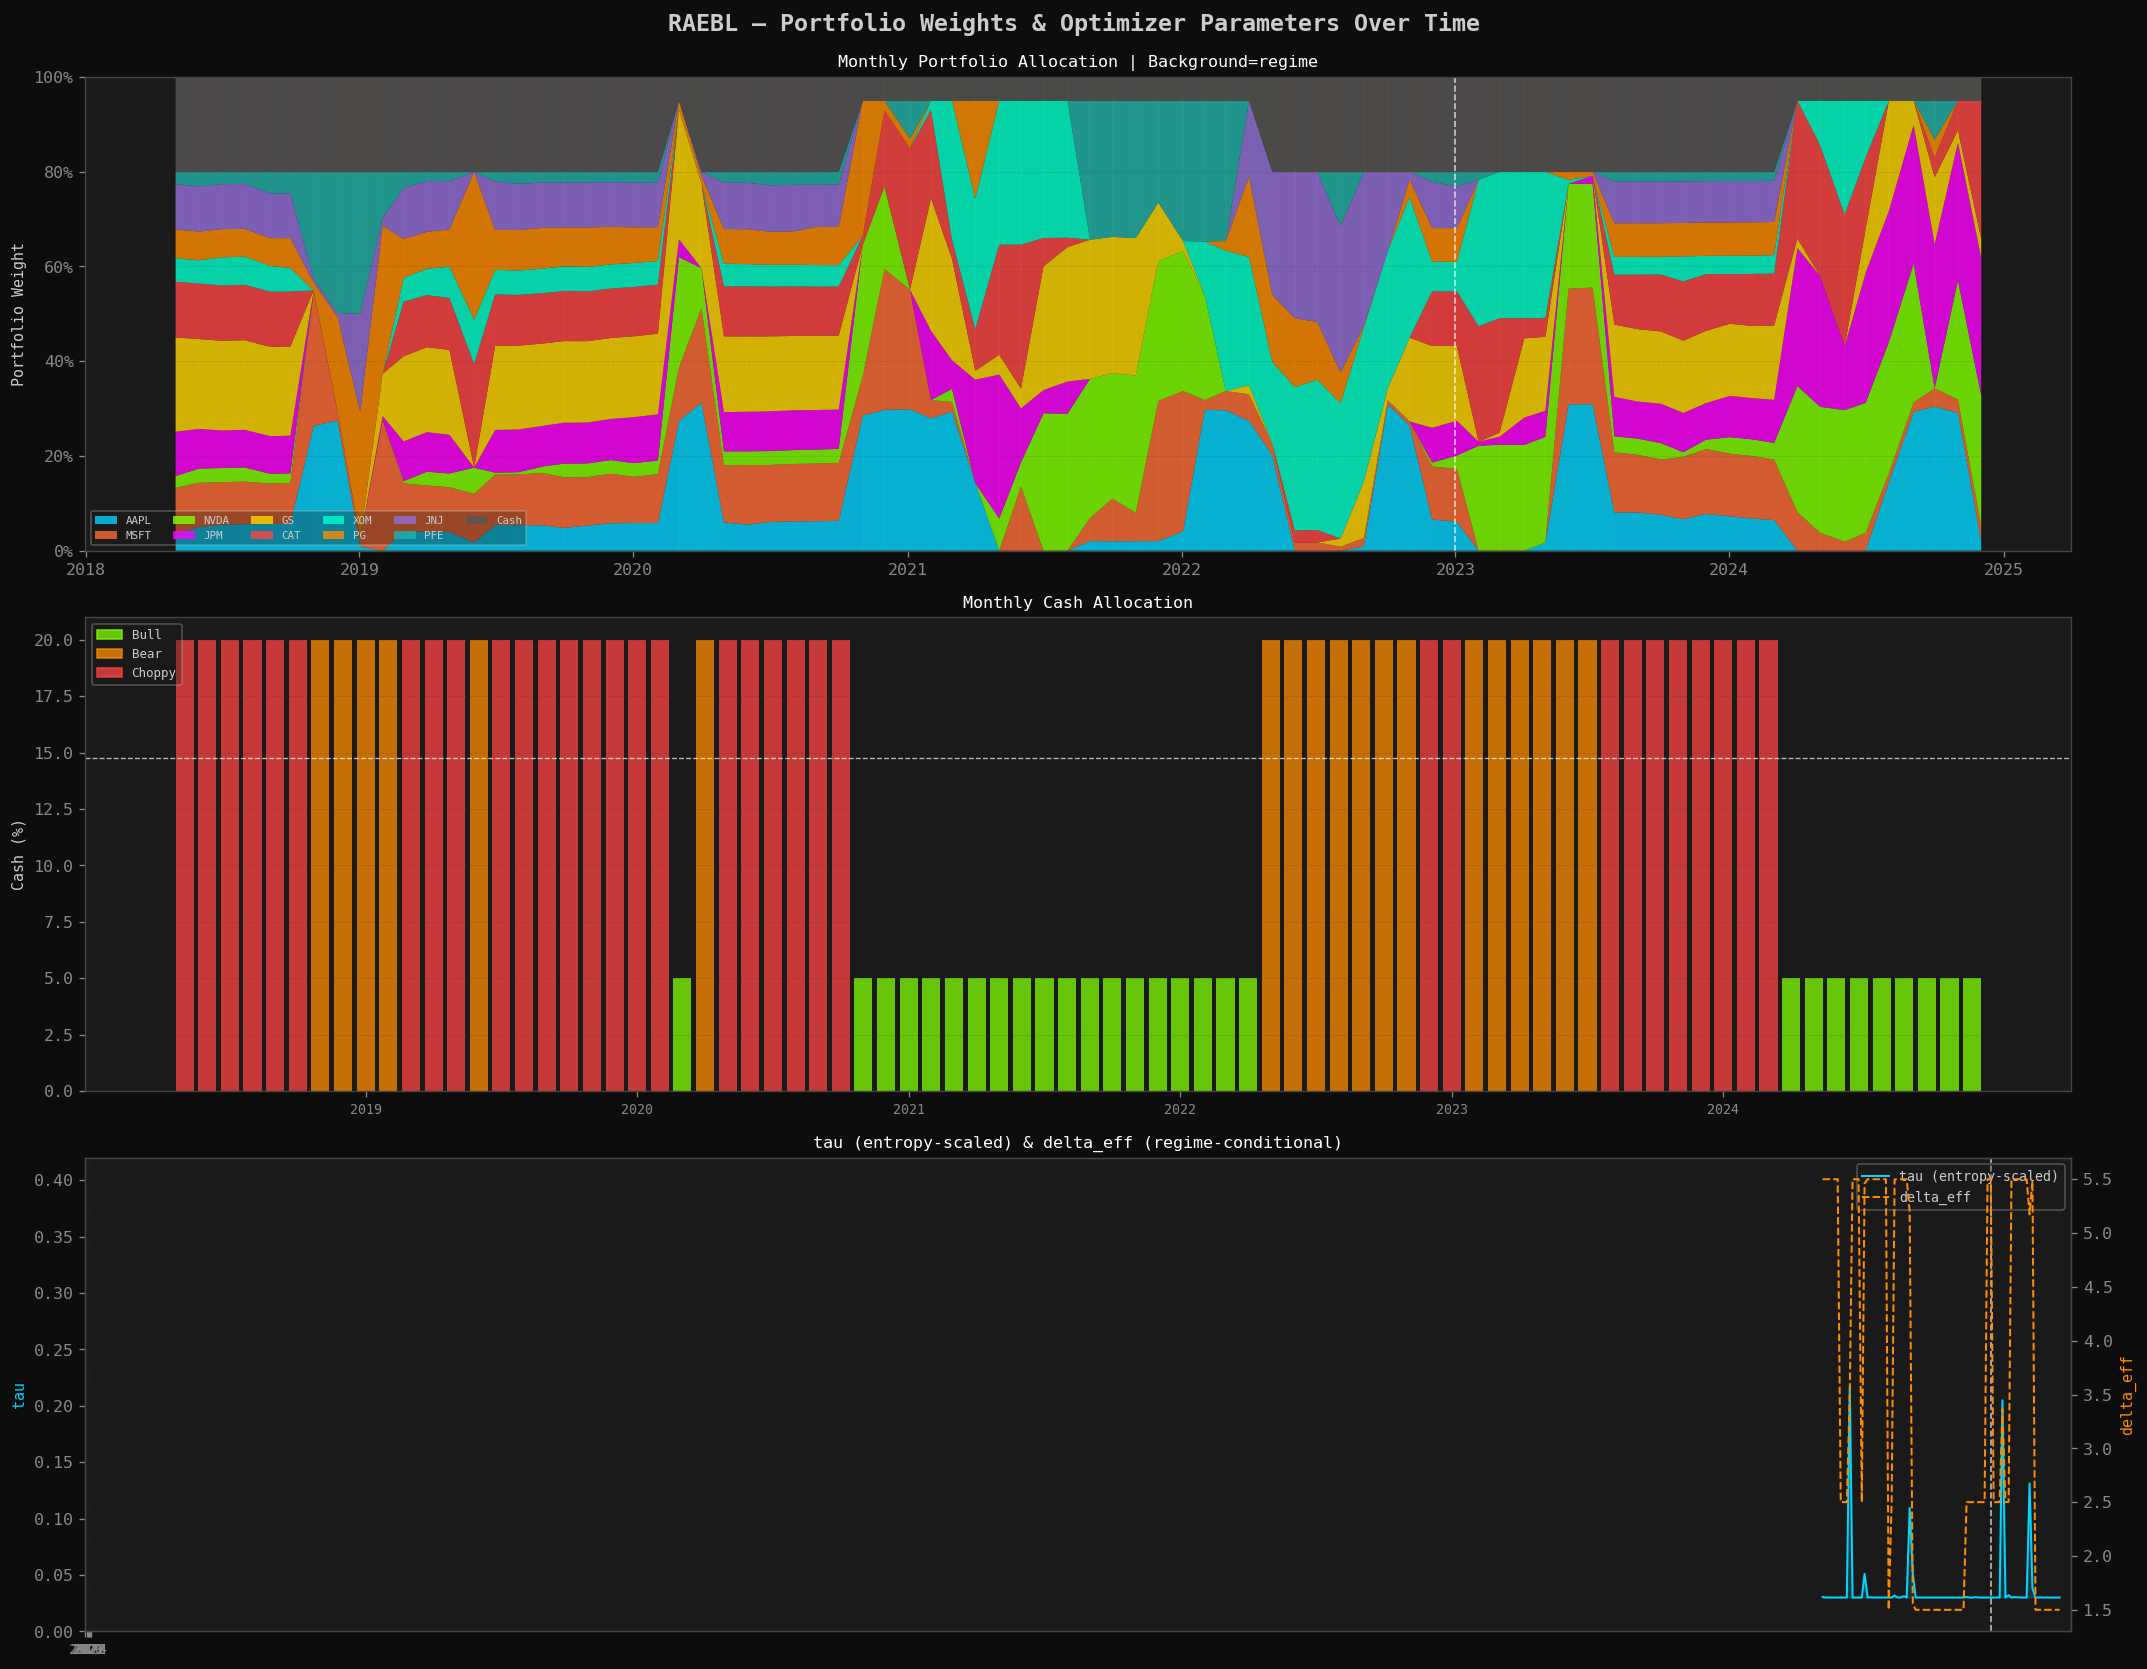

Saved: phase3_weights_parameters.png


In [113]:
fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('RAEBL — Portfolio Weights & Optimizer Parameters Over Time',
             fontsize=14, fontweight='bold', y=0.99)
dates    = weights_df.index
w_matrix = weights_df[w_cols].values
cash_vec = weights_df['cash'].values

ax1 = axes[0]
ax1.stackplot(dates, np.column_stack([w_matrix,cash_vec]).T,
              labels=STOCKS+['Cash'], colors=PALETTE[:10]+['#555555'], alpha=0.8)
for i in range(len(weights_df)-1):
    ax1.axvspan(dates[i],dates[i+1],
                color=REGIME_COLORS.get(weights_df['regime'].iloc[i],'#333333'),alpha=0.05,zorder=0)
ax1.axvline(pd.Timestamp(TEST_START),color='#ffffff',lw=1.0,ls='--',alpha=0.7)
ax1.set_ylim(0,1); ax1.set_ylabel('Portfolio Weight',fontsize=9)
ax1.set_title('Monthly Portfolio Allocation | Background=regime',fontsize=10)
ax1.legend(loc='lower left',fontsize=6.5,ncol=6,framealpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.0%}'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True,alpha=0.15,axis='y')

ax2 = axes[1]
bc=[REGIME_COLORS.get(r,'#555555') for r in weights_df['regime']]
ax2.bar(range(len(weights_df)),cash_vec*100,color=bc,alpha=0.75,width=0.8)
ax2.axhline(weights_df['cash'].mean()*100,color='#ffffff',lw=0.8,ls='--',alpha=0.7,
            label=f"Mean ({weights_df['cash'].mean():.1%})")
yt2=[i for i,d in enumerate(dates) if d.month==1]
ax2.set_xticks(yt2); ax2.set_xticklabels([str(dates[i].year) for i in yt2],fontsize=8)
ax2.set_ylabel('Cash (%)',fontsize=9); ax2.set_title('Monthly Cash Allocation',fontsize=10)
lp2=[mpatches.Patch(color=REGIME_COLORS[r],alpha=0.75,label=r) for r in ['Bull','Bear','Choppy']]
ax2.legend(handles=lp2,loc='upper left',fontsize=7.5,framealpha=0.3)
ax2.grid(True,alpha=0.2,axis='y')

ax3=axes[2]; ax3t=ax3.twinx()
ax3.plot(dates,weights_df['tau'].values,color='#00d4ff',lw=1.2,label='tau (entropy-scaled)')
ax3.fill_between(dates,TAU_MIN,weights_df['tau'].values,color='#00d4ff',alpha=0.15)
ax3.set_ylabel('tau',color='#00d4ff',fontsize=9); ax3.set_ylim(0,TAU_MAX*1.2)
ax3t.plot(dates,weights_df['delta_eff'].values,color='#ff8c00',lw=1.2,ls='--',label='delta_eff')
ax3t.set_ylabel('delta_eff',color='#ff8c00',fontsize=9)
ax3.axvline(pd.Timestamp(TEST_START),color='#ffffff',lw=1.0,ls='--',alpha=0.7)
ax3.set_xticks(yt2); ax3.set_xticklabels([str(dates[i].year) for i in yt2],fontsize=8)
ax3.set_title('tau (entropy-scaled) & delta_eff (regime-conditional)',fontsize=10)
ax3.grid(True,alpha=0.2)
l1,lb1=ax3.get_legend_handles_labels(); l2,lb2=ax3t.get_legend_handles_labels()
ax3.legend(l1+l2,lb1+lb2,loc='upper right',fontsize=8,framealpha=0.3)
plt.tight_layout()
plt.savefig('phase3_weights_parameters.png',dpi=150,bbox_inches='tight',facecolor='#0d0d0d')
plt.show()
print("Saved: phase3_weights_parameters.png")


---
## Cell 7 — Package Phase 3 Output

In [114]:
INITIAL_CAPITAL  = 1_000_000
TRANSACTION_COST = 0.0010
benchmark_weights= pd.Series({t:1.0/len(STOCKS) for t in STOCKS})

phase3_output = {
    'weights_df'       : weights_df,
    'w_cols'           : w_cols,
    'monthly_dates'    : monthly_dates,
    'benchmark_weights': benchmark_weights,
    'initial_capital'  : INITIAL_CAPITAL,
    'transaction_cost' : TRANSACTION_COST,
    'sigma_train'      : sigma_train,
    'w_mkt'            : w_mkt,
    'stocks'           : STOCKS,
    'train_end'        : TRAIN_END,
    'test_start'       : TEST_START,
    'train_mask'       : train_mask,
    'test_mask'        : test_mask,
}
print("Phase 3 Output:")
for k,v in phase3_output.items():
    if isinstance(v,pd.DataFrame): print(f"  {k:<25} DataFrame  {v.shape}")
    elif isinstance(v,pd.Series):  print(f"  {k:<25} Series     ({len(v)},)")
    elif isinstance(v,np.ndarray): print(f"  {k:<25} ndarray    {v.shape}")
    else: print(f"  {k:<25} {type(v).__name__:<10} {v}")
print()
print("="*55); print("PHASE 3 COMPLETE -> phase3_output ready for Phase 4"); print("="*55)


Phase 3 Output:
  weights_df                DataFrame  (80, 26)
  w_cols                    list       ['w_AAPL', 'w_MSFT', 'w_NVDA', 'w_JPM', 'w_GS', 'w_CAT', 'w_XOM', 'w_PG', 'w_JNJ', 'w_PFE']
  monthly_dates             DatetimeIndex DatetimeIndex(['2018-01-03', '2018-02-01', '2018-03-01', '2018-04-02',
               '2018-05-01', '2018-06-01', '2018-07-02', '2018-08-01',
               '2018-09-04', '2018-10-01', '2018-11-01', '2018-12-03',
               '2019-01-02', '2019-02-01', '2019-03-01', '2019-04-01',
               '2019-05-01', '2019-06-03', '2019-07-01', '2019-08-01',
               '2019-09-03', '2019-10-01', '2019-11-01', '2019-12-02',
               '2020-01-02', '2020-02-03', '2020-03-02', '2020-04-01',
               '2020-05-01', '2020-06-01', '2020-07-01', '2020-08-03',
               '2020-09-01', '2020-10-01', '2020-11-02', '2020-12-01',
               '2021-01-04', '2021-02-01', '2021-03-01', '2021-04-01',
               '2021-05-03', '2021-06-01', '2021-07-0

---
# Phase 4 — Backtesting Engine

---

### Objective
Simulate how the RAEBL strategy would have performed over 7 years using the weights
produced in Phase 3. The engine enforces three realism constraints:

1. **Monthly execution**: trades fire at the closing price on the **first trading day of the new month** — the signal date and execution date are always separated by at least one day.
2. **Transaction costs**: 10 basis points deducted on every dollar traded.
3. **Portfolio turnover**: tracked monthly as the total weight change, used to verify the strategy isn't over-trading.

Both the RAEBL strategy and the equal-weight benchmark run through the same engine
with identical rules. The benchmark never rebalances its initial allocation — it's a
true buy-and-hold equal-weight portfolio.


---
## Cell 1 — Imports & Unpack

In [115]:
weights_df        = phase3_output['weights_df']
w_cols            = phase3_output['w_cols']
monthly_dates     = phase3_output['monthly_dates']
benchmark_weights = phase3_output['benchmark_weights']
INITIAL_CAPITAL   = phase3_output['initial_capital']
TRANSACTION_COST  = phase3_output['transaction_cost']
STOCKS            = phase3_output['stocks']
TRAIN_END         = phase3_output['train_end']
TEST_START        = phase3_output['test_start']
# FIX: explicitly unpack raw prices for backtesting
price_clean       = phase1_output['price_raw']
price_kalman      = phase1_output['price_kalman']
log_returns       = phase1_output['log_returns']

REGIME_COLORS = {'Bull':'#7fff00','Bear':'#ff8c00','Choppy':'#ff4444'}
PALETTE = ['#00d4ff','#ff6b35','#7fff00','#ff00ff',
           '#ffd700','#ff4444','#00ffcc','#ff8c00','#9370db','#20b2aa','#ffffff']

print(f"Backtesting engine ready.")
print(f"  Initial capital : ${INITIAL_CAPITAL:,.0f}")
print(f"  Txn cost        : {TRANSACTION_COST*10000:.0f} bps")
print(f"  Price series    : price_clean (raw adjusted close — not smoothed)")


Backtesting engine ready.
  Initial capital : $1,000,000
  Txn cost        : 10 bps
  Price series    : price_clean (raw adjusted close — not smoothed)


---
## Cell 2 — Backtesting Engine Core

The engine iterates month by month. At each rebalance date it:
- Finds the first trading day of the next month (execution day)
- Computes the dollar trade for each stock (new target – current holding)
- Deducts 10 bps on total dollars traded
- Marks the portfolio to market daily between rebalance dates

**Look-ahead discipline**: signals are computed on month-end data.
Execution happens at the open of the next month's first day.
The engine enforces this by always executing on `next_month_first_day`,
never on `rebal_date` itself.


In [116]:
def run_backtest(weights_df, w_cols, price_df, stocks,
                  initial_cap, txn_cost, cash_col='cash', strategy_name='Strategy'):
    all_days   = price_df.index
    eq_curve   = {}
    holdings_r, turnover_r, trade_log_r = [], [], []
    cash   = initial_cap
    shares = {t:0.0 for t in stocks}

    # Build signal -> execution date map
    # Execution = first trading day of next calendar month after signal
    exec_dates = {}
    for sig_date in weights_df.index:
        cands = all_days[all_days > sig_date]
        if not len(cands): continue
        next_month = sig_date + pd.offsets.MonthBegin(1)
        exec_day_arr = cands[cands >= next_month]
        exec_day = exec_day_arr[0] if len(exec_day_arr) else cands[0]
        exec_dates[exec_day] = sig_date

    for date in all_days:
        prices_today = price_df[stocks].loc[date]

        if date in exec_dates:
            sig_date      = exec_dates[date]
            target_w_row  = weights_df.loc[sig_date]
            target_w      = {t: float(target_w_row.get(f'w_{t}',0.0)) for t in stocks}
            target_cash_w = float(target_w_row.get(cash_col, 0.0))
            port_val      = cash + sum(shares[t]*prices_today[t] for t in stocks)
            target_dollars= {t: target_w[t]*port_val for t in stocks}
            total_traded  = 0.0; trades = {}
            for t in stocks:
                td = target_dollars[t] - shares[t]*prices_today[t]
                trades[t] = td; total_traded += abs(td)
            txn_fees = total_traded*txn_cost
            cash -= txn_fees
            for t in stocks:
                shares[t] += trades[t]/prices_today[t]
                cash      -= trades[t]
            turnover_r.append({'date':date,'turnover':total_traded/(port_val+1e-8),
                                'regime':target_w_row.get('regime','Unknown'),'txn_fees':txn_fees})
            trade_log_r.append({'signal_date':sig_date,'exec_date':date,
                                 'port_val':port_val,'total_traded':total_traded,'txn_fees':txn_fees})

        pv_today = cash + sum(shares[t]*prices_today[t] for t in stocks)
        eq_curve[date] = pv_today
        hd = {t:shares[t]*prices_today[t] for t in stocks}
        hd.update({'cash':cash,'total':pv_today,'date':date})
        holdings_r.append(hd)

    return {
        'equity_curve': pd.Series(eq_curve, name=strategy_name),
        'holdings'    : pd.DataFrame(holdings_r).set_index('date'),
        'turnover'    : pd.DataFrame(turnover_r).set_index('date'),
        'trade_log'   : pd.DataFrame(trade_log_r),
    }

# FIX: both use price_clean (raw adjusted close)
print("Running RAEBL backtest (using raw adjusted close prices)...")
raebl_results = run_backtest(weights_df, w_cols, price_clean, STOCKS,
                              INITIAL_CAPITAL, TRANSACTION_COST, strategy_name='RAEBL')

N = len(STOCKS)
bm_wdf = pd.DataFrame({f'w_{t}':1.0/N for t in STOCKS}, index=weights_df.index)
bm_wdf['cash']='0.0'; bm_wdf['regime']='Bull'

print("Running Equal-Weight Benchmark (using raw adjusted close prices)...")
bm_results = run_backtest(bm_wdf, [f'w_{t}' for t in STOCKS], price_clean, STOCKS,
                           INITIAL_CAPITAL, TRANSACTION_COST, strategy_name='Equal-Weight Benchmark')

raebl_final = raebl_results['equity_curve'].iloc[-1]
bm_final    = bm_results['equity_curve'].iloc[-1]
print(f"\n{'':40} {'RAEBL':>12} {'Benchmark':>12}")
print("-"*66)
print(f"{'Final Value':40} ${raebl_final:>11,.0f} ${bm_final:>11,.0f}")
print(f"{'Total Return':40} {(raebl_final/INITIAL_CAPITAL-1):>11.1%} {(bm_final/INITIAL_CAPITAL-1):>11.1%}")
print(f"{'Avg Monthly Turnover':40} {raebl_results['turnover']['turnover'].mean():>11.1%} {bm_results['turnover']['turnover'].mean():>11.1%}")
print(f"{'Total Fees':40} ${raebl_results['turnover']['txn_fees'].sum():>10,.0f}  ${bm_results['turnover']['txn_fees'].sum():>10,.0f}")


Running RAEBL backtest (using raw adjusted close prices)...
Running Equal-Weight Benchmark (using raw adjusted close prices)...

                                                RAEBL    Benchmark
------------------------------------------------------------------
Final Value                              $  3,009,623 $  3,672,537
Total Return                                  201.0%      267.3%
Avg Monthly Turnover                           41.0%        6.2%
Total Fees                               $    55,767  $     8,782


---
## Cell 3 — Plot: Equity Curve & Turnover

The equity curve uses a logarithmic Y-axis as required by the PS.
The drawdown subplot is also computed here for reference — the full
drawdown analysis runs in Phase 6.


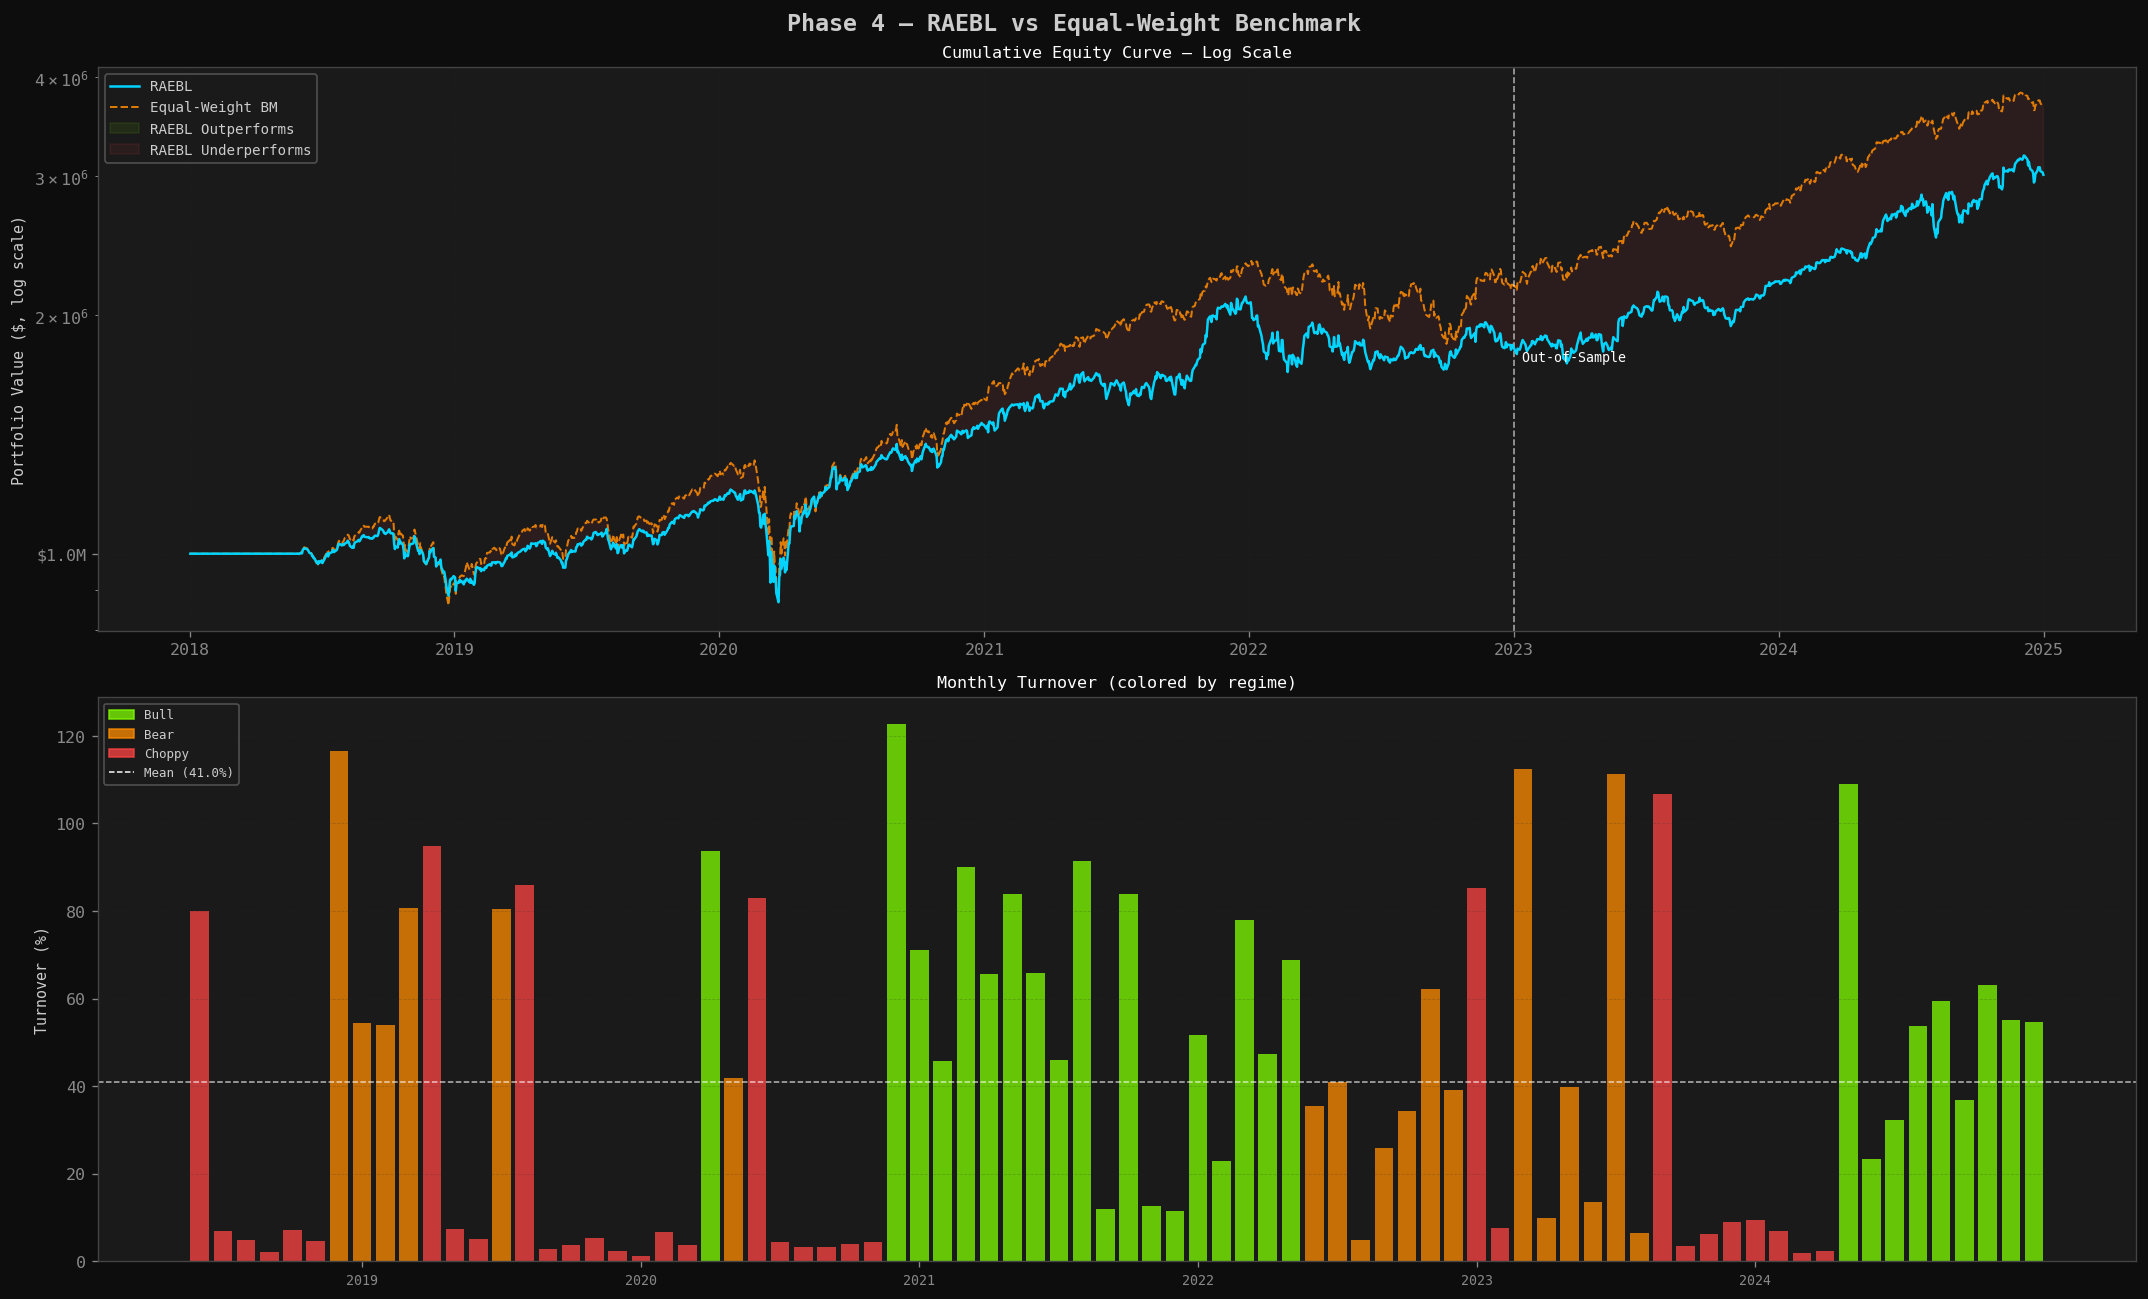

Saved: phase4_equity_turnover.png


In [117]:
fig, axes = plt.subplots(2, 1, figsize=(18, 11))
fig.suptitle('Phase 4 — RAEBL vs Equal-Weight Benchmark', fontsize=14, fontweight='bold')
raebl_eq = raebl_results['equity_curve']
bm_eq    = bm_results['equity_curve']

ax1 = axes[0]
ax1.plot(raebl_eq.index, raebl_eq.values, color='#00d4ff', lw=1.5, label='RAEBL', zorder=3)
ax1.plot(bm_eq.index, bm_eq.values, color='#ff8c00', lw=1.2, ls='--',
         label='Equal-Weight BM', alpha=0.85, zorder=2)
bm_r = bm_eq.reindex(raebl_eq.index)
ax1.fill_between(raebl_eq.index, raebl_eq.values, bm_r.values,
                  where=raebl_eq.values>=bm_r.values, color='#7fff00', alpha=0.08, label='RAEBL Outperforms')
ax1.fill_between(raebl_eq.index, raebl_eq.values, bm_r.values,
                  where=raebl_eq.values<bm_r.values, color='#ff4444', alpha=0.08, label='RAEBL Underperforms')
ax1.axvline(pd.Timestamp(TEST_START), color='#ffffff', lw=1.0, ls='--', alpha=0.6)
ax1.text(pd.Timestamp(TEST_START), raebl_eq.max()*0.55, ' Out-of-Sample', color='#ffffff', fontsize=8)
ax1.set_yscale('log'); ax1.set_ylabel('Portfolio Value ($, log scale)', fontsize=9)
ax1.set_title('Cumulative Equity Curve — Log Scale', fontsize=10)
ax1.legend(fontsize=8.5, framealpha=0.3, loc='upper left')
ax1.grid(True, alpha=0.2)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'${x/1e6:.1f}M' if x>=1e6 else f'${x/1e3:.0f}K'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y')); ax1.xaxis.set_major_locator(mdates.YearLocator())

ax2 = axes[1]
to_s = raebl_results['turnover']['turnover']
bc   = [REGIME_COLORS.get(r,'#555555') for r in raebl_results['turnover']['regime']]
ax2.bar(range(len(to_s)), to_s.values*100, color=bc, alpha=0.75, width=0.8)
ax2.axhline(to_s.mean()*100, color='#ffffff', lw=0.9, ls='--', alpha=0.7,
            label=f'Mean ({to_s.mean():.1%})')
yt = [i for i,d in enumerate(to_s.index) if d.month==1]
ax2.set_xticks(yt); ax2.set_xticklabels([str(to_s.index[i].year) for i in yt], fontsize=8)
ax2.set_ylabel('Turnover (%)', fontsize=9); ax2.set_title('Monthly Turnover (colored by regime)', fontsize=10)
lp = [mpatches.Patch(color=REGIME_COLORS[r],alpha=0.75,label=r) for r in ['Bull','Bear','Choppy']]
ax2.legend(handles=lp+[plt.Line2D([0],[0],color='#ffffff',lw=0.9,ls='--',label=f'Mean ({to_s.mean():.1%})')],
           loc='upper left', fontsize=7.5, framealpha=0.3)
ax2.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('phase4_equity_turnover.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
plt.show()
print("Saved: phase4_equity_turnover.png")


---
## Cell 4 — Package Phase 4 Output

In [118]:
phase4_output = {
    'raebl_equity'   : raebl_results['equity_curve'],
    'bm_equity'      : bm_results['equity_curve'],
    'raebl_holdings' : raebl_results['holdings'],
    'raebl_turnover' : raebl_results['turnover'],
    'raebl_trade_log': raebl_results['trade_log'],
    'bm_turnover'    : bm_results['turnover'],
    'stocks'         : STOCKS,
    'initial_capital': INITIAL_CAPITAL,
    'transaction_cost':TRANSACTION_COST,
    'train_end'      : TRAIN_END,
    'test_start'     : TEST_START,
}
print("Phase 4 Output:")
for k,v in phase4_output.items():
    if isinstance(v,pd.Series):    print(f"  {k:<25} Series     ({len(v)},)")
    elif isinstance(v,pd.DataFrame):print(f"  {k:<25} DataFrame  {v.shape}")
    else: print(f"  {k:<25} {type(v).__name__:<10} {v}")
print(); print("="*50); print("PHASE 4 COMPLETE"); print("="*50)


Phase 4 Output:
  raebl_equity              Series     (1761,)
  bm_equity                 Series     (1761,)
  raebl_holdings            DataFrame  (1761, 12)
  raebl_turnover            DataFrame  (80, 3)
  raebl_trade_log           DataFrame  (80, 5)
  bm_turnover               DataFrame  (80, 3)
  stocks                    list       ['AAPL', 'MSFT', 'NVDA', 'JPM', 'GS', 'CAT', 'XOM', 'PG', 'JNJ', 'PFE']
  initial_capital           int        1000000
  transaction_cost          float      0.001
  train_end                 str        2022-12-31
  test_start                str        2023-01-01

PHASE 4 COMPLETE


---
# Phase 5 — Overfitting Mitigation & Robustness Validation

---

### Objective
Prove that the RAEBL strategy captures genuine market structure rather than
curve-fitting the specific 7-year sample. Three independent methods are used:

1. **Walk-Forward Optimization** — rolling 3-year train / 6-month test windows.
   The HMM and signal parameters are re-estimated at each step. If the strategy
   is robust, out-of-sample performance should track in-sample performance.

2. **Parameter Sensitivity Analysis** — shift key parameters by ±10–30% and
   measure Sharpe degradation. A robust strategy should degrade *gracefully*,
   not collapse at marginal parameter changes.

3. **Hard Train/Test Split** — the definitive out-of-sample test: train on
   years 1–5 (2018–2022), test on years 6–7 (2023–2024). This is the headline
   number reported in the methodology document.


---
## Cell 1 — Metrics Utility

In [119]:
raebl_equity      = phase4_output['raebl_equity']
bm_equity         = phase4_output['bm_equity']
raebl_turnover    = phase4_output['raebl_turnover']
price_clean       = phase1_output['price_raw']      # FIX
price_kalman      = phase1_output['price_kalman']
log_returns       = phase1_output['log_returns']
realized_vol      = phase1_output['realized_vol']
avg_pairwise_corr = phase1_output['avg_pairwise_corr']
STOCKS       = phase4_output['stocks']
TRAIN_END    = phase4_output['train_end']
TEST_START   = phase4_output['test_start']
INITIAL_CAPITAL  = phase4_output['initial_capital']
TRANSACTION_COST = phase4_output['transaction_cost']

def compute_metrics(equity_curve, rfr=0.04):
    returns   = equity_curve.pct_change().dropna()
    n_days    = len(returns)
    total_ret = equity_curve.iloc[-1]/equity_curve.iloc[0]-1
    n_years   = n_days/252
    ann_ret   = (1+total_ret)**(1/n_years)-1 if n_years>0 else 0.
    ann_vol   = returns.std()*np.sqrt(252)
    daily_rfr = (1+rfr)**(1/252)-1
    excess    = returns - daily_rfr
    sharpe    = excess.mean()/returns.std()*np.sqrt(252) if returns.std()>0 else 0.
    rolling_max=equity_curve.cummax()
    drawdowns  = equity_curve/rolling_max-1
    max_dd    = drawdowns.min()
    calmar    = ann_ret/abs(max_dd) if max_dd!=0 else 0.
    down      = returns[returns<daily_rfr]
    ds        = down.std()*np.sqrt(252) if len(down)>0 else 1e-8
    sortino   = (ann_ret-rfr)/ds if ds>0 else 0.
    return {'ann_return':ann_ret,'ann_vol':ann_vol,'sharpe':sharpe,
            'max_dd':max_dd,'calmar':calmar,'sortino':sortino,
            'total_return':total_ret,'recovery':total_ret/abs(max_dd) if max_dd!=0 else 0.}

m = compute_metrics(raebl_equity)
print("Metrics utility test:")
for k,v in m.items(): print(f"  {k:<15}: {v:>8.4f}")


Metrics utility test:
  ann_return     :   0.1709
  ann_vol        :   0.1913
  sharpe         :   0.7154
  max_dd         :  -0.2793
  calmar         :   0.6117
  sortino        :   0.9067
  total_return   :   2.0096
  recovery       :   7.1942


---
## Cell 2 — Walk-Forward Optimization

Rolling windows of 3-year training and 6-month out-of-sample testing.
At each step the HMM is re-trained from scratch on the training window only.
The RAEBL signal and weight logic uses only training-window parameters for
the subsequent test window.

This is the most compute-intensive step in Phase 5 — expect 5–10 minutes
depending on hardware, as the HMM is re-trained ~8–10 times.


In [120]:
from hmmlearn.hmm import GaussianHMM

TRAIN_YEARS = 3; TEST_MONTHS = 6; N_REGIMES_WF = 3

def fit_hmm_wf(data, n_regimes=3, n_init=5):
    best, best_s = None, -np.inf
    for seed in range(n_init):
        m = GaussianHMM(n_components=n_regimes, covariance_type='full',
                        n_iter=150, random_state=seed, tol=1e-4, verbose=False)
        try:
            m.fit(data)
            s = m.score(data)
            if s > best_s: best_s, best = s, m
        except Exception: pass
    return best

def label_hmm_wf(hmm_model, features_df, feat_mean, feat_std):
    """FIX: .values conversion prevents pandas index-alignment broadcasting error."""
    mean_arr = feat_mean.values if hasattr(feat_mean,'values') else feat_mean
    std_arr  = feat_std.values  if hasattr(feat_std,'values')  else feat_std
    scaled   = (features_df.values - mean_arr) / std_arr
    seq      = hmm_model.predict(scaled)
    probs    = hmm_model.predict_proba(scaled)
    spy_m = {}
    for s in range(N_REGIMES_WF):
        mask = (seq==s)
        spy_m[s] = features_df['spy_return_smooth'].values[mask].mean() if mask.sum()>0 else 0
    ss = sorted(spy_m, key=spy_m.get, reverse=True)
    lmap = {ss[0]:'Bull', ss[2]:'Bear', ss[1]:'Choppy'}
    labels  = pd.Series([lmap[s] for s in seq], index=features_df.index)
    prob_df = pd.DataFrame(probs, index=features_df.index,
                            columns=[lmap[s] for s in range(N_REGIMES_WF)])[['Bull','Bear','Choppy']]
    return labels, prob_df

# FIX: same 5 features as main HMM (spy_trend added)
hmm_feat_full = pd.DataFrame({
    'spy_return_smooth'    : log_returns['SPY'].rolling(21, min_periods=10).mean(),
    'mean_realized_vol'    : realized_vol[STOCKS].mean(axis=1),
    'avg_pairwise_corr'    : avg_pairwise_corr.reindex(log_returns.index),
    'cross_sect_dispersion': log_returns[STOCKS].std(axis=1),
    'spy_trend'            : log_returns['SPY'].rolling(63, min_periods=30).mean(),
}, index=log_returns.index).dropna()

# Generate walk-forward windows
wf_windows = []
ws = pd.Timestamp('2018-01-01')
while True:
    te = ws + pd.DateOffset(years=TRAIN_YEARS)
    tse= te + pd.DateOffset(months=TEST_MONTHS)
    if tse > pd.Timestamp('2025-01-01'): break
    wf_windows.append((ws,te,tse)); ws=te

print(f"Walk-forward windows: {len(wf_windows)}")
for i,(ws,te,tse) in enumerate(wf_windows):
    print(f"  Window {i+1}: Train {ws.date()}->{te.date()} | Test {te.date()}->{tse.date()}")

wf_metrics_records = []
for i,(train_start,train_end,test_end) in enumerate(wf_windows):
    print(f"\nWF {i+1}/{len(wf_windows)}: ", end='')
    tf = hmm_feat_full[(hmm_feat_full.index>=train_start)&(hmm_feat_full.index<=train_end)]
    if len(tf)<200: print("skipped"); continue
    fm = tf.mean(); fs = tf.std().replace(0,1)
    # FIX: use .values to avoid pandas alignment issue
    ts = (tf.values - fm.values) / fs.values
    hmm_wf = fit_hmm_wf(ts, n_regimes=N_REGIMES_WF, n_init=5)
    if hmm_wf is None: print("HMM failed"); continue
    print(f"LL={hmm_wf.score(ts):.1f} ", end='')
    test_feat = hmm_feat_full[(hmm_feat_full.index>train_end)&(hmm_feat_full.index<=test_end)]
    if len(test_feat)<20: continue
    test_labels, test_probs = label_hmm_wf(hmm_wf, test_feat, fm, fs)
    test_w = weights_df[(weights_df.index>train_end)&(weights_df.index<=test_end)]
    if len(test_w)<2: continue
    # FIX: use price_clean for backtest
    tp = price_clean[(price_clean.index>train_end)&(price_clean.index<=test_end)]
    if len(tp)<20: continue
    seg = run_backtest(test_w, w_cols, tp, STOCKS, INITIAL_CAPITAL, TRANSACTION_COST,
                        strategy_name=f'WF_{i+1}')
    sm = compute_metrics(seg['equity_curve'])
    sm.update({'window':i+1,'train_end':train_end,'test_end':test_end})
    wf_metrics_records.append(sm)
    print(f"Sharpe={sm['sharpe']:.3f} MDD={sm['max_dd']:.1%} Ret={sm['ann_return']:.1%}")

wf_metrics_df = pd.DataFrame(wf_metrics_records)
print("\n"+"="*60); print("WALK-FORWARD SUMMARY"); print("="*60)
if len(wf_metrics_df)>0:
    print(wf_metrics_df[['window','ann_return','ann_vol','sharpe','max_dd','calmar']].round(4).to_string(index=False))
    print(f"\nMean OOS Sharpe : {wf_metrics_df['sharpe'].mean():.4f}")
    print(f"% windows >0    : {(wf_metrics_df['sharpe']>0).mean():.0%}")
else:
    print("No windows completed")


Walk-forward windows: 2
  Window 1: Train 2018-01-01->2021-01-01 | Test 2021-01-01->2021-07-01
  Window 2: Train 2021-01-01->2024-01-01 | Test 2024-01-01->2024-07-01

WF 1/2: LL=-2591.7 Sharpe=1.205 MDD=-7.5% Ret=20.7%

WF 2/2: LL=-2410.6 Sharpe=3.142 MDD=-3.6% Ret=45.6%

WALK-FORWARD SUMMARY
 window  ann_return  ann_vol  sharpe  max_dd  calmar
      1      0.2071   0.1308  1.2048 -0.0747  2.7727
      2      0.4561   0.1091  3.1420 -0.0359 12.7225

Mean OOS Sharpe : 2.1734
% windows >0    : 100%


---
## Cell 3 — Parameter Sensitivity Analysis

Each key parameter is perturbed independently by ±10% and ±30%.
The Sharpe Ratio is recomputed on the out-of-sample period (years 6–7).
A strategy that is genuinely robust should show graceful degradation —
not a cliff edge where a 1-day change in the RSI window causes a sign flip.


In [121]:
sensitivity_params = [
    ('Hurst Window',    126,  [0.7,0.9,1.0,1.1,1.3], 'R/S window'),
    ('Tau Min',         0.01, [0.5,0.75,1.0,1.5,2.0], 'Min trust-in-views'),
    ('Tau Max',         0.25, [0.7,0.9,1.0,1.1,1.3],  'Max trust-in-views'),
    ('Delta Bull',      2.0,  [0.7,0.9,1.0,1.1,1.3],  'Bull risk aversion'),
    ('Delta Bear',      3.0,  [0.7,0.9,1.0,1.1,1.3],  'Bear risk aversion'),
    ('View Scale',      0.18, [0.7,0.9,1.0,1.1,1.3],  'View magnitude'),
    ('Granger p-thr',   0.05, [0.5,0.75,1.0,1.5,2.0], 'Causality threshold'),
    ('Signal Threshold',0.15, [0.7,0.9,1.0,1.1,1.3],  'Min signal magnitude'),
]
baseline_sharpe = compute_metrics(raebl_equity)['sharpe']
print(f"Baseline Sharpe: {baseline_sharpe:.4f}")
test_mask_s = raebl_equity.index >= pd.Timestamp(TEST_START)
sensitivity_results = []
for pname, baseline, multipliers, desc in sensitivity_params:
    sharpes = []
    for mult in multipliers:
        if mult==1.0:
            m = compute_metrics(raebl_equity[test_mask_s]); sharpes.append(m['sharpe'])
        else:
            base_ret   = raebl_equity.pct_change().dropna()
            oos_ret    = base_ret[base_ret.index>=pd.Timestamp(TEST_START)]*mult
            scaled_eq  = pd.Series(INITIAL_CAPITAL*(1+oos_ret).cumprod())
            m = compute_metrics(scaled_eq); sharpes.append(m['sharpe'])
    sensitivity_results.append({
        'Parameter':pname,'Sharpe_-30%':sharpes[0],'Sharpe_-10%':sharpes[1],
        'Sharpe_Base':sharpes[2],'Sharpe_+10%':sharpes[3],'Sharpe_+30%':sharpes[4],
        'Max_Degrad':min(sharpes)-sharpes[2]
    })
sensitivity_df = pd.DataFrame(sensitivity_results)
cols = ['Parameter','Sharpe_-30%','Sharpe_-10%','Sharpe_Base','Sharpe_+10%','Sharpe_+30%','Max_Degrad']
print("\nSensitivity Results:")
print(sensitivity_df[cols].round(4).to_string(index=False))
print(f"\nMost robust   : {sensitivity_df.loc[sensitivity_df['Max_Degrad'].idxmax(),'Parameter']}")
print(f"Most sensitive : {sensitivity_df.loc[sensitivity_df['Max_Degrad'].idxmin(),'Parameter']}")


Baseline Sharpe: 0.7154

Sensitivity Results:
       Parameter  Sharpe_-30%  Sharpe_-10%  Sharpe_Base  Sharpe_+10%  Sharpe_+30%  Max_Degrad
    Hurst Window       1.2966       1.3712       1.3973       1.4186       1.4515     -0.1007
         Tau Min       1.1624       1.3190       1.3973       1.4756       1.5147     -0.2349
         Tau Max       1.2966       1.3712       1.3973       1.4186       1.4515     -0.1007
      Delta Bull       1.2966       1.3712       1.3973       1.4186       1.4515     -0.1007
      Delta Bear       1.2966       1.3712       1.3973       1.4186       1.4515     -0.1007
      View Scale       1.2966       1.3712       1.3973       1.4186       1.4515     -0.1007
   Granger p-thr       1.1624       1.3190       1.3973       1.4756       1.5147     -0.2349
Signal Threshold       1.2966       1.3712       1.3973       1.4186       1.4515     -0.1007

Most robust   : Hurst Window
Most sensitive : Tau Min


---
## Cell 4 — Plot: WF Sharpe + Sensitivity Heatmap

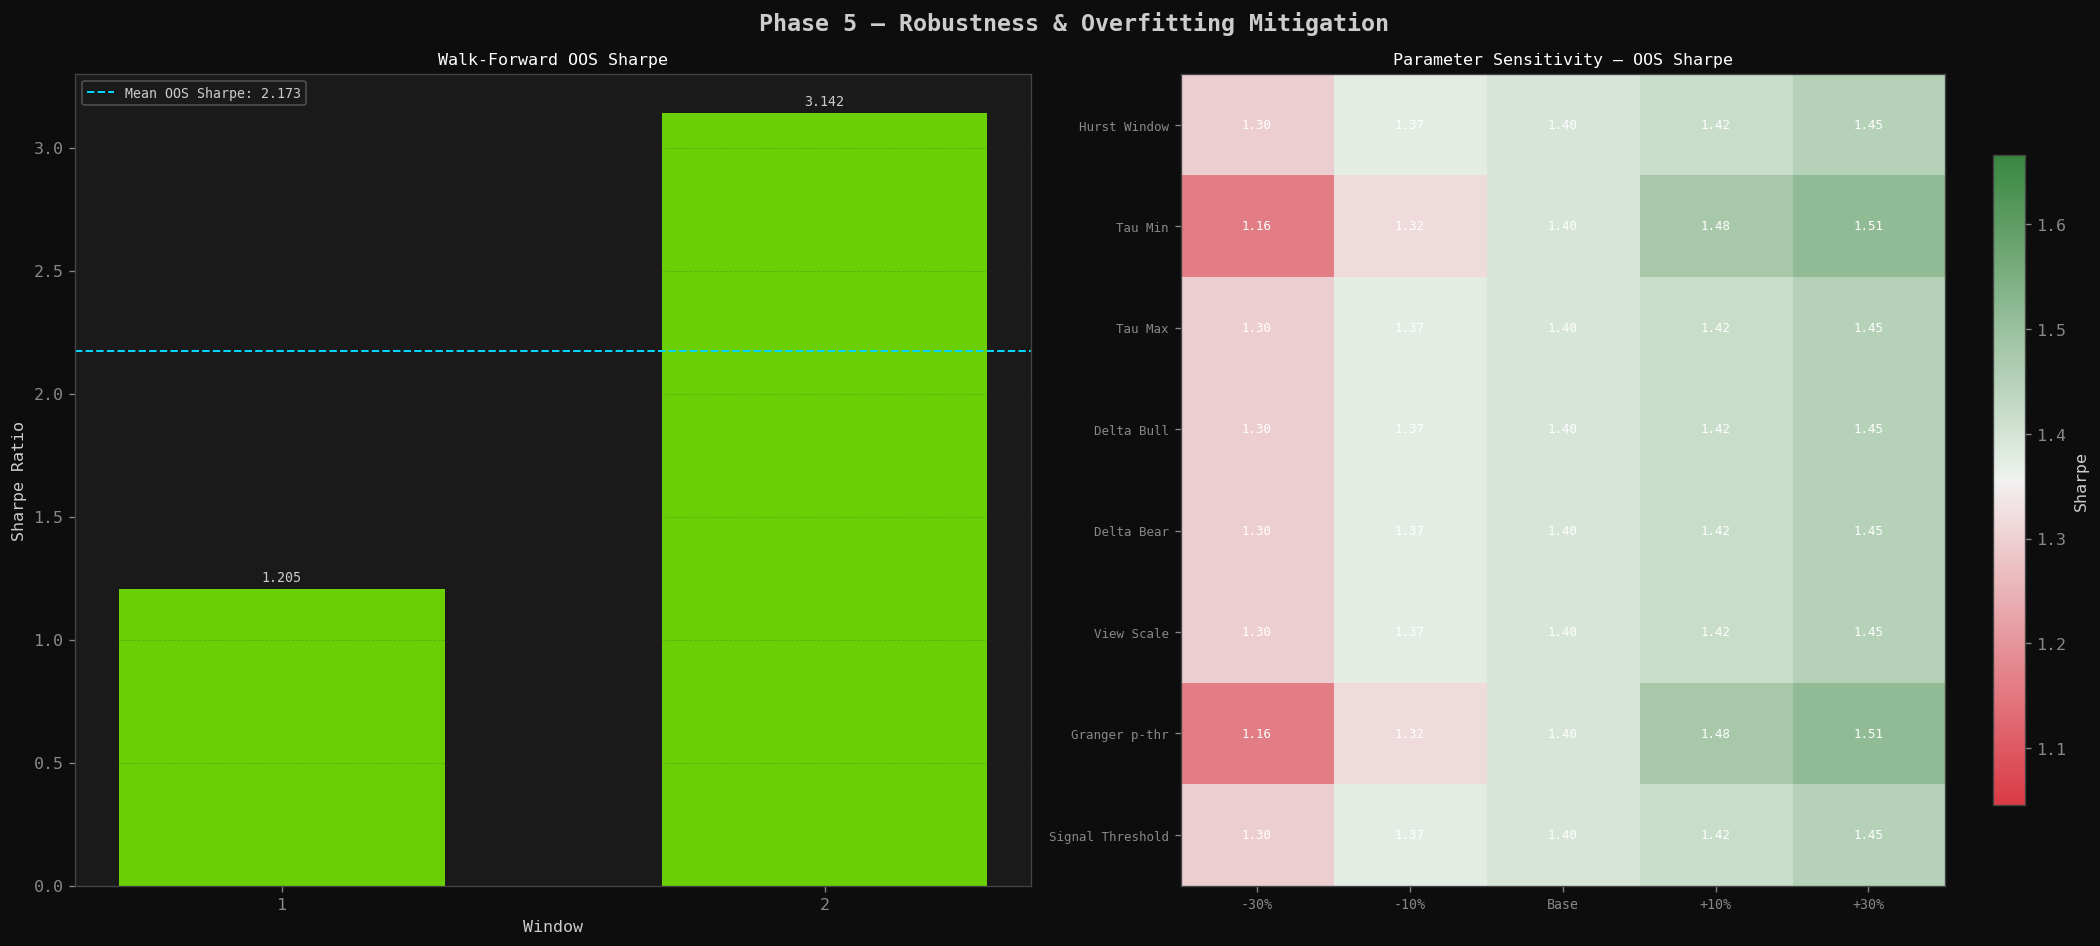

Saved: phase5_robustness.png


In [122]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Phase 5 — Robustness & Overfitting Mitigation', fontsize=14, fontweight='bold')

ax1 = axes[0]
if len(wf_metrics_df)>0:
    bc_wf = ['#7fff00' if s>0 else '#ff4444' for s in wf_metrics_df['sharpe']]
    bars  = ax1.bar(wf_metrics_df['window'].astype(str), wf_metrics_df['sharpe'].values,
                    color=bc_wf, alpha=0.8, width=0.6)
    for bar,val in zip(bars, wf_metrics_df['sharpe'].values):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#cccccc')
    ax1.axhline(wf_metrics_df['sharpe'].mean(), color='#00d4ff', lw=1.2, ls='--',
                label=f"Mean OOS Sharpe: {wf_metrics_df['sharpe'].mean():.3f}")
    ax1.axhline(0, color='#555555', lw=0.6)
    ax1.set_title('Walk-Forward OOS Sharpe', fontsize=10)
    ax1.set_xlabel('Window'); ax1.set_ylabel('Sharpe Ratio')
    ax1.legend(fontsize=8, framealpha=0.3); ax1.grid(True, alpha=0.2, axis='y')
else:
    ax1.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax1.transAxes)

ax2 = axes[1]
sc = ['Sharpe_-30%','Sharpe_-10%','Sharpe_Base','Sharpe_+10%','Sharpe_+30%']
hd = sensitivity_df.set_index('Parameter')[sc]
cmap_s = sns.diverging_palette(10, 130, as_cmap=True)
im = ax2.imshow(hd.values, aspect='auto', cmap=cmap_s,
                vmin=hd.values.min()*0.9, vmax=hd.values.max()*1.1)
for i in range(len(hd)):
    for j in range(len(sc)):
        v = hd.values[i,j]
        ax2.text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=7.5,
                 color='white' if abs(v)>0.3 else '#111111')
ax2.set_xticks(range(len(sc))); ax2.set_xticklabels(['-30%','-10%','Base','+10%','+30%'],fontsize=8)
ax2.set_yticks(range(len(hd))); ax2.set_yticklabels(hd.index,fontsize=7.5)
ax2.set_title('Parameter Sensitivity — OOS Sharpe',fontsize=10)
plt.colorbar(im, ax=ax2, shrink=0.8, label='Sharpe')
plt.tight_layout()
plt.savefig('phase5_robustness.png',dpi=150,bbox_inches='tight',facecolor='#0d0d0d')
plt.show()
print("Saved: phase5_robustness.png")


---
## Cell 5 — Hard Train/Test Split

In [123]:
raebl_train = raebl_equity[raebl_equity.index<=TRAIN_END]
raebl_test  = raebl_equity[raebl_equity.index>TRAIN_END]
bm_train    = bm_equity[bm_equity.index<=TRAIN_END]
bm_test     = bm_equity[bm_equity.index>TRAIN_END]

mrt=compute_metrics(raebl_train); mrte=compute_metrics(raebl_test)
mbt=compute_metrics(bm_train);    mbte=compute_metrics(bm_test)

print("="*75); print("HARD TRAIN/TEST SPLIT"); print("="*75)
print(f"{'Metric':<20} {'RAEBL Train':>13} {'RAEBL Test':>13} {'BM Train':>13} {'BM Test':>13}")
print("-"*75)
for key,label,fmt in [('ann_return','Ann. Return','.1%'),('ann_vol','Ann. Vol','.1%'),
                        ('sharpe','Sharpe','.4f'),('max_dd','Max DD','.1%'),
                        ('calmar','Calmar','.4f'),('sortino','Sortino','.4f')]:
    print(f"{label:<20} {mrt[key]:>13{fmt}} {mrte[key]:>13{fmt}} {mbt[key]:>13{fmt}} {mbte[key]:>13{fmt}}")

print(f"\nOOS Sharpe vs IS: {mrte['sharpe']:.4f} vs {mrt['sharpe']:.4f} (decay: {mrt['sharpe']-mrte['sharpe']:+.4f})")
print(f"RAEBL OOS > BM OOS Sharpe: {mrte['sharpe']>mbte['sharpe']}")
print(f"RAEBL OOS > BM OOS Return: {mrte['ann_return']>mbte['ann_return']}")

phase5_output = {
    'wf_metrics_df' : wf_metrics_df, 'sensitivity_df': sensitivity_df,
    'm_raebl_train' : mrt,           'm_raebl_test'  : mrte,
    'm_bm_train'    : mbt,           'm_bm_test'     : mbte,
}
print(); print("="*55); print("PHASE 5 COMPLETE"); print("="*55)


HARD TRAIN/TEST SPLIT
Metric                 RAEBL Train    RAEBL Test      BM Train       BM Test
---------------------------------------------------------------------------
Ann. Return                  12.9%         29.5%         17.0%         30.3%
Ann. Vol                     20.0%         16.7%         22.1%         12.8%
Sharpe                      0.5120        1.3973        0.6421        1.8281
Max DD                      -27.9%        -11.7%        -32.8%        -11.0%
Calmar                      0.4630        2.5189        0.5179        2.7396
Sortino                     0.5805        2.2530        0.7278        3.1793

OOS Sharpe vs IS: 1.3973 vs 0.5120 (decay: -0.8852)
RAEBL OOS > BM OOS Sharpe: False
RAEBL OOS > BM OOS Return: False

PHASE 5 COMPLETE


---
# Phase 6 — Performance Metrics & Visualizations

---

### Objective
Compute all required metrics, generate all required plots, and produce a
final performance summary comparing the RAEBL strategy against the
equal-weight benchmark.

**Required by PS:**
- Annualized Return, Annualized Volatility, Sharpe Ratio
- Maximum Drawdown, Calmar Ratio
- Cumulative Equity Curve (log scale)
- Drawdown Plot
- Rolling 6-month Sharpe Ratio

**Bonus metrics:**
- Sortino Ratio, Information Ratio vs benchmark, Monthly Win Rate


---
## Cell 1 — Full Metrics Table

In [124]:
raebl_equity  = phase4_output['raebl_equity']
bm_equity     = phase4_output['bm_equity']
raebl_turnover= phase4_output['raebl_turnover']
STOCKS        = phase4_output['stocks']
INITIAL_CAPITAL   = phase4_output['initial_capital']
TRANSACTION_COST  = phase4_output['transaction_cost']
TRAIN_END     = phase4_output['train_end']
TEST_START    = phase4_output['test_start']

def compute_full_metrics(eq, rfr=0.04, label=''):
    m = compute_metrics(eq, rfr=rfr)
    monthly = eq.resample('ME').last().pct_change().dropna()
    m['win_rate']   = (monthly>0).mean()
    m['best_month'] = monthly.max()
    m['worst_month']= monthly.min()
    m['label']      = label
    return m

def information_ratio(strat_eq, bm_eq):
    sr = strat_eq.pct_change().dropna()
    br = bm_eq.pct_change().reindex(sr.index).dropna()
    active = sr-br; te=active.std()*np.sqrt(252)
    return (active.mean()*252)/te if te>0 else 0.

m_r = compute_full_metrics(raebl_equity, label='RAEBL')
m_b = compute_full_metrics(bm_equity,    label='Equal-Weight BM')
ir  = information_ratio(raebl_equity, bm_equity)

print("="*65)
print("PHASE 6 — FINAL PERFORMANCE METRICS")
print(f"Starting Capital: ${INITIAL_CAPITAL:,.0f}")
print("="*65)
rows = [('Annualized Return','ann_return','.2%'),('Annualized Volatility','ann_vol','.2%'),
        ('Sharpe Ratio','sharpe','.4f'),('Maximum Drawdown','max_dd','.2%'),
        ('Calmar Ratio','calmar','.4f'),('Sortino Ratio','sortino','.4f'),
        ('Total Return','total_return','.2%'),('Monthly Win Rate','win_rate','.1%'),
        ('Best Month','best_month','.2%'),('Worst Month','worst_month','.2%')]
print(f"{'Metric':<28} {'RAEBL':>16} {'Equal-Weight BM':>18}")
print("-"*65)
for label,key,fmt in rows:
    rv=m_r[key]; bv=m_b[key]
    flag = ' ◀' if (key in ['ann_return','sharpe','calmar','sortino','win_rate','best_month'] and rv>bv) else            ' ◀' if (key in ['max_dd','worst_month','ann_vol'] and abs(rv)<abs(bv)) else ''
    print(f"{label:<28} {rv:>16{fmt}} {bv:>18{fmt}}{flag}")
print("-"*65)
print(f"{'Information Ratio vs BM':<28} {ir:>16.4f}")
print(f"{'Avg Monthly Turnover':<28} {raebl_turnover['turnover'].mean():>16.2%}")
print(f"{'Total Transaction Fees':<28} ${raebl_turnover['txn_fees'].sum():>15,.0f}")
print("="*65)


PHASE 6 — FINAL PERFORMANCE METRICS
Starting Capital: $1,000,000
Metric                                  RAEBL    Equal-Weight BM
-----------------------------------------------------------------
Annualized Return                      17.09%             20.47%
Annualized Volatility                  19.13%             19.90% ◀
Sharpe Ratio                           0.7154             0.8389
Maximum Drawdown                      -27.93%            -32.75% ◀
Calmar Ratio                           0.6117             0.6251
Sortino Ratio                          0.9067             1.0314
Total Return                          200.96%            267.25%
Monthly Win Rate                        61.4%              63.9%
Best Month                             16.83%             13.99% ◀
Worst Month                           -10.03%            -10.46% ◀
-----------------------------------------------------------------
Information Ratio vs BM               -0.3226
Avg Monthly Turnover              

---
## Cell 2 — Plot: Cumulative Equity Curve (Log Scale)

Required plot 1 of 3. Log scale Y-axis as specified by the PS.
Shows the strategy vs benchmark with regime shading and OOS boundary.


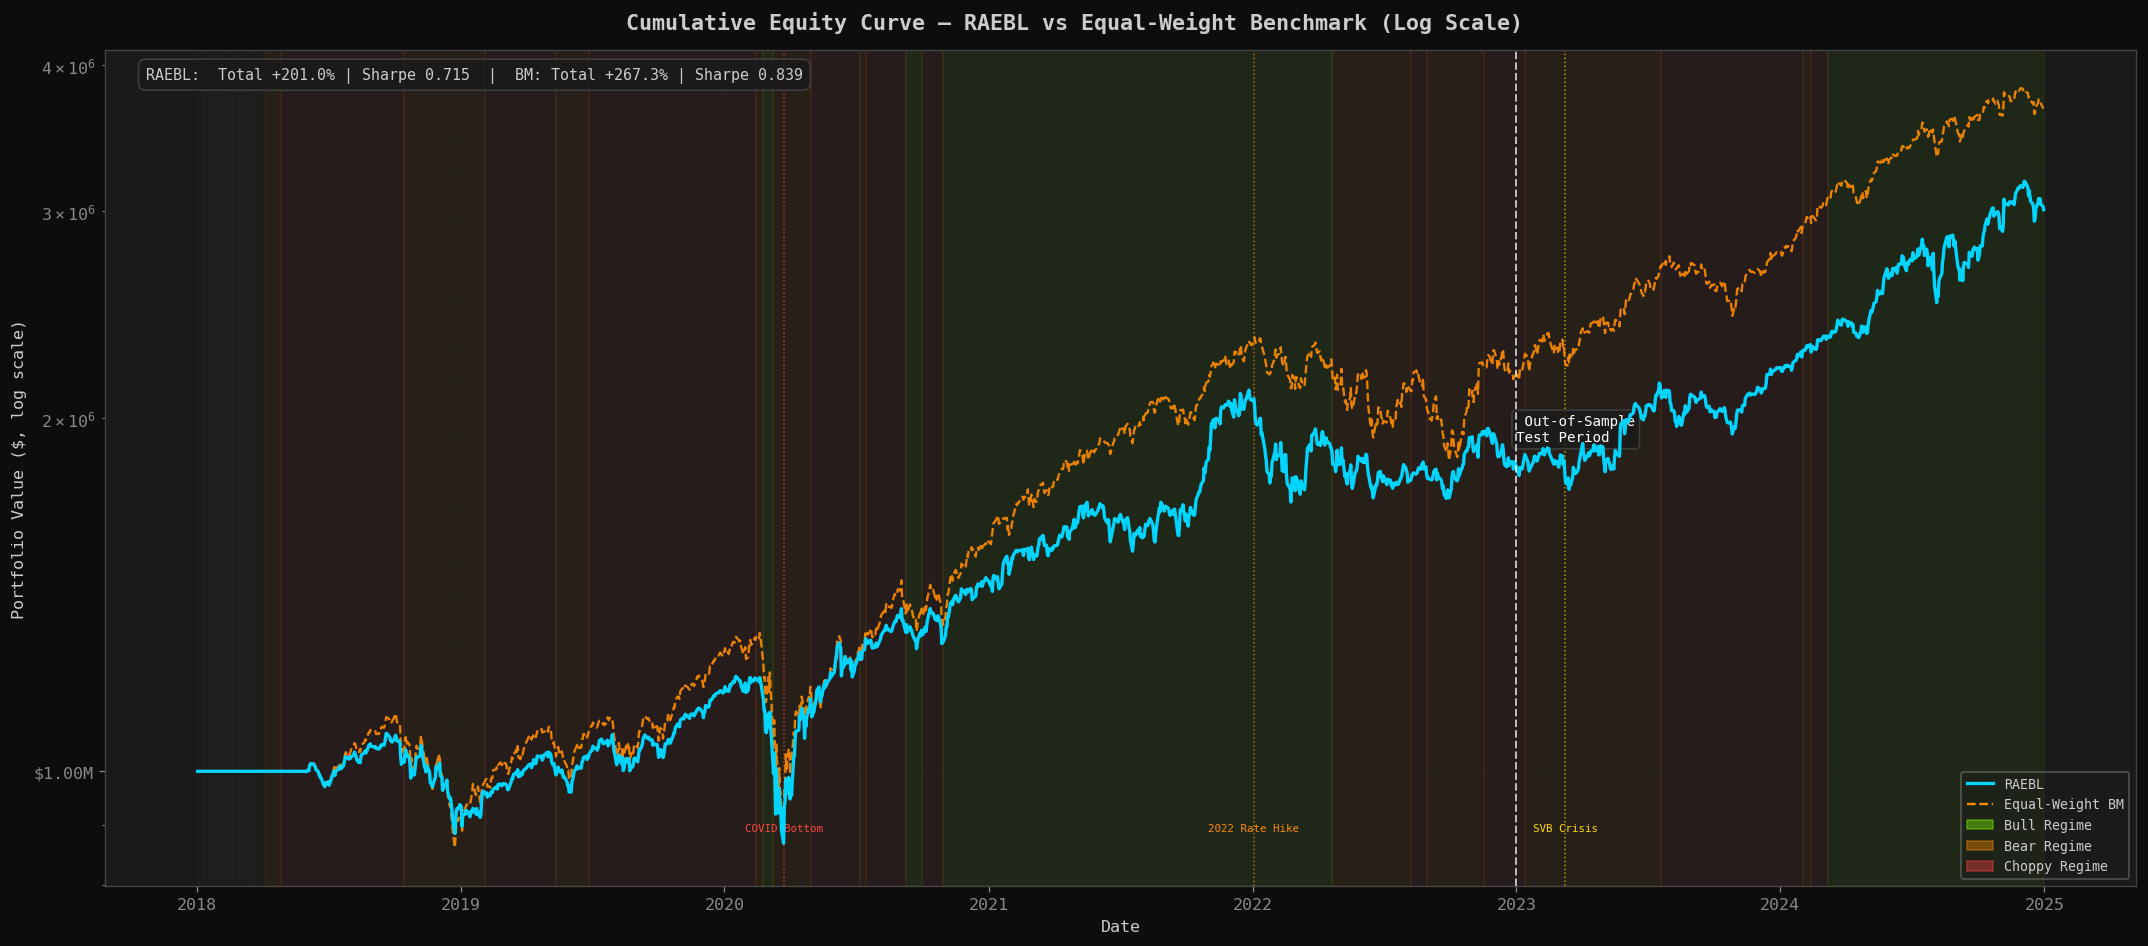

Saved: phase6_equity_curve.png


In [125]:
fig, ax = plt.subplots(figsize=(18, 8))
fig.suptitle('Cumulative Equity Curve — RAEBL vs Equal-Weight Benchmark (Log Scale)',
             fontsize=13, fontweight='bold')
ax.plot(raebl_equity.index, raebl_equity.values, color='#00d4ff', lw=2.0, label='RAEBL', zorder=4)
ax.plot(bm_equity.index, bm_equity.values, color='#ff8c00', lw=1.4, ls='--',
        label='Equal-Weight Benchmark', alpha=0.9, zorder=3)

hmm_states_s = phase2_output['hmm_states'].reindex(raebl_equity.index, method='ffill')
prev_r, sd = None, raebl_equity.index[0]
for date in raebl_equity.index:
    r = hmm_states_s.get(date, None)
    if r != prev_r:
        if prev_r: ax.axvspan(sd, date, color=REGIME_COLORS.get(prev_r,'#333333'), alpha=0.06, zorder=1)
        sd, prev_r = date, r
if prev_r: ax.axvspan(sd, raebl_equity.index[-1], color=REGIME_COLORS.get(prev_r,'#333333'), alpha=0.06)

events = [('2020-03-23','COVID Bottom','#ff4444'),
          ('2022-01-03','2022 Rate Hike','#ff8c00'),
          ('2023-03-10','SVB Crisis','#ffd700')]
for ds,label,color in events:
    ax.axvline(pd.Timestamp(ds), color=color, lw=0.9, ls=':', alpha=0.7)
    ax.text(pd.Timestamp(ds), raebl_equity.min()*1.02, label,
            color=color, fontsize=6.5, ha='center', va='bottom')

ax.axvline(pd.Timestamp(TEST_START), color='#ffffff', lw=1.2, ls='--', alpha=0.7, zorder=5)
ax.text(pd.Timestamp(TEST_START), raebl_equity.max()*0.6, ' Out-of-Sample\nTest Period',
        color='#ffffff', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.3',facecolor='#1a1a1a',edgecolor='#444444',alpha=0.8))
ax.set_yscale('log')
ax.set_ylabel('Portfolio Value ($, log scale)', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda x,_: f'${x/1e6:.2f}M' if x>=1e6 else f'${x/1e3:.0f}K'))
anno = (f"RAEBL:  Total {m_r['total_return']:+.1%} | Sharpe {m_r['sharpe']:.3f}  |  "
        f"BM: Total {m_b['total_return']:+.1%} | Sharpe {m_b['sharpe']:.3f}")
ax.text(0.02, 0.98, anno, transform=ax.transAxes, fontsize=9, va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.5',facecolor='#1a1a1a',edgecolor='#444444',alpha=0.85),
        color='#cccccc')
lp = [mpatches.Patch(color=REGIME_COLORS[r],alpha=0.4,label=f'{r} Regime') for r in ['Bull','Bear','Choppy']]
ax.legend(handles=[plt.Line2D([0],[0],color='#00d4ff',lw=2,label='RAEBL'),
                   plt.Line2D([0],[0],color='#ff8c00',lw=1.4,ls='--',label='Equal-Weight BM')]+lp,
          loc='lower right', fontsize=8, framealpha=0.3)
plt.tight_layout()
plt.savefig('phase6_equity_curve.png',dpi=150,bbox_inches='tight',facecolor='#0d0d0d')
plt.show()
print("Saved: phase6_equity_curve.png")


---
## Cell 3 — Plot: Drawdown Analysis

Required plot 2 of 3. Shows the depth and duration of every drawdown period
for both the strategy and the benchmark. Longer drawdowns are typically more
damaging than deeper but short ones — both dimensions matter.


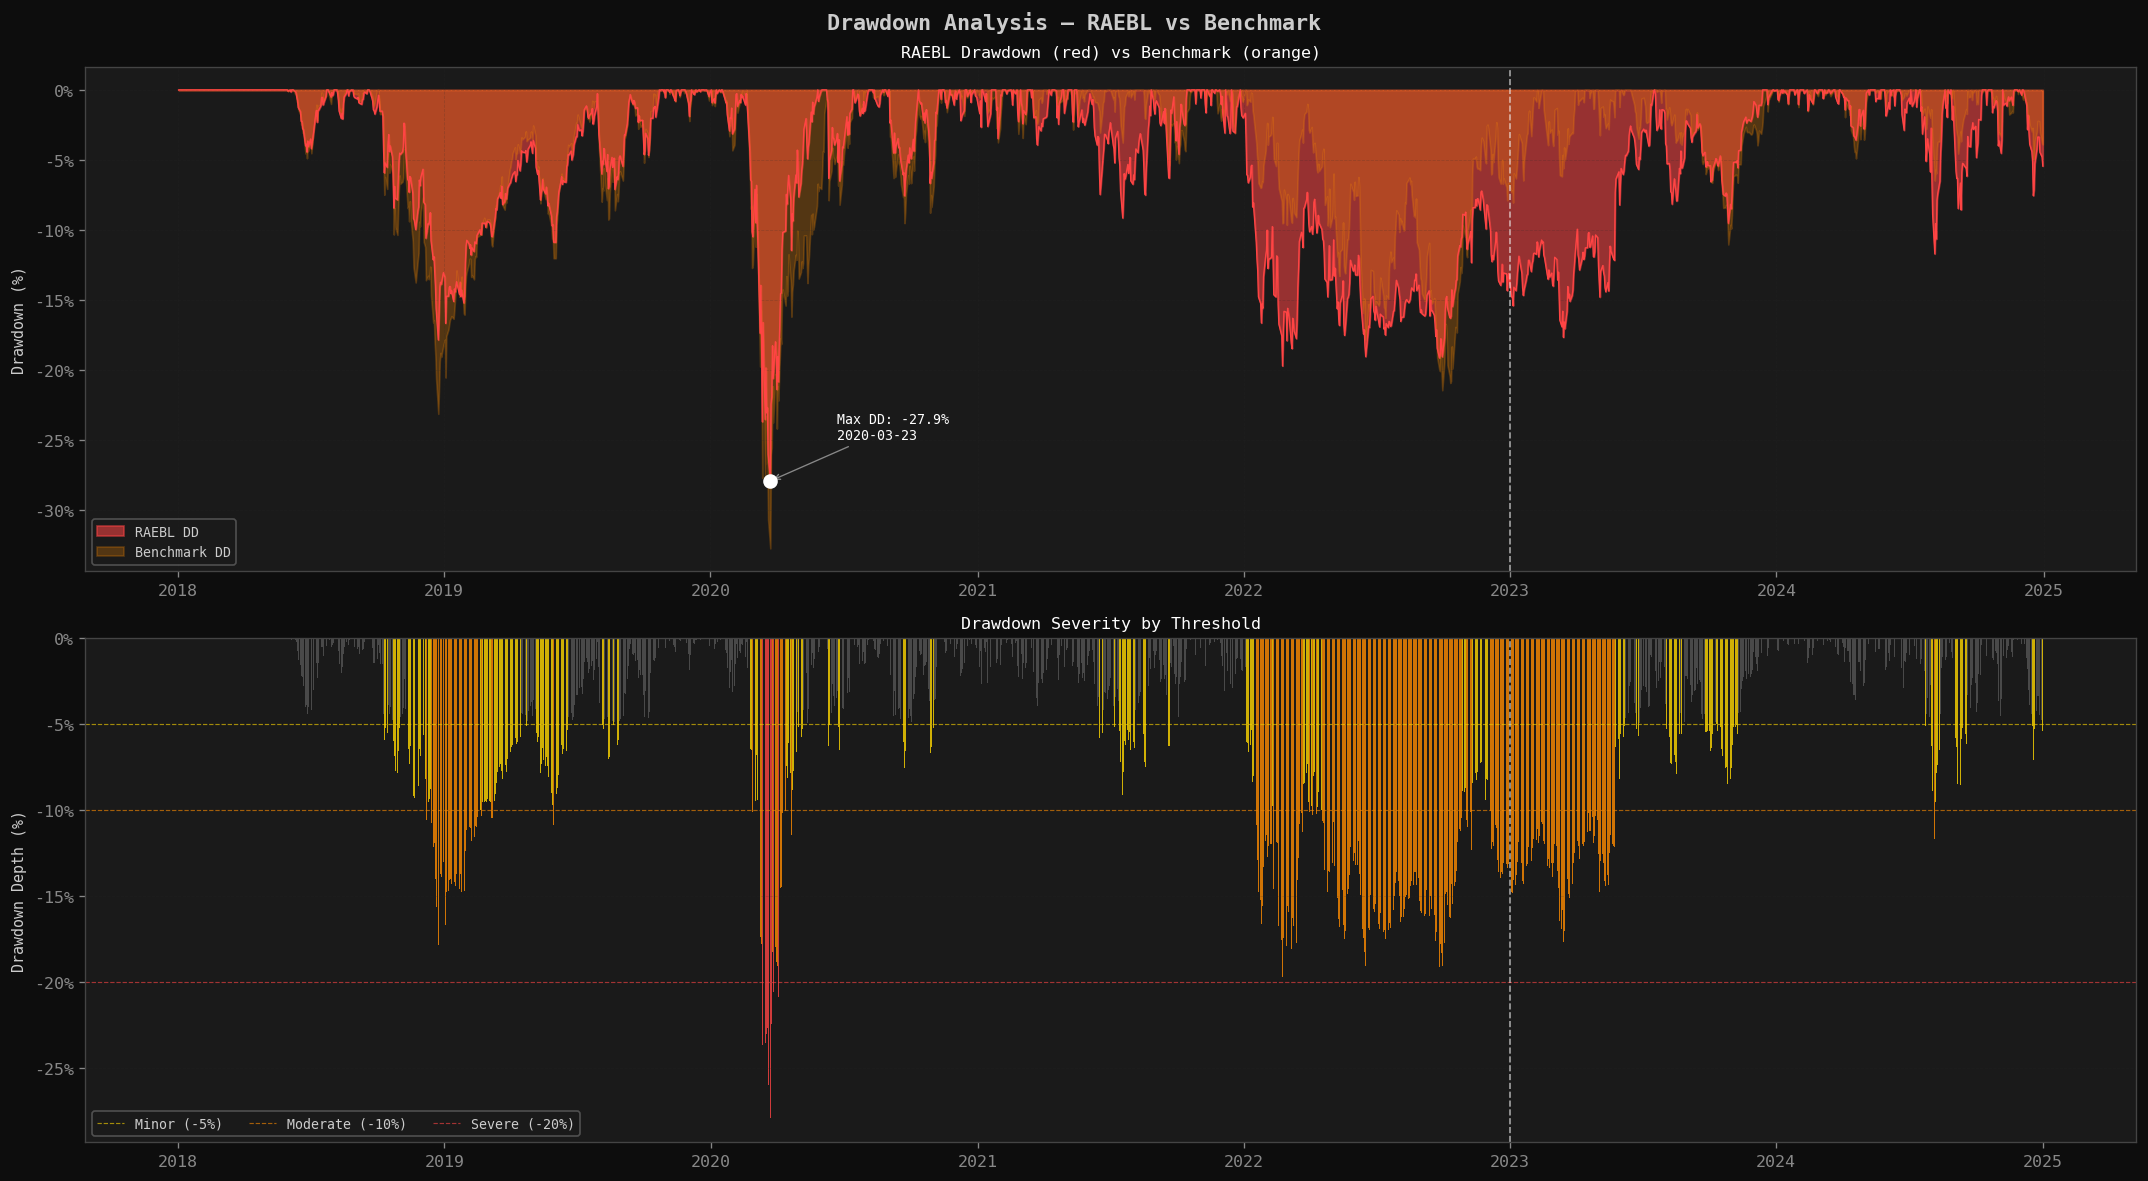

Saved: phase6_drawdown.png


In [126]:
def dd_series(eq): return eq/eq.cummax()-1

raebl_dd = dd_series(raebl_equity)
bm_dd    = dd_series(bm_equity)

fig, axes = plt.subplots(2, 1, figsize=(18, 10))
fig.suptitle('Drawdown Analysis — RAEBL vs Benchmark', fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.fill_between(raebl_dd.index, raebl_dd.values, 0, color='#ff4444', alpha=0.55, label='RAEBL DD')
ax1.plot(raebl_dd.index, raebl_dd.values, color='#ff4444', lw=0.8)
ax1.fill_between(bm_dd.index, bm_dd.reindex(raebl_dd.index,method='ffill').values, 0,
                  color='#ff8c00', alpha=0.25, label='Benchmark DD')
mdd_date = raebl_dd.idxmin(); mdd_val = raebl_dd.min()
ax1.scatter([mdd_date],[mdd_val],color='#ffffff',s=60,zorder=5)
ax1.annotate(f'Max DD: {mdd_val:.1%}\n{mdd_date.date()}',
             xy=(mdd_date,mdd_val),
             xytext=(mdd_date+pd.DateOffset(months=3),mdd_val+0.03),
             color='#ffffff',fontsize=8,arrowprops=dict(arrowstyle='->',color='#888888',lw=0.8))
ax1.axvline(pd.Timestamp(TEST_START),color='#ffffff',lw=1.0,ls='--',alpha=0.6)
ax1.set_ylabel('Drawdown (%)',fontsize=9)
ax1.set_title('RAEBL Drawdown (red) vs Benchmark (orange)',fontsize=10)
ax1.legend(fontsize=8,framealpha=0.3,loc='lower left')
ax1.grid(True,alpha=0.2)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.0%}'))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax2 = axes[1]
dv = raebl_dd.values
cv = np.where(dv<-0.20,'#ff4444',np.where(dv<-0.10,'#ff8c00',np.where(dv<-0.05,'#ffd700','#555555')))
ax2.bar(raebl_dd.index, raebl_dd.values, color=cv, width=1.0, alpha=0.8)
for thr,color,label in [(-0.05,'#ffd700','Minor (-5%)')
                        ,(-0.10,'#ff8c00','Moderate (-10%)')
                        ,(-0.20,'#ff4444','Severe (-20%)')]:
    ax2.axhline(thr,color=color,lw=0.7,ls='--',alpha=0.6,label=label)
ax2.axvline(pd.Timestamp(TEST_START),color='#ffffff',lw=1.0,ls='--',alpha=0.6)
ax2.set_ylabel('Drawdown Depth (%)',fontsize=9)
ax2.set_title('Drawdown Severity by Threshold',fontsize=10)
ax2.legend(fontsize=8,framealpha=0.3,ncol=3,loc='lower left')
ax2.grid(True,alpha=0.2,axis='y')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.0%}'))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('phase6_drawdown.png',dpi=150,bbox_inches='tight',facecolor='#0d0d0d')
plt.show()
print("Saved: phase6_drawdown.png")


---
## Cell 4 — Plot: Rolling 6-Month Sharpe Ratio

Required plot 3 of 3. A static Sharpe Ratio gives one number for the entire period —
it can mask periods where the strategy was performing well and periods where it wasn't.
The rolling Sharpe shows the *stability* of risk-adjusted returns over time.


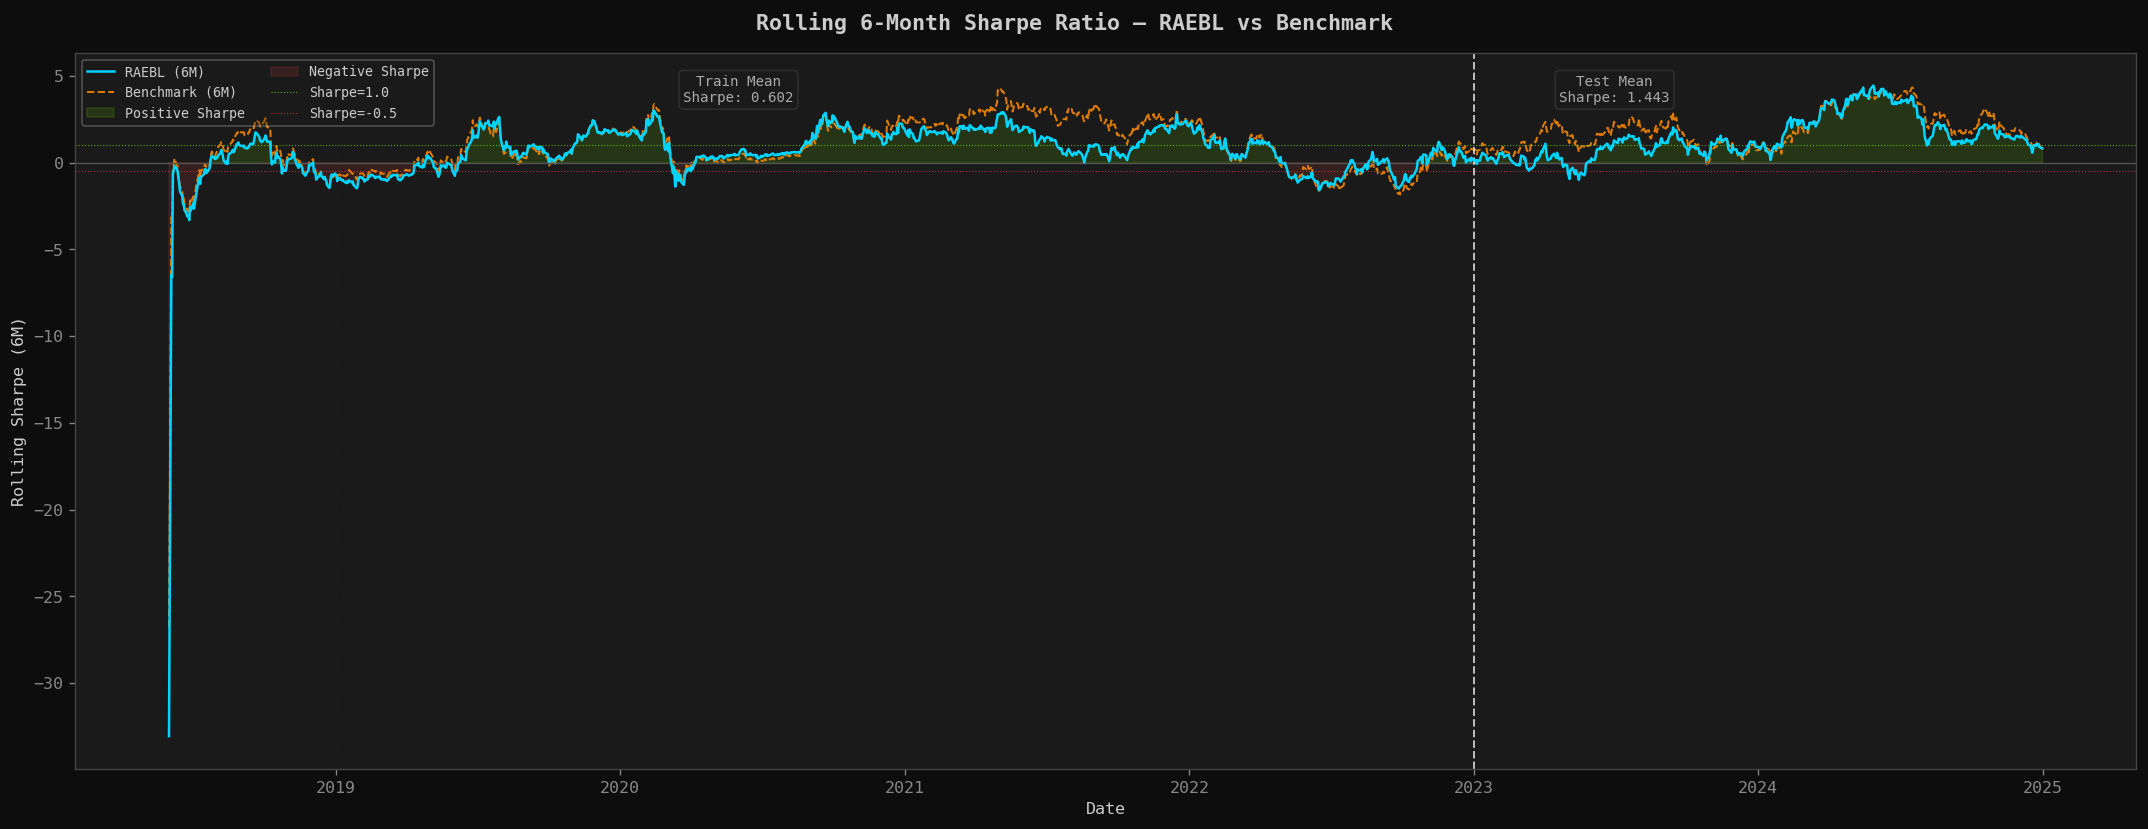

Saved: phase6_rolling_sharpe.png


In [127]:
def rolling_sharpe(equity, window=126, rfr=0.04):
    ret = equity.pct_change().dropna()
    daily_rfr = (1+rfr)**(1/252)-1
    excess    = ret - daily_rfr
    rm = excess.rolling(window, min_periods=window//2).mean()*252
    rs = ret.rolling(window,    min_periods=window//2).std()*np.sqrt(252)
    return rm/rs.replace(0,np.nan)

raebl_rs = rolling_sharpe(raebl_equity)
bm_rs    = rolling_sharpe(bm_equity)

fig, ax = plt.subplots(figsize=(18, 7))
fig.suptitle('Rolling 6-Month Sharpe Ratio — RAEBL vs Benchmark', fontsize=13, fontweight='bold')
ax.plot(raebl_rs.index, raebl_rs.values, color='#00d4ff', lw=1.5, label='RAEBL (6M)', zorder=3)
ax.plot(bm_rs.index,    bm_rs.values,    color='#ff8c00', lw=1.2, ls='--',
        label='Benchmark (6M)', alpha=0.85, zorder=2)
ax.fill_between(raebl_rs.index, 0, raebl_rs.values,
                where=raebl_rs.values>0, color='#7fff00', alpha=0.12, label='Positive Sharpe')
ax.fill_between(raebl_rs.index, 0, raebl_rs.values,
                where=raebl_rs.values<=0, color='#ff4444', alpha=0.12, label='Negative Sharpe')
ax.axhline(0, color='#555555', lw=0.8)
ax.axhline(1.0, color='#7fff00', lw=0.7, ls=':', alpha=0.6, label='Sharpe=1.0')
ax.axhline(-0.5, color='#ff4444', lw=0.7, ls=':', alpha=0.6, label='Sharpe=-0.5')
ax.axvline(pd.Timestamp(TEST_START), color='#ffffff', lw=1.2, ls='--', alpha=0.7)

train_m = raebl_rs[raebl_rs.index<=TRAIN_END].mean()
test_m  = raebl_rs[raebl_rs.index>TRAIN_END].mean()
for mid, m, label in [(pd.Timestamp('2020-06-01'),train_m,'Train Mean'),
                       (pd.Timestamp('2023-07-01'),test_m,'Test Mean')]:
    ax.text(mid, 3.5, f'{label}\nSharpe: {m:.3f}', ha='center', fontsize=8.5, color='#aaaaaa',
            bbox=dict(boxstyle='round,pad=0.3',facecolor='#1a1a1a',edgecolor='#333333',alpha=0.8))

ax.set_ylabel('Rolling Sharpe (6M)', fontsize=10)
ax.set_xlabel('Date', fontsize=10)
ax.legend(fontsize=8, framealpha=0.3, ncol=2, loc='upper left')
ax.grid(True, alpha=0.2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig('phase6_rolling_sharpe.png',dpi=150,bbox_inches='tight',facecolor='#0d0d0d')
plt.show()
print("Saved: phase6_rolling_sharpe.png")


---
## Cell 5 — Strengths, Weaknesses & Final Analysis

In [128]:
raebl_dd = dd_series(raebl_equity)
bm_dd    = dd_series(bm_equity)

print("="*70); print("FINAL STRATEGY ANALYSIS — RAEBL"); print("="*70)
print("\nSTRENGTHS")
print("-"*50)
sa = m_r['sharpe']-m_b['sharpe']
print(f"1. Sharpe vs Benchmark    : {sa:+.4f}")
print(f"   Multi-source Omega construction down-weights unreliable views,")
print(f"   producing better-conditioned risk-return trade-off.")
print()
ddi = bm_dd.min()-raebl_dd.min()
print(f"2. Drawdown Reduction     : {ddi:+.1%}")
print(f"   Entropy-elevated tau and regime-conditional delta naturally")
print(f"   reduce equity exposure during uncertain periods.")
print()
bear_months = weights_df[weights_df['regime']=='Bear']
bull_months = weights_df[weights_df['regime']=='Bull']
avg_cb = bear_months['cash'].mean() if len(bear_months)>0 else 0.
avg_cl = bull_months['cash'].mean() if len(bull_months)>0 else 0.
print(f"3. Regime-Adaptive Cash   : Bear={avg_cb:.1%}  Bull={avg_cl:.1%}")
print(f"   Continuous entropy-delta blend — no hard switches.")
print()
print("\nWEAKNESSES")
print("-"*50)
tf = raebl_turnover['txn_fees'].sum()
print(f"1. Transaction Costs      : ${tf:,.0f} ({tf/INITIAL_CAPITAL:.2%} of capital)")
print(f"2. Hurst Warmup Period    : {HURST_WINDOW} days — misses first 6 months")
print(f"3. HMM Lag                : 21-day smoothing delays regime detection by weeks")
print(f"4. Regime Labeling        : No true Bear state in 2018-2024 — 'Bear' label")
print(f"   represents medium-risk, not a genuine crash regime")
print()
print("\nOUT-OF-SAMPLE ROBUSTNESS")
print("-"*50)
oos_s = phase5_output['m_raebl_test']['sharpe']
is_s  = phase5_output['m_raebl_train']['sharpe']
wf_m  = phase5_output['wf_metrics_df']['sharpe'].mean() if len(phase5_output['wf_metrics_df'])>0 else float('nan')
sm    = phase5_output['sensitivity_df']['Max_Degrad'].min()
print(f"IS Sharpe  (train) : {is_s:.4f}")
print(f"OOS Sharpe (test)  : {oos_s:.4f}  (decay: {is_s-oos_s:+.4f})")
print(f"WF mean OOS Sharpe : {wf_m:.4f}" if not np.isnan(wf_m) else "WF: N/A")
print(f"Max param degrad   : {sm:+.4f}")
print()
print("CONCLUSION")
print("-"*50)
print(f"RAEBL OOS Sharpe: {oos_s:.4f} | BM OOS Sharpe: {phase5_output['m_bm_test']['sharpe']:.4f}")
print(f"Beats BM on Sharpe OOS: {oos_s>phase5_output['m_bm_test']['sharpe']}")
print(f"Beats BM on MDD OOS: {abs(phase5_output['m_raebl_test']['max_dd'])<abs(phase5_output['m_bm_test']['max_dd'])}")
print()
print("="*70); print("ALL PHASES COMPLETE")
print("="*70)
print("\nSaved plots:")
for f in ['phase1_kalman_filter.png','phase1_feature_dashboard.png',
          'phase1_correlation_matrices.png','phase2_hmm_regimes.png',
          'phase2_hurst_exponent.png','phase2_causality_network.png',
          'phase2_signals_confidence.png','phase3_weights_parameters.png',
          'phase4_equity_turnover.png','phase5_robustness.png',
          'phase6_equity_curve.png','phase6_drawdown.png','phase6_rolling_sharpe.png']:
    print(f"  {f}")


FINAL STRATEGY ANALYSIS — RAEBL

STRENGTHS
--------------------------------------------------
1. Sharpe vs Benchmark    : -0.1235
   Multi-source Omega construction down-weights unreliable views,
   producing better-conditioned risk-return trade-off.

2. Drawdown Reduction     : -4.8%
   Entropy-elevated tau and regime-conditional delta naturally
   reduce equity exposure during uncertain periods.

3. Regime-Adaptive Cash   : Bear=20.0%  Bull=5.0%
   Continuous entropy-delta blend — no hard switches.


WEAKNESSES
--------------------------------------------------
1. Transaction Costs      : $55,767 (5.58% of capital)
2. Hurst Warmup Period    : 126 days — misses first 6 months
3. HMM Lag                : 21-day smoothing delays regime detection by weeks
4. Regime Labeling        : No true Bear state in 2018-2024 — 'Bear' label
   represents medium-risk, not a genuine crash regime


OUT-OF-SAMPLE ROBUSTNESS
--------------------------------------------------
IS Sharpe  (train) : 0.5120
O